In [2]:
import torch

# Print PyTorch version
print(f"PyTorch version: {torch.__version__}")

# Detect and initialize GPU/CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Running on GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("Running on CPU")

# In PyTorch, `device` handles where tensors and models are placed.
# There isn't a direct equivalent to `strategy.num_replicas_in_sync`
# for single-device operation like in TensorFlow's distribution strategy.
# If you plan to use multiple GPUs, we'd use `torch.nn.DataParallel` or
# `torch.nn.parallel.DistributedDataParallel`, which is a more advanced topic.
print(f"Number of devices (current): 1 (using {device.type}) 🚀")

# There's no direct PyTorch equivalent to Keras version checking or its specific modules.
# We'll use the core PyTorch modules for building neural networks.
from torch import nn
from torch.optim import Adam # A common optimizer, similar to Adam in Keras
from torch.optim.lr_scheduler import ReduceLROnPlateau # Learning rate scheduler
# For early stopping and model checkpointing, we'll implement these directly or use callbacks later.
# There isn't a direct `torch.keras.callbacks` equivalent.

PyTorch version: 2.8.0+cu126
Running on GPU: Tesla T4
Number of devices (current): 1 (using cuda) 🚀


In [3]:
# Instalación de las bibliotecas necesarias
!pip install PyWavelets
!pip install fCWT
!apt-get update
!apt-get install libfftw3-single3 -y

# Importaciones básicas
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import random
import h5py
import pywt
import fcwt
import scipy
from scipy import signal
import gc  # Para liberación explícita de memoria
import time
from datetime import timedelta
from tqdm.notebook import tqdm
from IPython.display import display

# Importaciones para machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# Establecer estilo de Matplotlib
plt.style.use('seaborn-v0_8-whitegrid')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 9.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for fCWT: filename=fcwt-0.1.18-cp312-cp312-linux_x86_64.whl size=4893129 sha256=fcf8629bc8eacc170f2b25f8945ed9e0809158ee412c226dd95bd5e8bd5d1f85
  Stored in directory: /root/.cache/pip/wheels/95/b6/a4/317817507d7014feffb47cae9a1932bd00cd9bfda84f2475c1
Successfully built fCWT
Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.2 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy I

In [4]:
# Para montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Data Directory: /content/drive/MyDrive/Dataset/Looped
Sample Rate: 25600 Hz
Classification Mode: five_classes
Number of signals (training, testing): (960, 240)
Number of labels (training, testing): (960, 240)
Number of samples per signal: 25600


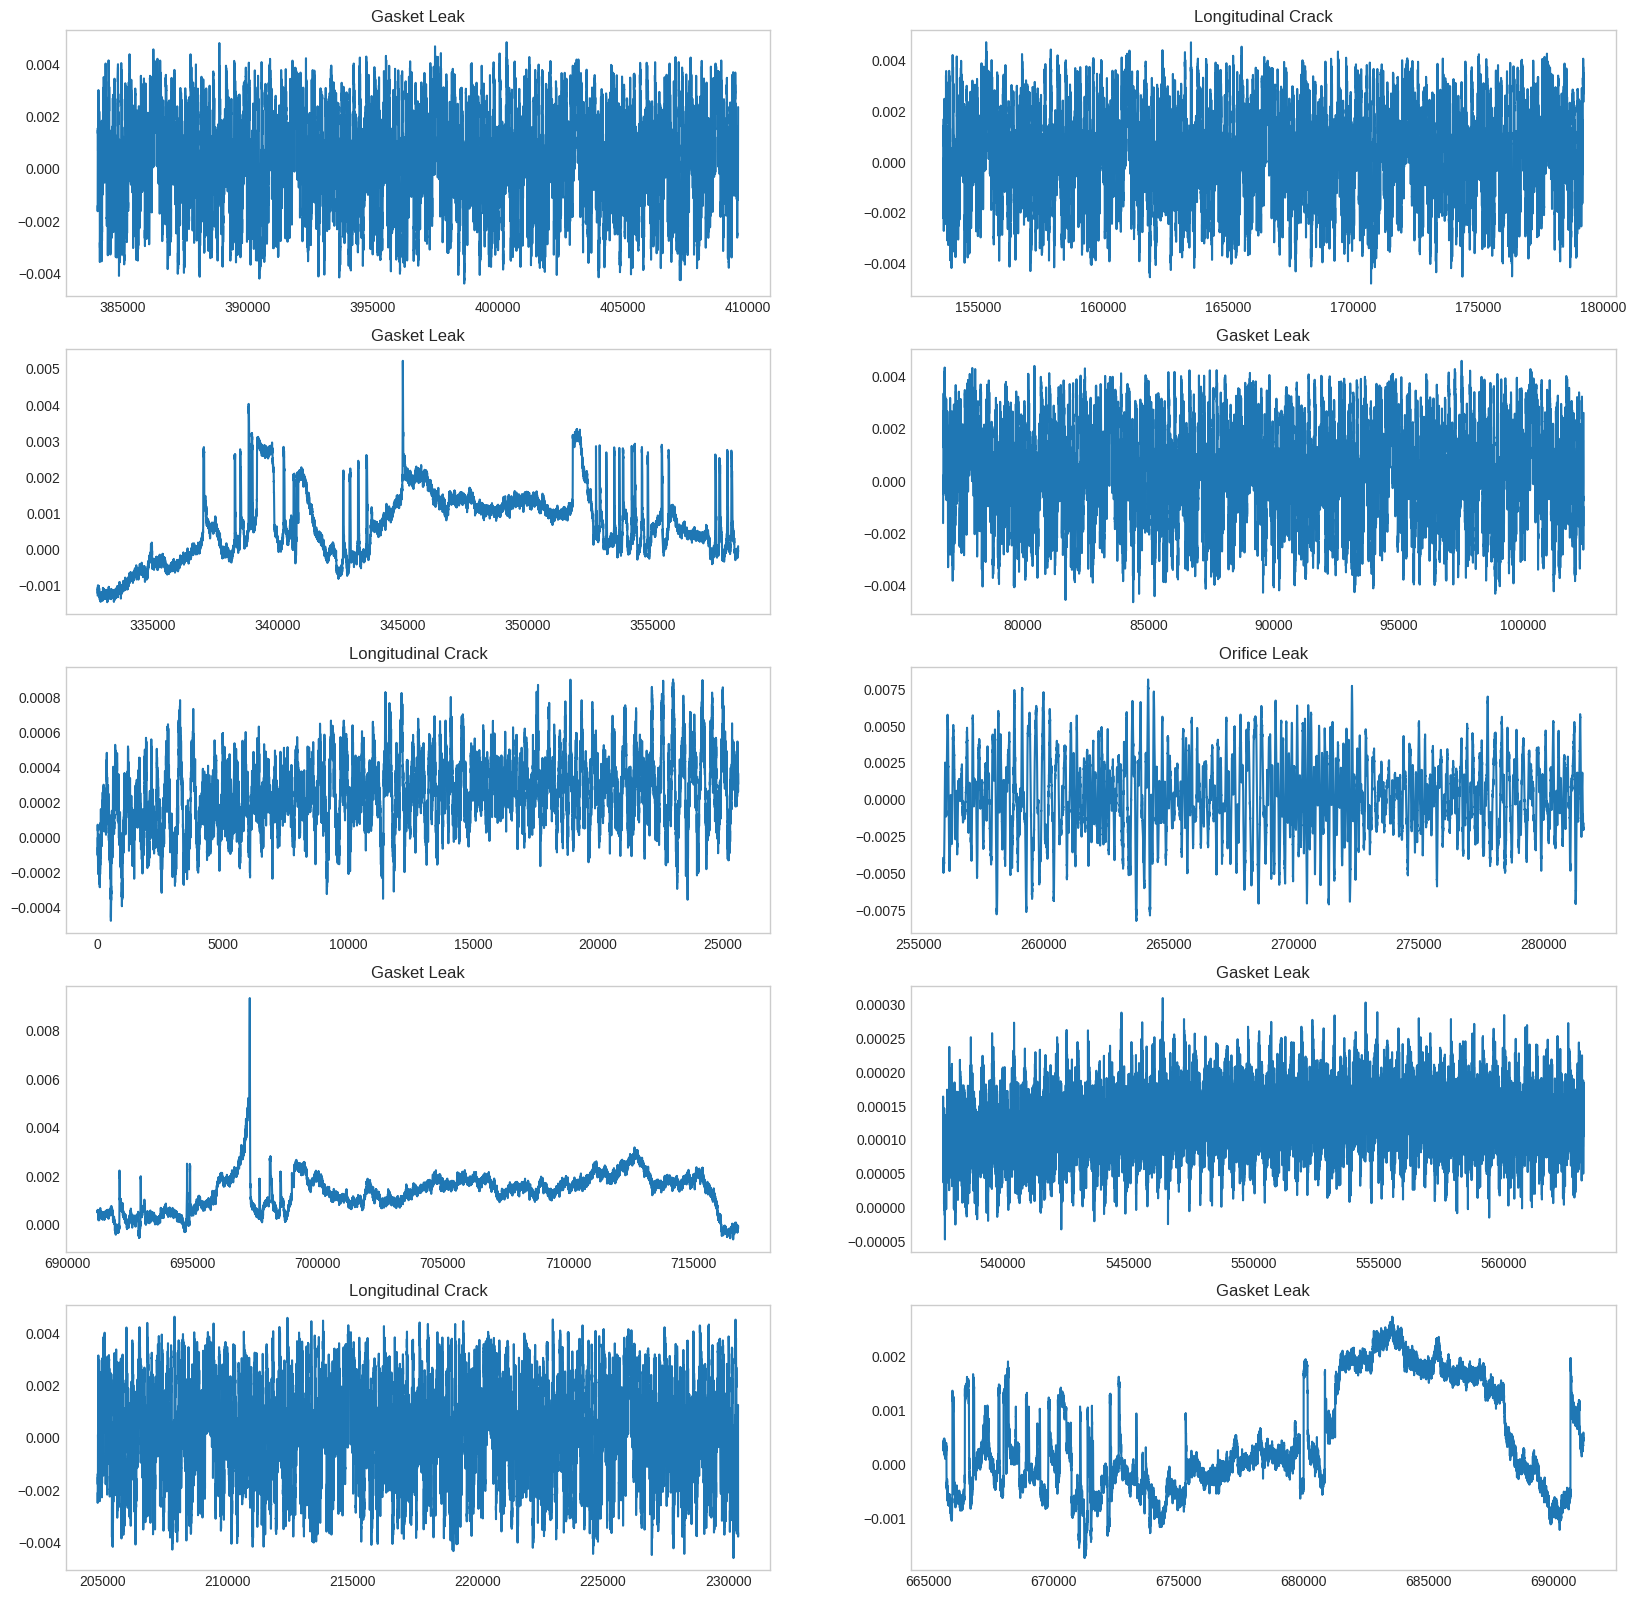

In [5]:
# Definir la ruta de los datos en Google Drive
data_dir = '/content/drive/MyDrive/Dataset/Looped'
original_sr = 25600  # Frecuencia de muestreo original en Hz
signal_sr = 25600  # Frecuencia de muestreo deseada en Hz
downsample_factor = original_sr // signal_sr

# Modo de clasificación: 'five_classes' o 'binary'
classification_mode = 'five_classes'  # Cambiar según necesidad

# Diccionario de etiquetas según el modo de clasificación
if classification_mode == 'five_classes':
    label_codes_dict = {
        'Circumferential Crack': 0,
        'Gasket Leak': 1,
        'Longitudinal Crack': 2,
        'No-leak': 3,
        'Orifice Leak': 4
    }
else:  # binary
    label_codes_dict = {'Leak': 0, 'No-leak': 1}

# Función para eliminar archivos .DS_Store si existen
def remove_DS_store_file(path):
    for ds_name in ['.DS_Store', '.DS_store']:
        ds_store_file_location = os.path.join(path, ds_name)
        if os.path.isfile(ds_store_file_location):
            os.remove(ds_store_file_location)

def load_accelerometer_data(data_dir, sample_rate, downsample_factor, label_codes, mode='five_classes', fraction_to_include=1):
    remove_DS_store_file(data_dir)
    signals = []
    labels = []

    # Para submuestreo en modo binario
    if mode == 'binary':
        # Diccionario para rastrear señales por tipo de fuga
        leak_type_signals = {
            'Circumferential Crack': [],
            'Gasket Leak': [],
            'Longitudinal Crack': [],
            'Orifice Leak': []
        }
        no_leak_signals = []
        sample_labels = []  # Para almacenar etiquetas originales (para estratificación)

    for label in os.listdir(data_dir):
        label_dir = os.path.join(data_dir, label)
        if not os.path.isdir(label_dir):
            print(f"Omitiendo {label_dir} porque no es un directorio")
            continue

        remove_DS_store_file(label_dir)

        for file in os.listdir(label_dir):
            file_path = os.path.join(label_dir, file)
            if not os.path.isfile(file_path):
                continue

            accelerometer_signal_df = pd.read_csv(file_path, index_col=False)
            accelerometer_signal_df = accelerometer_signal_df.iloc[::downsample_factor, :].reset_index(drop=True)
            accelerometer_signal = accelerometer_signal_df['Value'][0:(sample_rate * 30)]

            sample_indexes = np.linspace(0, len(accelerometer_signal) - sample_rate, len(accelerometer_signal) // sample_rate)
            signal_frames_number = fraction_to_include * len(sample_indexes)
            signal_frames_counter = 0

            for signal_frame in sample_indexes:
                accelerometer_signal_frame = accelerometer_signal[int(signal_frame):int(signal_frame + sample_rate)]
                signal_frames_counter += 1

                if signal_frames_counter > signal_frames_number:
                    break

                if len(accelerometer_signal_frame) != sample_rate:
                    continue

                if mode == 'five_classes':
                    signals.append(accelerometer_signal_frame)
                    labels.append(label_codes[label])
                else:  # binary
                    # En vez de añadir directamente, almacenamos por tipo de fuga
                    if label == 'No-leak':
                        no_leak_signals.append(accelerometer_signal_frame)
                        sample_labels.append('No-leak')
                    else:
                        # Almacenar en el diccionario correspondiente
                        leak_type_signals[label].append(accelerometer_signal_frame)
                        sample_labels.append(label)

    # Para modo binario, realizar submuestreo equilibrado
    if mode == 'binary':
        # Número total de muestras No-leak
        total_no_leak = len(no_leak_signals)

        # Calcular cuántas muestras tomar de cada tipo de fuga para balancear con No-leak
        samples_per_leak_type = total_no_leak // 4  # Dividir entre los 4 tipos de fuga

        # Si hay muy pocas muestras de algún tipo, ajustar todas para mantener la proporcionalidad
        min_available = min([len(leak_signals) for leak_signals in leak_type_signals.values()])
        if min_available < samples_per_leak_type:
            samples_per_leak_type = min_available

        # Limitar cada tipo de fuga a la cantidad calculada para balanceo
        balanced_leak_signals = []
        balanced_labels = []
        balanced_stratify = []

        # Añadir todas las muestras No-leak
        for signal in no_leak_signals:
            balanced_leak_signals.append(signal)
            balanced_labels.append(1)  # No-leak
            balanced_stratify.append('No-leak')

        # Añadir cantidades equilibradas de cada tipo de fuga
        for leak_type, leak_signals in leak_type_signals.items():
            # Tomar exactamente samples_per_leak_type muestras de cada tipo de fuga
            for signal in leak_signals[:samples_per_leak_type]:
                balanced_leak_signals.append(signal)
                balanced_labels.append(0)  # Leak
                balanced_stratify.append(leak_type)  # Guardar tipo original para estratificación

        print(f"Balanceo de clases aplicado:")
        print(f"- Muestras No-leak: {total_no_leak}")
        print(f"- Muestras Leak (total): {samples_per_leak_type * 4}")
        print(f"- Muestras por tipo de fuga: {samples_per_leak_type}")

        return balanced_leak_signals, balanced_labels, balanced_stratify

    return signals, labels, None  # None para modo five_classes

# Cargar los datos con submuestreo equilibrado
signals_lst, labels_lst, stratify_labels = load_accelerometer_data(
    data_dir,
    signal_sr,
    downsample_factor,
    label_codes_dict,
    mode=classification_mode,
    fraction_to_include=1
)

# Dividir los datos en conjuntos de entrenamiento y prueba con estratificación
signals_dict = {'training': [], 'testing': []}
labels_dict = {'training': [], 'testing': []}

if stratify_labels:
    signals_dict['training'], signals_dict['testing'], labels_dict['training'], labels_dict['testing'], stratify_train, stratify_test = train_test_split(
        signals_lst,
        labels_lst,
        stratify_labels,
        test_size=0.2,
        random_state=53,
        stratify=stratify_labels
    )
else:
    # Para modo five_classes, usar las etiquetas para estratificar
    signals_dict['training'], signals_dict['testing'], labels_dict['training'], labels_dict['testing'] = train_test_split(
        signals_lst,
        labels_lst,
        test_size=0.2,
        random_state=53,
        stratify=labels_lst  # Estratificar por las etiquetas directamente
    )

# Imprimir información sobre el dataset
print(f'Data Directory: {data_dir}')
print(f'Sample Rate: {signal_sr} Hz')
print(f'Classification Mode: {classification_mode}')
print(f'Number of signals (training, testing): ({len(signals_dict["training"])}, {len(signals_dict["testing"])})')
print(f'Number of labels (training, testing): ({len(labels_dict["training"])}, {len(labels_dict["testing"])})')
print(f'Number of samples per signal: {len(signals_dict["training"][0])}')


# Visualizar algunas señales
plt.figure(figsize=(20, 20))
rows, cols = 5, 2
n = rows * cols
random_index = []

for i in range(n):
    plt.subplot(rows, cols, i + 1)
    random_index.append(np.random.randint(0, len(signals_dict['training'])))
    plt.plot(signals_dict['training'][random_index[i]])

    if classification_mode == 'five_classes':
        label_name = list(label_codes_dict.keys())[list(label_codes_dict.values()).index(labels_dict['training'][random_index[i]])]
    else:
        label_name = 'Leak' if labels_dict['training'][random_index[i]] == 0 else 'No-leak'

    plt.title(label_name)
    plt.grid()
plt.show()

In [6]:
# Modificación de la clase WaveletDenoising para especificar wavelet y nivel directamente
import tqdm
import pywt # Asegúrate de que pywt esté importado si no lo estaba ya
import numpy as np # Asegúrate de que numpy esté importado si no lo estaba ya

class WaveletDenoising:
    """Clase para denoising con wavelets con wavelet y nivel específicos."""

    def __init__(self, normalize=True, wavelet='db4', level=3, thr_mode='soft', method="universal"):
        """
        Inicializa el denoiser con parámetros específicos.

        Args:
            normalize: Si es True, normaliza la señal antes del denoising.
            wavelet: Wavelet a utilizar.
            level: Nivel de descomposición wavelet.
            thr_mode: Modo de umbralización ('soft' o 'hard').
            method: Método de umbralización ("universal" o "level_dependent").
        """
        self.normalize = normalize
        self.wavelet = wavelet
        self.level = level
        self.thr_mode = thr_mode
        self.method = method

    def fit(self, data):
        """Aplica el denoising a los datos de entrada."""
        # Convertir a array numpy
        data = np.asarray(data)

        # Normalizar si es necesario
        if self.normalize:
            data = (data - np.mean(data)) / (np.std(data) if np.std(data) != 0 else 1.0)

        # Descomponer con wavelet
        coeffs = pywt.wavedec(data, self.wavelet, level=self.level)

        # Umbral
        if self.method == "universal":
            sigma = self._estimate_sigma(coeffs[-1])
            threshold = sigma * np.sqrt(2 * np.log(len(data)))
        else:
            threshold = self._estimate_level_dependent_threshold(coeffs)

        # Aplicar umbral
        new_coeffs = []
        new_coeffs.append(coeffs[0])  # Aproximación
        for i in range(1, len(coeffs)):
            if self.thr_mode == 'soft':
                new_coeffs.append(pywt.threshold(coeffs[i], threshold, mode='soft'))
            else:
                new_coeffs.append(pywt.threshold(coeffs[i], threshold, mode='hard'))

        # Reconstruir
        return pywt.waverec(new_coeffs, self.wavelet)

    def _estimate_sigma(self, detail_coeffs):
        """Estima la desviación estándar del ruido."""
        return np.median(np.abs(detail_coeffs)) / 0.6745

    def _estimate_level_dependent_threshold(self, coeffs):
        """Estima umbrales dependientes del nivel."""
        return np.std(coeffs[-1]) * 3.0

def apply_wavelet_denoising(signals_dict, wavelet, level):
    """
    Aplica denoising wavelet con una wavelet y nivel específicos.

    Args:
        signals_dict: Diccionario con señales de entrenamiento y prueba
        wavelet: Nombre de la wavelet a utilizar
        level: Nivel de descomposición

    Returns:
        wavelet_denoised_signals: Diccionario con señales procesadas
    """
    # Crear objeto WaveletDenoising con los parámetros especificados
    wd = WaveletDenoising(
        normalize=True,
        wavelet=wavelet,
        level=level,
        thr_mode='soft',
        method="universal"
    )

    # Crear diccionario para señales procesadas
    wavelet_denoised_signals = {'training': [], 'testing': []}

    for key, signals_subset in signals_dict.items():
        for signal_element in tqdm.tqdm(signals_subset, desc=f"Aplicando {wavelet} nivel {level} a {key}"):
            # Denoising de la señal
            try:
                denoised_signal = wd.fit(signal_element)
                wavelet_denoised_signals[key].append(denoised_signal)
            except Exception as e:
                print(f"Error al procesar señal con {wavelet} nivel {level}: {str(e)}")
                # En caso de error, usar la señal original
                wavelet_denoised_signals[key].append(signal_element)

    return wavelet_denoised_signals

# 1. Aplicar el enfoque óptimo: Wavelet 'db34' con 4 niveles de descomposición
wavelet_denoised_signals_dict=apply_wavelet_denoising(signals_dict, "db34", 4)

# 2. Aplicar el enfoque por defecto: Wavelet 'sym3' con 4 niveles de descomposición
#wavelet_denoised_signals_dict = apply_wavelet_denoising(signals_dict, "sym3", 4)


# Función para normalizar señales
def normalize_signals(signals_dict):
    """
    Normaliza cada señal del diccionario a un rango de 0 a 1.

    Args:
        signals_dict: Diccionario con señales a normalizar.

    Returns:
        normalized_signals: Diccionario con señales normalizadas.
    """
    normalized_signals = {'training': [], 'testing': []}

    for key, signals_subset in signals_dict.items():
        for signal in tqdm.tqdm(signals_subset, desc=f"Normalizando {key} signals"):
            min_val = np.min(signal)
            max_val = np.max(signal)

            if max_val > min_val:
                normalized_signal = (signal - min_val) / (max_val - min_val)
            else:
                normalized_signal = np.ones_like(signal) * 0.5

            normalized_signals[key].append(normalized_signal)

    return normalized_signals

wavelet_denoised_signals_dict=normalize_signals(wavelet_denoised_signals_dict)
#del signals_dict # No es necesario cambiar, solo si se quiere liberar memoria
gc.collect() # No es necesario cambiar, solo si se quiere liberar memoria

Normalizando testing signals: 100%|██████████| 240/240 [00:00<00:00, 3156.56it/s]


26969

In [7]:
# Función para aplicar padding a una señal según el modo especificado
def pad_signal(signal, pad_width, mode='symmetric'):
    """
    Aplica padding a una señal utilizando PyWavelets pywt.pad.

    Args:
        signal: Señal a la que aplicar padding
        pad_width: Ancho del padding (int o tuple de la forma (left_pad, right_pad))
        mode: Modo de padding ('zero', 'constant', 'symmetric', 'reflect', etc.)
              o 'none' para no aplicar padding

    Returns:
        Señal con padding aplicado o la señal original si mode='none'
    """
    # Convertir a array numpy si no lo es
    signal = np.array(signal)

    # Si el modo es 'none', devolver la señal original sin padding
    if mode == 'none':
        return signal

    # Usar pywt.pad para aplicar padding consistente con PyWavelets
    try:
        padded_signal = pywt.pad(signal, pad_width, mode)
    except Exception as e:
        print(f"Error al aplicar padding con modo {mode}: {e}")
        print("Usando modo 'symmetric' como alternativa")
        padded_signal = pywt.pad(signal, pad_width, 'symmetric')

    return padded_signal

def calculate_cwt_pywt(signal, scales, wavelet='morl', mode='symmetric'):
    """
    Calcula la CWT utilizando PyWavelets con el modo de padding especificado.

    Args:
        signal: Señal a transformar
        scales: Escalas para el cálculo de la CWT
        wavelet: Wavelet a utilizar
        mode: Modo de padding

    Returns:
        Coeficientes CWT, frecuencias
    """
    # Calcular la CWT
    coeffs, freqs = pywt.cwt(signal, scales, wavelet, mode=mode)

    return coeffs, freqs

def calculate_cwt_fcwt(signal, fs=25600, f0=1.0, f1=None, fn=20, sigma=6.0,
                         mode='symmetric'):
    """
    Calcula la CWT utilizando fCWT con el modo de padding especificado.

    Args:
        signal: Señal a transformar
        fs: Frecuencia de muestreo
        f0: Frecuencia mínima
        f1: Frecuencia máxima
        fn: Número de frecuencias
        sigma: Parámetro sigma de la wavelet Morlet
        mode: Modo de padding ('zero', 'constant', 'symmetric', 'reflect', etc.)
              o 'none' para no aplicar padding

    Returns:
        Coeficientes CWT, frecuencias, escalas
    """
    # Inicializar el atributo estático si no existe
    if not hasattr(calculate_cwt_fcwt, 'info_printed'):
        calculate_cwt_fcwt.info_printed = False

    try:
        import fcwt
    except ImportError:
        print("Error: fCWT no está instalado correctamente.")
        return None, None, None

    # Determinar la frecuencia máxima si no se especifica
    if f1 is None:
        f1 = fs / 2

    original_length = len(signal)

    if mode == 'none':
        # Para el modo 'none', no aplicamos padding pero verificamos si la longitud es potencia de 2
        # (requisito para algunas implementaciones de CWT basadas en FFT)
        is_power_of_two = (original_length & (original_length - 1)) == 0
        if not is_power_of_two:
            print(f"Advertencia: La longitud de la señal ({original_length}) no es potencia de 2. "
                  f"Algunos algoritmos de CWT pueden ser menos eficientes.")
        # Usar la señal original sin padding
        padded_signal = np.array(signal, dtype=np.float32)
    else:
        # Aplicar padding hasta la potencia de dos inmediata superior
        # Comprobar si ya es potencia de dos
        is_power_of_two = (original_length & (original_length - 1)) == 0

        if is_power_of_two:
            # Si ya es potencia de dos, duplicar el tamaño
            target_length = original_length * 2
        else:
            # Calcular la próxima potencia de dos
            target_length = 2 ** np.ceil(np.log2(original_length)).astype(int)

        # Calcular el padding total necesario
        total_padding = target_length - original_length

        # Distribuir el padding equitativamente en ambos lados
        pad_left = int(total_padding // 2)
        pad_right = int(total_padding - pad_left)

        # Aplicar el padding
        if pad_left > 0 or pad_right > 0:
            padded_signal = pad_signal(signal, (pad_left, pad_right), mode=mode)
        else:
            padded_signal = np.array(signal)

        # Convertir a float32 para compatibilidad con fCWT
        padded_signal = np.array(padded_signal, dtype=np.float32)

    # Inicializar wavelet Morlet
    morlet = fcwt.Morlet(sigma)

    # Configurar escalas logarítmicas
    scale_type = fcwt.FCWT_LOGSCALES
    scales_obj = fcwt.Scales(morlet, scale_type, fs, f0, f1, fn)

    # Obtener arrays de escalas y frecuencias
    scales = np.zeros(fn, dtype=np.float32)
    freqs = np.zeros(fn, dtype=np.float32)
    scales_obj.getScales(scales)
    scales_obj.getFrequencies(freqs)

    # Solo mostrar información sobre escalas la primera vez que se llama a la función
    if not calculate_cwt_fcwt.info_printed:
        # Tomamos la razón promedio entre escalas consecutivas
        scale_ratios = scales[1:] / scales[:-1]
        avg_ratio = np.mean(scale_ratios)
        voices_per_octave = np.log(2) / np.log(avg_ratio)

        print(f"Número de voces por octava (Q): {voices_per_octave:.2f}")
        print(f"Escalas generadas: {scales}")

        # Verificamos si la distribución de escalas es uniforme en escala logarítmica
        std_ratio = np.std(scale_ratios)
        print(f"Desviación estándar de ratios entre escalas: {std_ratio:.6f}")
        if std_ratio < 1e-5:
            print("Las escalas siguen una distribución logarítmica uniforme")
        # Marcar que ya imprimimos la información
        calculate_cwt_fcwt.info_printed = True

    nthreads=1
    use_optimization_plan = False
    use_normalization = True

    # Calcular la CWT
    fcwt_obj = fcwt.FCWT(morlet, nthreads, use_optimization_plan, use_normalization)
    cwt_output = np.zeros((fn, len(padded_signal)), dtype=np.complex64)
    fcwt_obj.cwt(padded_signal, scales_obj, cwt_output)

    # Si se usó 'none' y los resultados deben ser recortados al tamaño original
    # (esto depende de la implementación específica de CWT y lo que se desea)
    # if mode == 'none' and len(cwt_output[0]) != original_length:
    #     # Recortar para mantener el tamaño original de la señal
    #     # Nota: Esto es opcional y depende de los requisitos específicos
    #     cwt_output = cwt_output[:, :original_length]
    #     print(f"La CWT sin padding fue recortada a la longitud original de la señal: {original_length}")

    return cwt_output, freqs, scales

In [ ]:
#ESTE BLOQUE PROBABLEMENTE SERA ELIMINADO
# Función principal para calcular escalogramas con diferentes modos de padding
def calculate_scalograms_with_padding_modes(signals_dict, labels_dict, modes, fs=25600, library='fcwt'):
    """
    Calcula escalogramas para un conjunto de señales utilizando diferentes modos de padding.

    Args:
        signals_dict: Diccionario con señales {'training': [...], 'testing': [...]}
        labels_dict: Diccionario con etiquetas {'training': [...], 'testing': [...]}
        modes: Lista de modos de padding a utilizar
        fs: Frecuencia de muestreo
        library: Biblioteca a utilizar ('pywt' o 'fcwt')

    Returns:
        Dictionary con escalogramas para cada señal y modo
    """
    results = {'training': {}, 'testing': {}}

    # Parámetros para ambas bibliotecas
    if library == 'pywt':
        # Para PyWavelets
        # Definir escalas logarítmicas (similar a fCWT)
        num_scales = 20
        scales = np.logspace(0.5, 3, num_scales)

    elif library == 'fcwt':
        # Para fCWT
        f0 = 1.0
        f1 = fs / 2
        fn = 50
        sigma = 6.0

    for dataset_key in ['training', 'testing']:
        signals = signals_dict[dataset_key]
        labels = labels_dict[dataset_key]

        print(f"\nProcesando señales de {dataset_key}...")

        # Para cada señal
        for i, signal in enumerate(tqdm.tqdm(signals, desc=f"Procesando señales de {dataset_key}")):
            if i not in results[dataset_key]:
                results[dataset_key][i] = {}

            # Para cada modo de padding
            for mode in modes:
                try:
                    if library == 'pywt':
                        # Usar PyWavelets
                        coeffs, freqs = calculate_cwt_pywt(signal, scales, wavelet='morl', mode=mode)
                        scalogram = np.abs(coeffs)**2

                        results[dataset_key][i][mode] = {
                            'scalogram': scalogram,
                            'freqs': freqs,
                            'scales': scales,
                            'label': labels[i]  # Guardar también la etiqueta
                        }

                    elif library == 'fcwt':
                        # Usar fCWT
                        coeffs, freqs, scales = calculate_cwt_fcwt(signal, fs=fs, f0=f0, f1=f1, fn=fn,
                                                                    sigma=sigma, mode=mode)
                        if coeffs is not None:
                            scalogram = np.abs(coeffs)**2
                            results[dataset_key][i][mode] = {
                                'scalogram': scalogram,
                                'freqs': freqs,
                                'scales': scales,
                                'label': labels[i]  # Guardar también la etiqueta
                            }
                except Exception as e:
                    print(f"Error calculando escalograma para señal {i}, modo {mode}: {e}")
                    continue

    return results

# Lista de modos de padding disponibles en PyWavelets
padding_modes = ['symmetric', 'reflect', 'periodic', 'constant', 'zero', 'smooth', 'none']
selected_padding_mode = ['periodic']


# Calcular escalogramas con diferentes modos de padding usando fCWT
print("Calculando escalogramas con fCWT...")
fcwt_scalograms = calculate_scalograms_with_padding_modes(
    wavelet_denoised_signals_dict,
    labels_dict,
    selected_padding_mode,
    fs=25600,
    library='fcwt'
)
# Normalizar, aplicar logaritmo, y volver a normalizar los escalogramas
print("Normalizando y aplicando transformación logarítmica a los escalogramas...")

# Función para normalizar un array entre 0 y 1
def normalize(arr):
    arr_min = arr.min()
    arr_max = arr.max()
    if arr_max > arr_min:  # Evitar división por cero
        return (arr - arr_min) / (arr_max - arr_min)
    else:
        return arr

# Procesar todos los escalogramas
for dataset_key in ['training', 'testing']:
    for i in tqdm.tqdm(fcwt_scalograms[dataset_key].keys(), desc=f"Procesando conjunto {dataset_key}"):
        for mode in fcwt_scalograms[dataset_key][i].keys():
            # Obtener el escalograma
            scalogram = fcwt_scalograms[dataset_key][i][mode]['scalogram']
            # 1. Normalizar el escalograma original
            scalogram_norm = normalize(scalogram)

            # 2. Aplicar transformación logarítmica (sumar pequeña constante para evitar log(0))
            scalogram_log = np.log(scalogram_norm + 1e-6)

            # 3. Volver a normalizar
            scalogram_final = normalize(scalogram_log)

            # Reemplazar el escalograma original con el procesado
            # Esto asegura que el código posterior siga funcionando sin cambios
            fcwt_scalograms[dataset_key][i][mode]['scalogram'] = scalogram_final



# Mostrar información sobre los escalogramas procesados
for dataset_key in ['training', 'testing']:
    # Tomar la primera clave disponible
    first_key = list(fcwt_scalograms[dataset_key].keys())[0]
    first_mode = list(fcwt_scalograms[dataset_key][first_key].keys())[0]

    # Obtener forma del escalograma procesado
    sample_shape = fcwt_scalograms[dataset_key][first_key][first_mode]['scalogram'].shape

    print(f"\nForma de los escalogramas procesados en {dataset_key}: {sample_shape}")

    # Obtener estadísticas básicas
    sample_scalogram = fcwt_scalograms[dataset_key][first_key][first_mode]['scalogram']
    print(f"Valor mínimo: {sample_scalogram.min():.6f}")
    print(f"Valor máximo: {sample_scalogram.max():.6f}")
    print(f"Media: {sample_scalogram.mean():.6f}")

Calculando escalogramas con fCWT...

Procesando señales de training...


Procesando señales de training:   1%|          | 7/960 [00:00<00:15, 60.72it/s]

Número de voces por octava (Q): 3.59
Escalas generadas: [2.0000000e+00 2.4257755e+00 2.9421935e+00 3.5685503e+00 4.3282514e+00
 5.2496829e+00 6.3672757e+00 7.7227917e+00 9.3668785e+00 1.1360971e+01
 1.3779585e+01 1.6713087e+01 2.0271099e+01 2.4586571e+01 2.9820755e+01
 3.6169220e+01 4.3869209e+01 5.3208431e+01 6.4535843e+01 7.8274742e+01
 9.4938484e+01 1.1514970e+02 1.3966367e+02 1.6939638e+02 2.0545874e+02
 2.4919843e+02 3.0224976e+02 3.6659506e+02 4.4463870e+02 5.3929651e+02
 6.5410626e+02 7.9335754e+02 9.6225372e+02 1.1671058e+03 1.4155686e+03
 1.7169260e+03 2.0824373e+03 2.5257629e+03 3.0634673e+03 3.7156426e+03
 4.5066577e+03 5.4660708e+03 6.6297266e+03 8.0411147e+03 9.7529707e+03
 1.1829260e+04 1.4347566e+04 1.7401988e+04 2.1106648e+04 2.5599998e+04]
Desviación estándar de ratios entre escalas: 0.000000
Las escalas siguen una distribución logarítmica uniforme


Procesando señales de training: 100%|██████████| 960/960 [00:20<00:00, 47.09it/s]



Procesando señales de testing...


Procesando señales de testing: 100%|██████████| 240/240 [00:04<00:00, 52.11it/s]


Normalizando y aplicando transformación logarítmica a los escalogramas...


Procesando conjunto testing: 100%|██████████| 240/240 [00:01<00:00, 125.42it/s]


Forma de los escalogramas procesados en training: (50, 32768)
Valor mínimo: 0.000000
Valor máximo: 1.000000
Media: 0.429227

Forma de los escalogramas procesados en testing: (50, 32768)
Valor mínimo: 0.000000
Valor máximo: 1.000000
Media: 0.420379


In [9]:
#Probar siguiente bloque para el OVERFITTING
# Importaciones necesarias (asegúrate de que todas estén al inicio de tu notebook)
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
import gc # Para recolección de basura
import tqdm # Para barras de progreso, asegúrate de tenerlo instalado: pip install tqdm

# ==================================================================================
# === INICIO DEL BLOQUE DE CÓDIGO COMPLETO PARA CÁLCULO, ALMACENAMIENTO Y PREPARACIÓN ===
# ==================================================================================

# --- 0. Configuración del directorio de guardado ---
# ¡IMPORTANTE! CAMBIA ESTA RUTA a una ubicación donde quieras guardar tus escalogramas.
# Ejemplo para Google Colab y Google Drive montado:
save_base_dir = '/content/drive/MyDrive/mis_escalogramas_procesados'
# Crea el directorio si no existe
os.makedirs(save_base_dir, exist_ok=True)
print(f"Los escalogramas se guardarán en: {save_base_dir}")

# Función auxiliar para normalizar un array entre 0 y 1
def normalize(arr):
    arr_min = arr.min()
    arr_max = arr.max()
    if arr_max > arr_min:  # Evitar división por cero
        return (arr - arr_min) / (arr_max - arr_min)
    else:
        return arr # Si todos los valores son iguales, devuelve el array sin cambios


# --- 1. Función principal para calcular escalogramas con diferentes modos de padding ---
# Esta función ahora guarda los escalogramas en archivos y devuelve las rutas.
def calculate_scalograms_with_padding_modes(signals_dict, labels_dict, modes, fs=25600, library='fcwt', save_dir=save_base_dir):
    """
    Calcula escalogramas para un conjunto de señales utilizando diferentes modos de padding.
    Guarda los escalogramas procesados en archivos y devuelve un diccionario con sus rutas y etiquetas.

    Args:
        signals_dict: Diccionario con señales {'training': [...], 'testing': [...]}
        labels_dict: Diccionario con etiquetas {'training': [...], 'testing': [...]}
        modes: Lista de modos de padding a utilizar (ej. ['periodic'])
        fs: Frecuencia de muestreo
        library: Biblioteca a utilizar ('pywt' o 'fcwt')
        save_dir: Directorio donde se guardarán los archivos de escalogramas.

    Returns:
        Dictionary con las rutas a los escalogramas y etiquetas para cada señal y modo.
    """
    results = {'training': {}, 'testing': {}}

    # Parámetros específicos de la biblioteca CWT
    if library == 'pywt':
        num_scales = 20
        scales = np.logspace(0.5, 3, num_scales)
    elif library == 'fcwt':
        f0 = 1.0
        f1 = fs / 2
        fn = 50
        sigma = 6.0

    for dataset_key in ['training', 'testing']:
        signals = signals_dict[dataset_key]
        labels = labels_dict[dataset_key]

        print(f"\nProcesando señales de {dataset_key} y guardando escalogramas en disco...")

        for i, signal in enumerate(tqdm.tqdm(signals, desc=f"Procesando señales de {dataset_key}")):
            # Genera un ID único para la señal para el nombre del archivo
            signal_unique_id = f"{dataset_key}_signal_{i}"

            if i not in results[dataset_key]:
                results[dataset_key][i] = {}

            for mode in modes:
                try:
                    scalogram_raw = None # El escalograma antes de normalizar
                    freqs = None
                    scales_output = None

                    if library == 'pywt':
                        coeffs, freqs = calculate_cwt_pywt(signal, scales, wavelet='morl', mode=mode)
                        scalogram_raw = np.abs(coeffs)**2
                        scales_output = scales
                    elif library == 'fcwt':
                        coeffs, freqs, scales_output = calculate_cwt_fcwt(signal, fs=fs, f0=f0, f1=f1, fn=fn,
                                                                         sigma=sigma, mode=mode)
                        if coeffs is not None:
                            scalogram_raw = np.abs(coeffs)**2

                    if scalogram_raw is not None:
                        # --- Normalización y transformación logarítmica ---
                        # 1. Normalizar el escalograma original (0 a 1)
                        scalogram_norm = normalize(scalogram_raw)
                        # 2. Aplicar transformación logarítmica (sumar pequeña constante para evitar log(0))
                        scalogram_log = np.log(scalogram_norm + 1e-6)
                        # 3. Volver a normalizar (0 a 1)
                        scalogram_final = normalize(scalogram_log)

                        # --- Guardar el escalograma procesado en un archivo ---
                        file_name = f"{signal_unique_id}_{mode}.npy"
                        file_path = os.path.join(save_dir, file_name)
                        np.save(file_path, scalogram_final)

                        # --- Almacenar la RUTA DEL ARCHIVO y la ETIQUETA en el diccionario ---
                        results[dataset_key][i][mode] = {
                            'path': file_path, # ¡Aquí se guarda la ruta!
                            'label': labels[i],
                            'freqs': freqs, # Puedes guardar esto si lo necesitas para análisis
                            'scales': scales_output # Puedes guardar esto si lo necesitas para análisis
                        }
                except Exception as e:
                    print(f"Error calculando escalograma para señal {signal_unique_id}, modo {mode}: {e}")
                    continue
    return results

# --- 2. Llamada para calcular y guardar los escalogramas ---
print("Iniciando cálculo de escalogramas y guardado en disco...")
# Asegúrate de que wavelet_denoised_signals_dict y labels_dict estén definidos
fcwt_scalograms = calculate_scalograms_with_padding_modes(
    wavelet_denoised_signals_dict,
    labels_dict,
    modes=['periodic'], # Puedes agregar más modos si los necesitas y los manejas en tu CWT
    fs=25600,
    library='fcwt',
    save_dir=save_base_dir
)
print("Escalogramas calculados y rutas almacenadas en 'fcwt_scalograms'.")


# --- 3. Definición del ScalogramDataset personalizado ---
class ScalogramDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        # Cargar el escalograma del disco (esto es la clave para evitar el agotamiento de RAM)
        scalogram_path = self.file_paths[idx]
        scalogram = np.load(scalogram_path).astype(np.float32)

        # Añadir dimensión de canales (C, H, W). Si ya es (H, W), se convierte a (1, H, W).
        if scalogram.ndim == 2:
            scalogram = np.expand_dims(scalogram, axis=0)

        scalogram_tensor = torch.from_numpy(scalogram).float()
        label_tensor = torch.tensor(self.labels[idx], dtype=torch.long) # Etiquetas como LONG para CrossEntropyLoss

        if self.transform:
            scalogram_tensor = self.transform(scalogram_tensor)

        return scalogram_tensor, label_tensor


# --- 4. Función para extraer rutas y etiquetas de fcwt_scalograms (para el DataLoader) ---
def get_scalogram_paths_and_labels(fcwt_scalograms, mode='periodic'):
    print(f"Extrayendo rutas de escalogramas con modo de padding: {mode}...")
    train_file_paths = []
    train_labels = []
    for idx in tqdm.tqdm(fcwt_scalograms['training'].keys(), desc="Recopilando rutas de entrenamiento"):
        if mode in fcwt_scalograms['training'][idx]:
            train_file_paths.append(fcwt_scalograms['training'][idx][mode]['path'])
            train_labels.append(fcwt_scalograms['training'][idx][mode]['label'])

    test_file_paths = []
    test_labels = []
    for idx in tqdm.tqdm(fcwt_scalograms['testing'].keys(), desc="Recopilando rutas de prueba"):
        if mode in fcwt_scalograms['testing'][idx]:
            test_file_paths.append(fcwt_scalograms['testing'][idx][mode]['path'])
            test_labels.append(fcwt_scalograms['testing'][idx][mode]['label'])

    print(f"- Número de muestras de entrenamiento: {len(train_file_paths)}")
    print(f"- Número de muestras de prueba: {len(test_file_paths)}")
    return train_file_paths, train_labels, test_file_paths, test_labels


# --- 5. Preparar los DataLoaders de PyTorch ---
def prepare_dataloaders(train_file_paths, train_labels, test_file_paths, test_labels,
                        label_codes_dict, batch_size=32, val_split=0.2):
    num_classes = len(label_codes_dict)
    print(f"Número de clases detectado: {num_classes}")

    train_paths_split, val_paths_split, train_labels_split, val_labels_split = train_test_split(
        train_file_paths, train_labels, test_size=val_split, stratify=train_labels, random_state=42
    )

    train_dataset = ScalogramDataset(train_paths_split, train_labels_split)
    val_dataset = ScalogramDataset(val_paths_split, val_labels_split)
    test_dataset = ScalogramDataset(test_file_paths, test_labels)

    num_workers = os.cpu_count() // 2 if os.cpu_count() else 0
    pin_memory = torch.cuda.is_available()

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True, num_workers=num_workers, pin_memory=pin_memory)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)

    print("\nNúmero de batches en los DataLoaders:")
    print(f"Entrenamiento: {len(train_loader)}")
    print(f"Validación: {len(val_loader)}")
    print(f"Prueba: {len(test_loader)}")

    dataset_info = {
        'train_loader': train_loader,
        'val_loader': val_loader,
        'test_loader': test_loader,
        'num_classes': num_classes,
        'label_codes_dict': label_codes_dict,
        'original_test_labels': np.array(test_labels).astype(int)
    }
    return dataset_info

# --- 6. Ejecutar la preparación de DataLoaders ---
mode_selected = 'periodic' # El modo que usarás para cargar
train_file_paths, train_labels, test_file_paths, test_labels = \
    get_scalogram_paths_and_labels(fcwt_scalograms, mode=mode_selected)

# Liberar el diccionario fcwt_scalograms una vez que las rutas y etiquetas estén extraídas
print("Liberando diccionario fcwt_scalograms de la memoria...")
del fcwt_scalograms
gc.collect()

# Asegúrate de que label_codes_dict esté definido antes de este paso
dataset = prepare_dataloaders(
    train_file_paths,
    train_labels,
    test_file_paths,
    test_labels,
    label_codes_dict,
    batch_size=32,
    val_split=0.2
)

# Liberar las listas de rutas y etiquetas una vez que los DataLoaders estén creados
del train_file_paths, train_labels, test_file_paths, test_labels
gc.collect()


# --- 7. Función para verificar la distribución de clases (adaptada para DataLoaders) ---
def print_class_distribution_from_loader(data_loader, label_codes_dict, set_name):
    all_labels = []
    print(f"\nCalculando distribución de clases para {set_name} (esto puede tomar un momento)...")
    for _, labels in tqdm.tqdm(data_loader, desc=f"Recogiendo etiquetas de {set_name}"):
        all_labels.extend(labels.cpu().numpy().flatten())

    unique, counts = np.unique(all_labels, return_counts=True)
    print(f"\nDistribución de clases en {set_name}:")
    for class_idx, count in zip(unique, counts):
        class_name = list(label_codes_dict.keys())[list(label_codes_dict.values()).index(class_idx)]
        print(f"  {class_name}: {count} muestras ({count/len(all_labels)*100:.1f}%)")

# --- 8. Mostrar distribución de clases ---
print_class_distribution_from_loader(dataset['train_loader'], label_codes_dict, "conjunto de entrenamiento")
print_class_distribution_from_loader(dataset['val_loader'], label_codes_dict, "conjunto de validación")
print_class_distribution_from_loader(dataset['test_loader'], label_codes_dict, "conjunto de prueba")

print("\n¡Procesamiento de datos completado! Los DataLoaders están listos para usar en tu modelo.")

# ==================================================================================
# === FIN DEL BLOQUE DE CÓDIGO COMPLETO ===
# ==================================================================================

Los escalogramas se guardarán en: /content/drive/MyDrive/mis_escalogramas_procesados
Iniciando cálculo de escalogramas y guardado en disco...

Procesando señales de training y guardando escalogramas en disco...


Procesando señales de training: 100%|██████████| 960/960 [01:21<00:00, 11.84it/s]



Procesando señales de testing y guardando escalogramas en disco...


Procesando señales de testing: 100%|██████████| 240/240 [00:21<00:00, 11.42it/s]


Escalogramas calculados y rutas almacenadas en 'fcwt_scalograms'.
Extrayendo rutas de escalogramas con modo de padding: periodic...


...


Distribución de clases en conjunto de entrenamiento:
  Circumferential Crack: 153 muestras (19.9%)
  Gasket Leak: 154 muestras (20.1%)
  Longitudinal Crack: 154 muestras (20.1%)
  No-leak: 153 muestras (19.9%)
  Orifice Leak: 154 muestras (20.1%)

Calculando distribución de clases para conjunto de validación (esto puede tomar un momento)...


Recogiendo etiquetas de conjunto de validación: 100%|██████████| 6/6 [00:07<00:00,  1.33s/it]



Distribución de clases en conjunto de validación:
  Circumferential Crack: 39 muestras (20.3%)
  Gasket Leak: 38 muestras (19.8%)
  Longitudinal Crack: 38 muestras (19.8%)
  No-leak: 39 muestras (20.3%)
  Orifice Leak: 38 muestras (19.8%)

Calculando distribución de clases para conjunto de prueba (esto puede tomar un momento)...


Recogiendo etiquetas de conjunto de prueba: 100%|██████████| 8/8 [00:09<00:00,  1.19s/it]


Distribución de clases en conjunto de prueba:
  Circumferential Crack: 48 muestras (20.0%)
  Gasket Leak: 48 muestras (20.0%)
  Longitudinal Crack: 48 muestras (20.0%)
  No-leak: 48 muestras (20.0%)
  Orifice Leak: 48 muestras (20.0%)

¡Procesamiento de datos completado! Los DataLoaders están listos para usar en tu modelo.


In [ ]:
# ==================================================================================
# === INICIO DEL BLOQUE DE CÓDIGO (CÁLCULO DE ESCALOGRAMAS Y DATALOADERS CON DATA AUGMENTATION) ===
# === ESTE BLOQUE DEBE EJECUTARSE DESPUÉS DE QUE 'wavelet_denoised_signals_dict', 'labels_dict' y 'label_codes_dict' ESTÉN DEFINIDOS ===
# ==================================================================================
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
# --- 0. Configuración del directorio de guardado ---
# ¡IMPORTANTE! CAMBIA ESTA RUTA a una ubicación donde quieras guardar tus escalogramas.
# Ejemplo para Google Colab y Google Drive montado:
save_base_dir = '/content/drive/MyDrive/mis_escalogramas_procesados1'
# Crea el directorio si no existe
os.makedirs(save_base_dir, exist_ok=True)
print(f"Los escalogramas se guardarán en: {save_base_dir}")

# Función auxiliar para normalizar un array entre 0 y 1
def normalize(arr):
    arr_min = arr.min()
    arr_max = arr.max()
    if arr_max > arr_min: # Evitar división por cero
        return (arr - arr_min) / (arr_max - arr_min)
    else:
        return arr # Si todos los valores son iguales, devuelve el array sin cambios


# --- 1. Función principal para calcular escalogramas con diferentes modos de padding ---
# Esta función ahora guarda los escalogramas en archivos y devuelve las rutas.
def calculate_scalograms_with_padding_modes(signals_dict, labels_dict, modes, fs=25600, library='fcwt', save_dir=save_base_dir):
    """
    Calcula escalogramas para un conjunto de señales utilizando diferentes modos de padding.
    Guarda los escalogramas procesados en archivos y devuelve un diccionario con sus rutas y etiquetas.

    Args:
        signals_dict: Diccionario con señales {'training': [...], 'testing': [...]}
        labels_dict: Diccionario con etiquetas {'training': [...], 'testing': [...]}
        modes: Lista de modos de padding a utilizar (ej. ['periodic'])
        fs: Frecuencia de muestreo
        library: Biblioteca a utilizar ('pywt' o 'fcwt')
        save_dir: Directorio donde se guardarán los archivos de escalogramas.

    Returns:
        Dictionary con las rutas a los escalogramas y etiquetas para cada señal y modo.
    """
    results = {'training': {}, 'testing': {}}

    # Parámetros específicos de la biblioteca CWT
    if library == 'pywt':
        num_scales = 20
        scales = np.logspace(0.5, 3, num_scales)
    elif library == 'fcwt':
        f0 = 1.0
        f1 = fs / 2
        fn = 50
        sigma = 6.0

    for dataset_key in ['training', 'testing']:
        signals = signals_dict[dataset_key]
        labels = labels_dict[dataset_key]

        print(f"\nProcesando señales de {dataset_key} y guardando escalogramas en disco...")

        for i, signal in enumerate(tqdm.tqdm(signals, desc=f"Procesando señales de {dataset_key}")):
            # Genera un ID único para la señal para el nombre del archivo
            signal_unique_id = f"{dataset_key}_signal_{i}"

            if i not in results[dataset_key]:
                results[dataset_key][i] = {}

            for mode in modes:
                try:
                    scalogram_raw = None # El escalograma antes de normalizar
                    freqs = None
                    scales_output = None

                    if library == 'pywt':
                        coeffs, freqs = calculate_cwt_pywt(signal, scales, wavelet='morl', mode=mode)
                        scalogram_raw = np.abs(coeffs)**2
                        scales_output = scales
                    elif library == 'fcwt':
                        # Asegúrate de que calculate_cwt_fcwt esté definida en tu notebook
                        coeffs, freqs, scales_output = calculate_cwt_fcwt(signal, fs=fs, f0=f0, f1=f1, fn=fn,
                                                                          sigma=sigma, mode=mode)
                        if coeffs is not None:
                            scalogram_raw = np.abs(coeffs)**2

                    if scalogram_raw is not None:
                        # --- Normalización y transformación logarítmica ---
                        # 1. Normalizar el escalograma original (0 a 1)
                        scalogram_norm = normalize(scalogram_raw)
                        # 2. Aplicar transformación logarítmica (sumar pequeña constante para evitar log(0))
                        scalogram_log = np.log(scalogram_norm + 1e-6)
                        # 3. Volver a normalizar (0 a 1)
                        scalogram_final = normalize(scalogram_log)

                        # --- Guardar el escalograma procesado en un archivo ---
                        file_name = f"{signal_unique_id}_{mode}.npy"
                        file_path = os.path.join(save_dir, file_name)
                        np.save(file_path, scalogram_final)

                        # --- Almacenar la RUTA DEL ARCHIVO y la ETIQUETA en el diccionario ---
                        results[dataset_key][i][mode] = {
                            'path': file_path, # ¡Aquí se guarda la ruta!
                            'label': labels[i],
                            'freqs': freqs, # Puedes guardar esto si lo necesitas para análisis
                            'scales': scales_output # Puedes guardar esto si lo necesitas para análisis
                        }
                except Exception as e:
                    print(f"Error calculando escalograma para señal {signal_unique_id}, modo {mode}: {e}")
                    continue
    return results

# --- 2. Llamada para calcular y guardar los escalogramas ---
print("Iniciando cálculo de escalogramas y guardado en disco...")
# Asegúrate de que wavelet_denoised_signals_dict y labels_dict estén definidos
fcwt_scalograms = calculate_scalograms_with_padding_modes(
    wavelet_denoised_signals_dict, # ESTA VARIABLE DEBE ESTAR DEFINIDA (proviene del bloque de denoising)
    labels_dict,                   # ESTA VARIABLE DEBE ESTAR DEFINIDA (proviene de tu preparación de datos)
    modes=['periodic'], # Puedes agregar más modos si los necesitas y los manejas en tu CWT
    fs=25600,
    library='fcwt',
    save_dir=save_base_dir
)
print("Escalogramas calculados y rutas almacenadas en 'fcwt_scalograms'.")


# --- 3. Definición del ScalogramDataset personalizado ---
class ScalogramDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        # Cargar el escalograma del disco (esto es la clave para evitar el agotamiento de RAM)
        scalogram_path = self.file_paths[idx]
        scalogram = np.load(scalogram_path).astype(np.float32)

        # Añadir dimensión de canales (C, H, W).
        # Si ya es (H, W), se convierte a (1, H, W).
        if scalogram.ndim == 2:
            scalogram = np.expand_dims(scalogram, axis=0)

        scalogram_tensor = torch.from_numpy(scalogram).float()

        # ASEGURAR 3 CANALES PARA MODELOS COMO VISION TRANSFORMER
        # Si el escalograma es de 1 canal, lo replicamos 3 veces.
        # Si ya tiene 3 canales, esta línea no hace nada.
        if scalogram_tensor.shape[0] == 1:
             scalogram_tensor = scalogram_tensor.repeat(3, 1, 1)

        label_tensor = torch.tensor(self.labels[idx], dtype=torch.long) # Etiquetas como LONG para CrossEntropyLoss

        if self.transform:
            scalogram_tensor = self.transform(scalogram_tensor)

        return scalogram_tensor, label_tensor


# --- 4. Función para extraer rutas y etiquetas de fcwt_scalograms (para el DataLoader) ---
def get_scalogram_paths_and_labels(fcwt_scalograms, mode='periodic'):
    print(f"Extrayendo rutas de escalogramas con modo de padding: {mode}...")
    train_file_paths = []
    train_labels = []
    for idx in tqdm.tqdm(fcwt_scalograms['training'].keys(), desc="Recopilando rutas de entrenamiento"):
        if mode in fcwt_scalograms['training'][idx]:
            train_file_paths.append(fcwt_scalograms['training'][idx][mode]['path'])
            train_labels.append(fcwt_scalograms['training'][idx][mode]['label'])

    test_file_paths = []
    test_labels = []
    for idx in tqdm.tqdm(fcwt_scalograms['testing'].keys(), desc="Recopilando rutas de prueba"):
        if mode in fcwt_scalograms['testing'][idx]:
            test_file_paths.append(fcwt_scalograms['testing'][idx][mode]['path'])
            test_labels.append(fcwt_scalograms['testing'][idx][mode]['label'])

    print(f"- Número de muestras de entrenamiento: {len(train_file_paths)}")
    print(f"- Número de muestras de prueba: {len(test_file_paths)}")
    return train_file_paths, train_labels, test_file_paths, test_labels


# --- 5. Preparar los DataLoaders de PyTorch ---
def prepare_dataloaders(train_file_paths, train_labels, test_file_paths, test_labels,
                        label_codes_dict, batch_size=32, val_split=0.2):
    num_classes = len(label_codes_dict)
    print(f"Número de clases detectado: {num_classes}")

    train_paths_split, val_paths_split, train_labels_split, val_labels_split = train_test_split(
        train_file_paths, train_labels, test_size=val_split, stratify=train_labels, random_state=42
    )

    # >>>>>>>>>>>>>> DEFINICIÓN Y APLICACIÓN DE LAS TRANSFORMACIONES <<<<<<<<<<<<<<

    # 1. Transformaciones para el conjunto de ENTRENAMIENTO (con Data Augmentation)
    train_transforms = transforms.Compose([
        # Asegúrate de que el tamaño de tus escalogramas sea compatible con tu modelo (ej. 224x224 para ViT)
        # Si tus escalogramas ya están en el tamaño correcto al ser guardados, puedes omitir Resize.
        # transforms.Resize((224, 224)), # Descomentar si necesitas redimensionar aquí
        transforms.RandomHorizontalFlip(),   # Volteo horizontal aleatorio
        transforms.RandomRotation(15),       # Rotación aleatoria (ej. hasta 15 grados)
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # Ajustes de color
        # Agrega otras transformaciones aquí según necesites (ej. RandomPerspective, RandomAffine, GaussianBlur)
        # transforms.RandomPerspective(),
        # transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0)),
        # Normalización estándar para modelos pre-entrenados como Vision Transformer (ImageNet stats)
        # Ajusta mean/std si tus escalogramas tienen características de color/intensidad muy diferentes o si son monocanal
        # Para monocanal, podrías usar [0.5] y [0.5], o los calculados de tus datos.
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # 2. Transformaciones para los conjuntos de VALIDACIÓN y PRUEBA (sin Data Augmentation)
    val_test_transforms = transforms.Compose([
        # transforms.Resize((224, 224)), # Descomentar si necesitas redimensionar aquí
        # Misma normalización que el conjunto de entrenamiento es crucial
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Instanciación de los Datasets pasando las transformaciones
    train_dataset = ScalogramDataset(train_paths_split, train_labels_split, transform=train_transforms)
    val_dataset = ScalogramDataset(val_paths_split, val_labels_split, transform=val_test_transforms)
    test_dataset = ScalogramDataset(test_file_paths, test_labels, transform=val_test_transforms)
    # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

    num_workers = os.cpu_count() // 2 if os.cpu_count() else 0
    pin_memory = torch.cuda.is_available()

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True, num_workers=num_workers, pin_memory=pin_memory)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)

    print("\nNúmero de batches en los DataLoaders:")
    print(f"Entrenamiento: {len(train_loader)}")
    print(f"Validación: {len(val_loader)}")
    print(f"Prueba: {len(test_loader)}")

    dataset_info = {
        'train_loader': train_loader,
        'val_loader': val_loader,
        'test_loader': test_loader,
        'num_classes': num_classes,
        'label_codes_dict': label_codes_dict,
        'original_test_labels': np.array(test_labels).astype(int)
    }
    return dataset_info

# --- 6. Ejecutar la preparación de DataLoaders ---
mode_selected = 'periodic' # El modo que usarás para cargar
train_file_paths, train_labels, test_file_paths, test_labels = \
    get_scalogram_paths_and_labels(fcwt_scalograms, mode=mode_selected)

# Liberar el diccionario fcwt_scalograms una vez que las rutas y etiquetas estén extraídas
print("Liberando diccionario fcwt_scalograms de la memoria...")
del fcwt_scalograms
gc.collect()

# Asegúrate de que label_codes_dict esté definido antes de este paso
dataset = prepare_dataloaders(
    train_file_paths,
    train_labels,
    test_file_paths,
    test_labels,
    label_codes_dict, # Asegúrate de que esta variable esté accesible aquí
    batch_size=32,
    val_split=0.2
)

# Liberar las listas de rutas y etiquetas una vez que los DataLoaders estén creados
del train_file_paths, train_labels, test_file_paths, test_labels
gc.collect()


# --- 7. Función para verificar la distribución de clases (adaptada para DataLoaders) ---
def print_class_distribution_from_loader(data_loader, label_codes_dict, set_name):
    all_labels = []
    print(f"\nCalculando distribución de clases para {set_name} (esto puede tomar un momento)...")
    for _, labels in tqdm.tqdm(data_loader, desc=f"Recogiendo etiquetas de {set_name}"):
        all_labels.extend(labels.cpu().numpy().flatten())

    unique, counts = np.unique(all_labels, return_counts=True)
    print(f"\nDistribución de clases en {set_name}:")
    for class_idx, count in zip(unique, counts):
        class_name = list(label_codes_dict.keys())[list(label_codes_dict.values()).index(class_idx)]
        print(f"  {class_name}: {count} muestras ({count/len(all_labels)*100:.1f}%)")

# --- 8. Mostrar distribución de clases ---
print_class_distribution_from_loader(dataset['train_loader'], label_codes_dict, "conjunto de entrenamiento")
print_class_distribution_from_loader(dataset['val_loader'], label_codes_dict, "conjunto de validación")
print_class_distribution_from_loader(dataset['test_loader'], label_codes_dict, "conjunto de prueba")

print("\n¡Procesamiento de datos completado! Los DataLoaders están listos para usar en tu modelo.")

# ==================================================================================
# === FIN DEL BLOQUE DE CÓDIGO (CÁLCULO DE ESCALOGRAMAS Y DATALOADERS CON DATA AUGMENTATION) ===
# ==================================================================================

Los escalogramas se guardarán en: /content/drive/MyDrive/mis_escalogramas_procesados1
Iniciando cálculo de escalogramas y guardado en disco...

Procesando señales de training y guardando escalogramas en disco...


Procesando señales de training:   0%|          | 2/960 [00:00<01:06, 14.49it/s]

Número de voces por octava (Q): 3.59
Escalas generadas: [2.0000000e+00 2.4257755e+00 2.9421935e+00 3.5685503e+00 4.3282514e+00
 5.2496829e+00 6.3672757e+00 7.7227917e+00 9.3668785e+00 1.1360971e+01
 1.3779585e+01 1.6713087e+01 2.0271099e+01 2.4586571e+01 2.9820755e+01
 3.6169220e+01 4.3869209e+01 5.3208431e+01 6.4535843e+01 7.8274742e+01
 9.4938484e+01 1.1514970e+02 1.3966367e+02 1.6939638e+02 2.0545874e+02
 2.4919843e+02 3.0224976e+02 3.6659506e+02 4.4463870e+02 5.3929651e+02
 6.5410626e+02 7.9335754e+02 9.6225372e+02 1.1671058e+03 1.4155686e+03
 1.7169260e+03 2.0824373e+03 2.5257629e+03 3.0634673e+03 3.7156426e+03
 4.5066577e+03 5.4660708e+03 6.6297266e+03 8.0411147e+03 9.7529707e+03
 1.1829260e+04 1.4347566e+04 1.7401988e+04 2.1106648e+04 2.5599998e+04]
Desviación estándar de ratios entre escalas: 0.000000
Las escalas siguen una distribución logarítmica uniforme


Procesando señales de training: 100%|██████████| 960/960 [01:49<00:00,  8.75it/s]



Procesando señales de testing y guardando escalogramas en disco...


...


Distribución de clases en conjunto de entrenamiento:
  Circumferential Crack: 153 muestras (19.9%)
  Gasket Leak: 154 muestras (20.1%)
  Longitudinal Crack: 154 muestras (20.1%)
  No-leak: 153 muestras (19.9%)
  Orifice Leak: 154 muestras (20.1%)

Calculando distribución de clases para conjunto de validación (esto puede tomar un momento)...


Recogiendo etiquetas de conjunto de validación: 100%|██████████| 6/6 [00:15<00:00,  2.59s/it]



Distribución de clases en conjunto de validación:
  Circumferential Crack: 39 muestras (20.3%)
  Gasket Leak: 38 muestras (19.8%)
  Longitudinal Crack: 38 muestras (19.8%)
  No-leak: 39 muestras (20.3%)
  Orifice Leak: 38 muestras (19.8%)

Calculando distribución de clases para conjunto de prueba (esto puede tomar un momento)...


Recogiendo etiquetas de conjunto de prueba: 100%|██████████| 8/8 [00:19<00:00,  2.38s/it]


Distribución de clases en conjunto de prueba:
  Circumferential Crack: 48 muestras (20.0%)
  Gasket Leak: 48 muestras (20.0%)
  Longitudinal Crack: 48 muestras (20.0%)
  No-leak: 48 muestras (20.0%)
  Orifice Leak: 48 muestras (20.0%)

¡Procesamiento de datos completado! Los DataLoaders están listos para usar en tu modelo.


In [8]:
from torch import nn
from torch.optim import AdamW
import torch.nn.functional as F
import numpy as np
import torch # Asegúrate de tener torch importado

# --- 0. Definir el dispositivo (CPU/GPU) ---
# Asegúrate de que esta línea esté definida antes de usar 'device'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")


# --- 1. Helper Modules for Vision Transformer (sin cambios) ---
# Estas clases (PatchEmbedding, Attention, MLP, Block) no se modifican,
# pero deben estar definidas en tu entorno antes de VisionTransformer.

class PatchEmbedding(nn.Module):
    """
    Splits the image into patches and then embeds them.
    """
    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size[0] // patch_size[0]) * (img_size[1] // patch_size[1])
        self.patch_dim = in_channels * patch_size[0] * patch_size[1]

        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x shape: (batch_size, channels, H, W)
        x = self.proj(x) # (batch_size, embed_dim, H_new, W_new)
        x = x.flatten(2) # (batch_size, embed_dim, num_patches)
        x = x.transpose(1, 2) # (batch_size, num_patches, embed_dim)
        return x

class Attention(nn.Module):
    """
    Multi-Head Self-Attention (MSA) mechanism.
    """
    def __init__(self, dim, num_heads=8, qkv_bias=False, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, C = x.shape # Batch_size, Num_patches (+cls_token), Embedding_dim
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]    # B, num_heads, N, head_dim

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

class MLP(nn.Module):
    """
    Multi-Layer Perceptron (MLP) block for Transformer.
    """
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0.):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

class Block(nn.Module):
    """
    Transformer Encoder Block.
    """
    def __init__(self, dim, num_heads, mlp_ratio=4., qkv_bias=False, drop=0., attn_drop=0.,
                 act_layer=nn.GELU, norm_layer=nn.LayerNorm):
        super().__init__()
        self.norm1 = norm_layer(dim)
        self.attn = Attention(dim, num_heads=num_heads, qkv_bias=qkv_bias, attn_drop=attn_drop, proj_drop=drop)
        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = MLP(in_features=dim, hidden_features=mlp_hidden_dim, act_layer=act_layer, drop=drop)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

# --- 2. Vision Transformer Model ---

class VisionTransformer(nn.Module):
    def __init__(self, img_size=(50, 25600), patch_size=(10, 256), in_channels=1, num_classes=5,
                 embed_dim=768, depth=12, num_heads=12, mlp_ratio=4., qkv_bias=True, drop_rate=0.,
                 attn_drop_rate=0., norm_layer=nn.LayerNorm, is_binary=False):
        super().__init__()
        self.num_classes = num_classes
        self.is_binary = is_binary

        # Ensure image and patch sizes are tuples
        if isinstance(img_size, int):
            img_size = (img_size, img_size)
        if isinstance(patch_size, int):
            patch_size = (patch_size, patch_size)

        self.patch_embed = PatchEmbedding(
            img_size=img_size, patch_size=patch_size, in_channels=in_channels, embed_dim=embed_dim)
        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(p=drop_rate)

        self.blocks = nn.ModuleList([
            Block(
                dim=embed_dim, num_heads=num_heads, mlp_ratio=mlp_ratio, qkv_bias=qkv_bias,
                drop=drop_rate, attn_drop=attn_drop_rate, norm_layer=norm_layer
            )
            for _ in range(depth)
        ])
        self.norm = norm_layer(embed_dim)

        if self.is_binary:
            self.head = nn.Linear(embed_dim, 1)
        else:
            self.head = nn.Linear(embed_dim, num_classes) if num_classes > 0 else nn.Identity()

        # Initialize position embedding
        nn.init.trunc_normal_(self.pos_embed, std=.02)
        nn.init.trunc_normal_(self.cls_token, std=.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def forward_features(self, x):
        B = x.shape[0] # Batch size
        x = self.patch_embed(x) # (B, num_patches, embed_dim)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        x = self.pos_drop(x + self.pos_embed)

        for blk in self.blocks:
            x = blk(x)

        x = self.norm(x)
        return x[:, 0] # Output corresponding to the classification token

    def forward(self, x):
        x = self.forward_features(x)
        x = self.head(x)
        return x # Devuelve logits crudos para funciones de pérdida como BCEWithLogitsLoss o CrossEntropyLoss


# --- 3. Instanciación y Configuración del Modelo ---

# Obtener las dimensiones de entrada del escalograma del primer lote del DataLoader
# CAMBIO AQUÍ: ITERAMOS SOBRE EL DATALOADER PARA OBTENER UN BATCH
first_batch_features, _ = next(iter(dataset['train_loader']))

# first_batch_features tiene la forma (Batch_size, Channels, Height, Width)
input_c = first_batch_features.shape[1]
input_h = first_batch_features.shape[2]
input_w = first_batch_features.shape[3]
input_shape_vit = (input_h, input_w) # ViT espera (H, W) para image_size

num_classes = dataset['num_classes'] # Obtener num_classes del diccionario dataset
# Ajusta 'classification_mode' según si es 'binary' o 'multiclass'
# Asumo que 'classification_mode' está definida en tu notebook.
# Si no, defínela (ej. classification_mode = 'multiclass')
is_binary = (num_classes == 2) # Una forma común de inferir si es binario

# Define ViT parameters
# AJUSTA ESTOS VALORES si sigues teniendo problemas de RAM o si quieres experimentar.
# Son críticos para el rendimiento y uso de memoria.
vit_patch_size_h = 25
vit_patch_size_w = 512
vit_embed_dim = 512
vit_depth = 8
vit_num_heads = 8
vit_mlp_ratio = 4
vit_drop_rate = 0.15     # ¡Aumentado de 0.10 a 0.15 para más regularización!
vit_attn_drop_rate = 0.05 # ¡Añadido dropout en atención!


print(f"Dimensiones de entrada del Escalograma (CxHxW): {input_c}x{input_h}x{input_w}")
print(f"Tamaño de Parche para ViT: {vit_patch_size_h}x{vit_patch_size_w}")

# Instanciar el modelo Vision Transformer
print("Creando modelo Vision Transformer...")
vit_model = VisionTransformer(
    img_size=input_shape_vit,
    patch_size=(vit_patch_size_h, vit_patch_size_w),
    in_channels=input_c,
    num_classes=num_classes,
    embed_dim=vit_embed_dim,
    depth=vit_depth,
    num_heads=vit_num_heads,
    mlp_ratio=vit_mlp_ratio,
    drop_rate=vit_drop_rate,
    attn_drop_rate=vit_attn_drop_rate,
    is_binary=is_binary
)

# Mover el modelo al dispositivo (GPU si está disponible, sino CPU)
vit_model.to(device)

# Imprimir resumen del modelo
print("\n--- Resumen del Modelo Vision Transformer ---")
print(vit_model)
print(f"\nNúmero de parámetros entrenables: {sum(p.numel() for p in vit_model.parameters() if p.requires_grad)}")
print("------------------------------------------")

# --- 4. Definición de la Función de Pérdida y el Optimizador ---
if is_binary:
    criterion = nn.BCEWithLogitsLoss() # Para clasificación binaria, BCEWithLogitsLoss espera logits
else:
    # Para clasificación multiclase, CrossEntropyLoss espera logits crudos y etiquetas enteras
    criterion = nn.CrossEntropyLoss()

optimizer = Adam(vit_model.parameters(), lr=0.0005)

print("\nModelo Vision Transformer y componentes de entrenamiento configurados con éxito.")

Usando dispositivo: cuda
Dimensiones de entrada del Escalograma (CxHxW): 1x50x32768
Tamaño de Parche para ViT: 25x512
Creando modelo Vision Transformer...

--- Resumen del Modelo Vision Transformer ---
VisionTransformer(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(1, 128, kernel_size=(25, 512), stride=(25, 512))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0-3): 4 x Block(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=128, out_features=384, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=128, out_features=128, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=128, out_features=512, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=512, out_featu

In [ ]:
#NUEVA DEFINICION DEL TRANSFORMER PARA TRATAR DE MEJORAR EL ENTRENAMIENTO
from torch import nn
from torch.optim import AdamW
import torch.nn.functional as F
import numpy as np
import torch
from collections import Counter # Nueva importación para la pérdida ponderada

# --- 0. Definir el dispositivo (CPU/GPU) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")


# --- 1. Helper Modules for Vision Transformer (sin cambios) ---
class PatchEmbedding(nn.Module):
    """
    Splits the image into patches and then embeds them.
    """
    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size[0] // patch_size[0]) * (img_size[1] // patch_size[1])
        self.patch_dim = in_channels * patch_size[0] * patch_size[1]

        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x shape: (batch_size, channels, H, W)
        x = self.proj(x) # (batch_size, embed_dim, H_new, W_new)
        x = x.flatten(2) # (batch_size, embed_dim, num_patches)
        x = x.transpose(1, 2) # (batch_size, num_patches, embed_dim)
        return x

class Attention(nn.Module):
    """
    Multi-Head Self-Attention (MSA) mechanism.
    """
    def __init__(self, dim, num_heads=8, qkv_bias=False, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, C = x.shape # Batch_size, Num_patches (+cls_token), Embedding_dim
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]    # B, num_heads, N, head_dim

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

class MLP(nn.Module):
    """
    Multi-Layer Perceptron (MLP) block for Transformer.
    """
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0.):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

class Block(nn.Module):
    """
    Transformer Encoder Block.
    """
    def __init__(self, dim, num_heads, mlp_ratio=4., qkv_bias=False, drop=0., attn_drop=0.,
                 act_layer=nn.GELU, norm_layer=nn.LayerNorm):
        super().__init__()
        self.norm1 = norm_layer(dim)
        self.attn = Attention(dim, num_heads=num_heads, qkv_bias=qkv_bias, attn_drop=attn_drop, proj_drop=drop)
        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = MLP(in_features=dim, hidden_features=mlp_hidden_dim, act_layer=act_layer, drop=drop)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

# --- 2. Vision Transformer Model ---

class VisionTransformer(nn.Module):
    def __init__(self, img_size=(50, 25600), patch_size=(10, 256), in_channels=1, num_classes=5,
                 embed_dim=768, depth=12, num_heads=12, mlp_ratio=4., qkv_bias=True, drop_rate=0.,
                 attn_drop_rate=0., norm_layer=nn.LayerNorm, is_binary=False):
        super().__init__()
        self.num_classes = num_classes
        self.is_binary = is_binary

        # Ensure image and patch sizes are tuples
        if isinstance(img_size, int):
            img_size = (img_size, img_size)
        if isinstance(patch_size, int):
            patch_size = (patch_size, patch_size)

        self.patch_embed = PatchEmbedding(
            img_size=img_size, patch_size=patch_size, in_channels=in_channels, embed_dim=embed_dim)
        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(p=drop_rate)

        self.blocks = nn.ModuleList([
            Block(
                dim=embed_dim, num_heads=num_heads, mlp_ratio=mlp_ratio, qkv_bias=qkv_bias,
                drop=drop_rate, attn_drop=attn_drop_rate, norm_layer=norm_layer
            )
            for _ in range(depth)
        ])
        self.norm = norm_layer(embed_dim)

        if self.is_binary:
            self.head = nn.Linear(embed_dim, 1)
        else:
            self.head = nn.Linear(embed_dim, num_classes) if num_classes > 0 else nn.Identity()

        # Initialize position embedding
        nn.init.trunc_normal_(self.pos_embed, std=.02)
        nn.init.trunc_normal_(self.cls_token, std=.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def forward_features(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        x = self.pos_drop(x + self.pos_embed)

        for blk in self.blocks:
            x = blk(x)

        x = self.norm(x)
        return x[:, 0]

    def forward(self, x):
        x = self.forward_features(x)
        x = self.head(x)
        return x


# --- 3. Instanciación y Configuración del Modelo ---

first_batch_features, _ = next(iter(dataset['train_loader']))

input_c = first_batch_features.shape[1]
input_h = first_batch_features.shape[2]
input_w = first_batch_features.shape[3]
input_shape_vit = (input_h, input_w)

num_classes = dataset['num_classes']
is_binary = (num_classes == 2)

# Define ViT parameters
# === VALORES MODIFICADOS AQUÍ ===
vit_patch_size_h = 25
vit_patch_size_w = 512
vit_embed_dim = 384     # Aumentado
vit_depth = 6           # Aumentado
vit_num_heads = 6       # Aumentado
vit_mlp_ratio = 4


print(f"Dimensiones de entrada del Escalograma (CxHxW): {input_c}x{input_h}x{input_w}")
print(f"Tamaño de Parche para ViT: {vit_patch_size_h}x{vit_patch_size_w}")

print("Creando modelo Vision Transformer con mayor capacidad...")
vit_model = VisionTransformer(
    img_size=input_shape_vit,
    patch_size=(vit_patch_size_h, vit_patch_size_w),
    in_channels=input_c,
    num_classes=num_classes,
    embed_dim=vit_embed_dim,
    depth=vit_depth,
    num_heads=vit_num_heads,
    mlp_ratio=vit_mlp_ratio,
    is_binary=is_binary
)

vit_model.to(device)

print("\n--- Resumen del Modelo Vision Transformer ---")
print(vit_model)
print(f"\nNúmero de parámetros entrenables: {sum(p.numel() for p in vit_model.parameters() if p.requires_grad)}")
print("------------------------------------------")

# --- 4. Definición de la Función de Pérdida y el Optimizador ---

# === BLOQUE DE PÉRDIDA PONDERADA (MODIFICADO) ===
if not is_binary:
    print("\nCalculando pesos de la clase para la pérdida ponderada...")
    # Se usa 'train_labels_split' que ya se creó en tu código de preparación de datos
    # Asegúrate de que 'train_labels_split' y 'num_classes' estén accesibles en este punto
    try:
        class_counts = Counter(train_labels_split)
        sorted_counts = [class_counts.get(i, 0) for i in range(num_classes)]

        print("Conteo de muestras por clase en el conjunto de entrenamiento:", sorted_counts)

        total_samples = sum(sorted_counts)
        non_zero_counts = [c if c > 0 else 1 for c in sorted_counts]
        class_weights = total_samples / torch.tensor(non_zero_counts, dtype=torch.float32)

        class_weights = class_weights / class_weights.sum() * num_classes
        class_weights = class_weights.to(device)

        print("Pesos de la función de pérdida por clase:", class_weights)
        criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
        print("Función de pérdida (CrossEntropyLoss) actualizada con pesos de clase.")

    except NameError:
        print("Error: 'train_labels_split' o 'num_classes' no están definidos. Usando pérdida estándar.")
        criterion = nn.CrossEntropyLoss()
else:
    # Para clasificación binaria
    criterion = nn.BCEWithLogitsLoss()

optimizer = AdamW(vit_model.parameters(), lr=0.0005)

print("\nModelo Vision Transformer y componentes de entrenamiento configurados con éxito.")

Usando dispositivo: cpu
Dimensiones de entrada del Escalograma (CxHxW): 1x50x32768
Tamaño de Parche para ViT: 25x512
Creando modelo Vision Transformer con mayor capacidad...

--- Resumen del Modelo Vision Transformer ---
VisionTransformer(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(1, 384, kernel_size=(25, 512), stride=(25, 512))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0-5): 6 x Block(
      (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_fe

In [ ]:
#TAMBIEN
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
import gc
import time
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import os # For saving models
# tqdm es una buena práctica para ver el progreso, asegúrate de que esté importado
import tqdm


# --- Asegúrate de que 'device', 'vit_model', 'criterion', 'optimizer',
# --- 'num_classes', 'is_binary', y 'dataset' estén definidos previamente.
# --- Por ejemplo:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ... (definición de vit_model, criterion, optimizer, etc.)

# --- 1. Reduce el tamaño de lote (batch size) ---
batch_size = 32

# --- 2. Preparar PyTorch DataLoaders ---
print("Preparando PyTorch DataLoaders...")

# Use the appropriate labels for binary/multiclass
if is_binary:
    # PARA BCEWithLogitsLoss, las etiquetas deben ser FLOAT y tener la misma dimensión
    # que la salida del modelo (batch_size, 1). La unsqueeze(1) es para esto.
    train_labels = dataset['y_train'].float().unsqueeze(1)
    val_labels = dataset['y_val'].float().unsqueeze(1)
    test_labels = dataset['y_test'].float().unsqueeze(1)
else:
    # PARA CrossEntropyLoss, las etiquetas deben ser de tipo LONG (índices enteros de clase)
    # Si tus 'y_train_onehot' ya están como one-hot (ej. [0, 1]), CrossEntropyLoss
    # espera índices (ej. 1). Si ya son índices (ej. 0, 1, 2), no necesitas cambiar.
    # Dado que y_train_onehot probablemente es (batch_size, num_classes), necesitamos argmax.
    train_labels = torch.from_numpy(np.argmax(dataset['y_train_onehot'], axis=1)).long()
    val_labels = torch.from_numpy(np.argmax(dataset['y_val_onehot'], axis=1)).long()
    test_labels = torch.from_numpy(np.argmax(dataset['y_test_onehot'], axis=1)).long()

# Create TensorDatasets
train_dataset_pt = TensorDataset(dataset['x_train'], train_labels)
val_dataset_pt = TensorDataset(dataset['x_val'], val_labels)
test_dataset_pt = TensorDataset(dataset['x_test'], test_labels)

# Create DataLoaders
# shuffle=True for training data, False for validation/test
# drop_last=True for training to ensure all batches have the same size (useful for some optimizers/models)
train_loader = DataLoader(train_dataset_pt, batch_size=batch_size, shuffle=True, drop_last=True, num_workers=os.cpu_count() // 2 if os.cpu_count() else 0)
val_loader = DataLoader(val_dataset_pt, batch_size=batch_size, shuffle=False, num_workers=os.cpu_count() // 2 if os.cpu_count() else 0)
test_loader = DataLoader(test_dataset_pt, batch_size=batch_size, shuffle=False, num_workers=os.cpu_count() // 2 if os.cpu_count() else 0)

print(f"Número de batches de entrenamiento: {len(train_loader)}")
print(f"Número de batches de validación: {len(val_loader)}")
print(f"Número de batches de prueba: {len(test_loader)}")


# --- 3. Configurar callbacks (implementados en el bucle de entrenamiento) ---
epochs = 100
patience = 40 # EarlyStopping patience
best_val_loss = float('inf')
epochs_no_improve = 0
min_lr = 1e-7 # ReduceLROnPlateau min_lr

# Learning Rate Scheduler (ReduceLROnPlateau)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=7, min_lr=min_lr, verbose=True)

# Model Checkpoint path
model_save_path = "/content/drive/MyDrive/CWT/Branched/vit_scalograms_best_model.pth" # PyTorch models typically .pth or .pt


# --- 4. Bucle de Entrenamiento ---
print("\nEntrenando modelo Vision Transformer...")

# Store history for plotting later
history = {
    'train_loss': [],
    'train_accuracy': [],
    'val_loss': [],
    'val_accuracy': [],
    'lr': []
}

# Habilitar Mixed Precision Training si tu GPU lo soporta (muy recomendado para ahorrar RAM)
# Descomenta las siguientes dos líneas y las líneas `scaler.scale`, `scaler.step`, `scaler.update`
# Si no tienes GPU o tienes una GPU antigua, déjalas comentadas.
# from torch.cuda.amp import autocast, GradScaler
# scaler = GradScaler()


for epoch in range(epochs):
    vit_model.train() # Set model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # Training loop
    for inputs, labels in tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1} (Train)"):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Zero the gradients

        # --> CAMBIO 4: Envuelve el forward pass con autocast para mixed precision <--
        # Si habilitas Mixed Precision Training, descomenta la siguiente línea:
        # with autocast():
        outputs = vit_model(inputs)

        # La preparación de las etiquetas ahora se hace en la creación de DataLoader
        # Esto es más limpio y eficiente, así que ya no necesitas el bloque if/else aquí.
        # Las 'labels' ya deben tener la forma y tipo correctos.

        loss = criterion(outputs, labels)

        # --> CAMBIO 5: Lógica de Backward y Optimize para Mixed Precision <--
        # Si usas Mixed Precision Training, descomenta y usa el scaler:
        # scaler.scale(loss).backward()
        # scaler.step(optimizer)
        # scaler.update()
        # Si NO usas Mixed Precision, usa la lógica estándar:
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        if is_binary:
            # Para clasificación binaria con BCEWithLogitsLoss, `outputs` son logits.
            # Aplica sigmoid para obtener probabilidades (0-1) y luego el umbral.
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            correct_predictions += (predicted == labels).sum().item() # `labels` ya es (B, 1) float
        else:
            # Para multi-clase: `outputs` son logits, obten la clase con el logit máximo.
            # `labels` ya son índices enteros (B,)
            _, predicted = torch.max(outputs.data, 1)
            correct_predictions += (predicted == labels).sum().item()
        total_samples += labels.size(0)


    epoch_train_loss = running_loss / total_samples
    epoch_train_accuracy = correct_predictions / total_samples
    history['train_loss'].append(epoch_train_loss)
    history['train_accuracy'].append(epoch_train_accuracy)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    # Validation loop
    vit_model.eval() # Set model to evaluation mode
    val_running_loss = 0.0
    val_correct_predictions = 0
    val_total_samples = 0

    with torch.no_grad(): # Disable gradient calculations during validation
        for inputs, labels in tqdm.tqdm(val_loader, desc=f"Epoch {epoch+1} (Val)"):
            inputs, labels = inputs.to(device), labels.to(device)

            # --> CAMBIO 6: Envuelve el forward pass con autocast en validación <--
            # Si usas Mixed Precision Training, descomenta la siguiente línea:
            # with autocast():
            outputs = vit_model(inputs)

            # Las etiquetas ya están preparadas en el DataLoader.
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)

            if is_binary:
                predicted = (torch.sigmoid(outputs) > 0.5).float()
                val_correct_predictions += (predicted == labels).sum().item()
            else:
                _, predicted = torch.max(outputs.data, 1)
                val_correct_predictions += (predicted == labels).sum().item()
            val_total_samples += labels.size(0)

    epoch_val_loss = val_running_loss / val_total_samples
    epoch_val_accuracy = val_correct_predictions / val_total_samples
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_accuracy)

    print(f"Epoch {epoch+1}/{epochs}: "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.7f}")

    # Learning Rate Scheduler step
    scheduler.step(epoch_val_loss)

    # Early Stopping
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        torch.save(vit_model.state_dict(), model_save_path) # Save best model
        print(f"Mejor modelo guardado en {model_save_path} (Val Loss: {best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print(f"Early stopping activado después de {patience} épocas sin mejora.")
            break

    gc.collect() # Clean memory at end of epoch


# --- 5. Evaluación del modelo en el conjunto de prueba ---
print("\nEvaluando el modelo Vision Transformer en el conjunto de prueba...")

# Load the best model weights before evaluation
vit_model.load_state_dict(torch.load(model_save_path))
vit_model.eval() # Set model to evaluation mode

test_running_loss = 0.0
test_correct_predictions = 0
test_total_samples = 0
all_y_true = []
all_y_pred_probs = []
all_y_pred = []

start_time = time.time()
with torch.no_grad():
    for inputs, labels in tqdm.tqdm(test_loader, desc="Evaluando en test"):
        inputs, labels = inputs.to(device), labels.to(device)

        # --> CAMBIO 7: Envuelve el forward pass con autocast en test <--
        # Si usas Mixed Precision Training, descomenta la siguiente línea:
        # with autocast():
        outputs = vit_model(inputs)

        # Las etiquetas ya están preparadas en el DataLoader.
        labels_for_loss = labels # Ya tienen el tipo y forma correctos

        loss = criterion(outputs, labels_for_loss) # Calculate loss with appropriate labels

        test_running_loss += loss.item() * inputs.size(0)

        # Store predictions and true labels
        if is_binary:
            y_prob_batch = torch.sigmoid(outputs) # Aplica sigmoid para obtener las probabilidades (0-1)
            y_pred_batch = (y_prob_batch > 0.5).float() # Predicciones binarias (0 o 1)

            # Para métricas de sklearn, las etiquetas verdaderas deben ser enteras (0 o 1)
            all_y_true.extend(labels.cpu().numpy().flatten()) # labels ya es (B, 1)
            all_y_pred.extend(y_pred_batch.cpu().numpy().flatten())
            all_y_pred_probs.extend(y_prob_batch.cpu().numpy().flatten())

            test_correct_predictions += (y_pred_batch == labels).sum().item() # Compara con labels (B, 1) float
        else:
            # Para multi-clase: `outputs` son logits, `labels` son índices enteros
            _, predicted_class = torch.max(outputs.data, 1) # Get predicted class from logits
            probs_batch = F.softmax(outputs, dim=1) # Convert logits to probabilities

            all_y_true.extend(labels.cpu().numpy()) # labels ya son índices enteros
            all_y_pred.extend(predicted_class.cpu().numpy())
            all_y_pred_probs.extend(probs_batch.cpu().numpy())

            test_correct_predictions += (predicted_class == labels).sum().item()
        test_total_samples += labels.size(0) # Usa labels.size(0) que es el batch_size

inference_time = time.time() - start_time

vit_test_loss = test_running_loss / test_total_samples
vit_test_acc = test_correct_predictions / test_total_samples

print(f"\nRendimiento del modelo Vision Transformer en conjunto de prueba:")
print(f"- Pérdida: {vit_test_loss:.4f}")
print(f"- Exactitud: {vit_test_acc:.4f}")

# Convert lists to numpy arrays for sklearn metrics
y_true_np = np.array(all_y_true)
y_pred_np = np.array(all_y_pred)
y_pred_probs_np = np.array(all_y_pred_probs)


# --- 6. Análisis detallado y Visualización ---
print("\nRealizando evaluación detallada del modelo Vision Transformer...")

# Calculate metrics
# accuracy = np.mean(y_pred_np == y_true_np) # Ya calculada como vit_test_acc
conf_matrix = confusion_matrix(y_true_np, y_pred_np)

# Get class names
class_names = list(dataset['label_codes_dict'].keys())

# Generate classification report
report = classification_report(y_true_np, y_pred_np, target_names=class_names, output_dict=True)

# Create results dictionary for visualization
resultados_vit = { # Renamed to avoid clash with original 'resultados'
    'model_name': "Vision Transformer",
    'accuracy': vit_test_acc, # Usa la exactitud calculada en PyTorch
    'confusion_matrix': conf_matrix,
    'classification_report': report,
    'inference_time': inference_time,
    'inference_time_per_sample': inference_time / len(y_true_np),
    'y_pred': y_pred_np,
    'y_true': y_true_np,
    'y_pred_probs': y_pred_probs_np
}

# 1. Matriz de confusión
plt.figure(figsize=(10, 8))
sns.heatmap(resultados_vit['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f"{resultados_vit['model_name']} - Matriz de Confusión")
plt.ylabel("Verdadero")
plt.xlabel("Predicho")
plt.tight_layout()
plt.show()

# 2. Métricas por clase
plt.figure(figsize=(12, 6))
metrics = ['precision', 'recall', 'f1-score']
x = np.arange(len(class_names))
width = 0.25

for i, metric in enumerate(metrics):
    values = [resultados_vit['classification_report'][cls][metric] for cls in class_names]
    plt.bar(x + i*width - width, values, width, label=metric.capitalize())

plt.xlabel('Clase')
plt.ylabel('Valor')
plt.title('Métricas por Clase')
plt.xticks(x, class_names, rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. ROC y Precision-Recall para clasificación multiclase/binaria
if len(class_names) > 2:  # Multiclase
    plt.figure(figsize=(16, 6))

    # ROC multiclase (one vs rest)
    plt.subplot(1, 2, 1)
    for i, cls_name in enumerate(class_names):
        y_true_binary = (resultados_vit['y_true'] == i).astype(int)
        y_score = resultados_vit['y_pred_probs'][:, i]

        fpr, tpr, _ = roc_curve(y_true_binary, y_score)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, lw=2, label=f'{cls_name} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curvas ROC (One vs Rest)')
    plt.legend(loc="lower right")

    # Precision-Recall multiclase
    plt.subplot(1, 2, 2)
    for i, cls_name in enumerate(class_names):
        y_true_binary = (resultados_vit['y_true'] == i).astype(int)
        y_score = resultados_vit['y_pred_probs'][:, i]

        precision, recall, _ = precision_recall_curve(y_true_binary, y_score)
        ap = average_precision_score(y_true_binary, y_score)

        plt.plot(recall, precision, lw=2, label=f'{cls_name} (AP = {ap:.2f})')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Curvas Precision-Recall (One vs Rest)')
    plt.legend(loc="best")

    plt.tight_layout()
    plt.show()

else:  # Binaria
    # Ensure y_pred_probs is 1D for binary metrics
    if resultados_vit['y_pred_probs'].ndim > 1: # Check if it's (N, 1)
        y_score = resultados_vit['y_pred_probs'].flatten()
    else: # If it's already (N,)
        y_score = resultados_vit['y_pred_probs']

    plt.figure(figsize=(16, 6))

    # ROC binaria
    plt.subplot(1, 2, 1)
    fpr, tpr, _ = roc_curve(resultados_vit['y_true'], y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curva ROC')
    plt.legend(loc="lower right")

    # Precision-Recall binaria
    plt.subplot(1, 2, 2)
    precision, recall, _ = precision_recall_curve(resultados_vit['y_true'], y_score)
    ap = average_precision_score(resultados_vit['y_true'], y_score)

    plt.plot(recall, precision, lw=2, label=f'PR (AP = {ap:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Curva Precision-Recall')
    plt.legend(loc="best")

    plt.tight_layout()
    plt.show()

# 4. Imprimir métricas detalladas
print("\n==== INFORME DETALLADO DE EVALUACIÓN ====\n")
print(f"Modelo: {resultados_vit['model_name']}")
print(f"- Exactitud: {resultados_vit['accuracy']:.4f}")
print(f"- Tiempo de inferencia total: {resultados_vit['inference_time']:.4f} segundos")
print(f"- Tiempo por muestra: {resultados_vit['inference_time_per_sample']*1000:.4f} ms")

print("\nReporte de clasificación por clase:")
for cls in class_names:
    cls_metrics = resultados_vit['classification_report'][cls]
    print(f"- {cls}: Precisión={cls_metrics['precision']:.4f}, "
          f"Recall={cls_metrics['recall']:.4f}, F1={cls_metrics['f1-score']:.4f}")

# Métricas globales (promedio ponderado)
weighted_avg = resultados_vit['classification_report']['weighted avg']
print(f"\nPromedios ponderados:")
print(f"- Precisión: {weighted_avg['precision']:.4f}")
print(f"- Recall: {weighted_avg['recall']:.4f}")
print(f"- F1-Score: {weighted_avg['f1-score']:.4f}")

# Save the model if it has good performance (uncomment and adjust threshold if needed)
# if vit_test_acc > 0.85: # Use vit_test_acc instead of generic 'accuracy'
#    print(f"\nModelo con buen rendimiento detectado. Guardando en {model_save_path}...")
#    torch.save(vit_model.state_dict(), model_save_path)

# Cleanup
del train_loader, val_loader, test_loader, train_dataset_pt, val_dataset_pt, test_dataset_pt
gc.collect()

print("\nProceso de entrenamiento y evaluación del Vision Transformer completado.")

Preparando PyTorch DataLoaders...


KeyError: 'y_train_onehot'

In [ ]:
#ENTRENAMIENTO PARA ARREGLAR EL OVERFITTING (Aun hay que arreglarlo)
# Importaciones necesarias (asegúrate de que estén al inicio de tu notebook)
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
import gc
import time
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tqdm # tqdm es una buena práctica para ver el progreso

# --- Asegúrate de que 'device', 'vit_model', 'criterion', 'optimizer',
# --- 'num_classes', y 'dataset' estén definidos previamente.

# --- 0. Limpieza adicional de memoria (para las señales originales) ---
# Es CRÍTICO que esta limpieza se haga *después* de que 'fcwt_scalograms' se haya llenado con las rutas de los archivos
# y *antes* de que comience el entrenamiento.
# Asegúrate de que 'wavelet_denoised_signals_dict' haya sido utilizado y ya no sea necesario.
print("Realizando limpieza adicional de 'wavelet_denoised_signals_dict' si existe...")
if 'wavelet_denoised_signals_dict' in globals():
    del wavelet_denoised_signals_dict
    gc.collect()
    print("'wavelet_denoised_signals_dict' eliminado de la memoria.")
else:
    print("'wavelet_denoised_signals_dict' no encontrado o ya eliminado.")


# --- 1. Los PyTorch DataLoaders YA ESTÁN PREPARADOS ---
# Accedemos directamente a los DataLoaders del diccionario 'dataset'
train_loader = dataset['train_loader']
val_loader = dataset['val_loader']
test_loader = dataset['test_loader']
num_classes = dataset['num_classes']
is_binary = (num_classes == 2) # Definir is_binary aquí, si no lo hiciste antes

# --- Ajustar num_workers a 0 para reducir el consumo de RAM ---
# Este es el cambio clave para los problemas de RAM con DataLoader workers
# Si esto funciona, puedes probar a aumentarlo a 1 o 2 más tarde si la carga es muy lenta.
# Pero 0 es el punto de partida para depurar problemas de RAM.
train_loader.num_workers = 0
val_loader.num_workers = 0
test_loader.num_workers = 0

print(f"Número de batches de entrenamiento: {len(train_loader)}")
print(f"Número de batches de validación: {len(train_loader)}") # Error de copia, debería ser val_loader
print(f"Número de batches de prueba: {len(test_loader)}")


# --- 2. Configurar callbacks (implementados en el bucle de entrenamiento) ---
epochs = 100
patience = 20 # EarlyStopping patience
best_val_loss = float('inf')
epochs_no_improve = 0
min_lr = 1e-7 # ReduceLROnPlateau min_lr

# Learning Rate Scheduler (ReduceLROnPlateau)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=7, min_lr=min_lr, verbose=True)

# Model Checkpoint path
model_save_path = "/content/drive/MyDrive/CWT/Branched/vit_scalograms_best_model.pth" # PyTorch models typically .pth or .pt


# --- 3. Bucle de Entrenamiento ---
print("\nEntrenando modelo Vision Transformer...")

# Store history for plotting later
history = {
    'train_loss': [],
    'train_accuracy': [],
    'val_loss': [],
    'val_accuracy': [],
    'lr': []
}

# Habilitar Mixed Precision Training si tu GPU lo soporta (muy recomendado para ahorrar RAM en GPU)
# Si no tienes GPU o tienes una GPU antigua, deja estas líneas comentadas.
from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler()


for epoch in range(epochs):
    vit_model.train() # Set model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # Training loop
    for inputs, labels in tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1} (Train)"):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Zero the gradients

        with autocast(): # Descomenta para usar Mixed Precision
            outputs = vit_model(inputs)

            if is_binary:
                labels_for_loss = labels.float().unsqueeze(1) # Necesario para BCEWithLogitsLoss
            else:
                labels_for_loss = labels # LONG para CrossEntropyLoss

            loss = criterion(outputs, labels_for_loss)

        scaler.scale(loss).backward() # Descomenta para usar Mixed Precision
        scaler.step(optimizer)       # Descomenta para usar Mixed Precision
        scaler.update()              # Descomenta para usar Mixed Precision

        running_loss += loss.item() * inputs.size(0)

        if is_binary:
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            correct_predictions += (predicted.squeeze(1) == labels).sum().item()
        else:
            _, predicted = torch.max(outputs.data, 1)
            correct_predictions += (predicted == labels).sum().item()
        total_samples += labels.size(0)


    epoch_train_loss = running_loss / total_samples
    epoch_train_accuracy = correct_predictions / total_samples
    history['train_loss'].append(epoch_train_loss)
    history['train_accuracy'].append(epoch_train_accuracy)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    # Validation loop
    vit_model.eval() # Set model to evaluation mode
    val_running_loss = 0.0
    val_correct_predictions = 0
    val_total_samples = 0

    with torch.no_grad(): # Disable gradient calculations during validation
        for inputs, labels in tqdm.tqdm(val_loader, desc=f"Epoch {epoch+1} (Val)"):
            inputs, labels = inputs.to(device), labels.to(device)

            with autocast(): # Descomenta para usar Mixed Precision
                outputs = vit_model(inputs)

                if is_binary:
                    labels_for_loss = labels.float().unsqueeze(1)
                else:
                    labels_for_loss = labels

                loss = criterion(outputs, labels_for_loss)

            val_running_loss += loss.item() * inputs.size(0)

            if is_binary:
                predicted = (torch.sigmoid(outputs) > 0.5).float()
                val_correct_predictions += (predicted.squeeze(1) == labels).sum().item()
            else:
                _, predicted = torch.max(outputs.data, 1)
                val_correct_predictions += (predicted == labels).sum().item()
            val_total_samples += labels.size(0)

    epoch_val_loss = val_running_loss / val_total_samples
    epoch_val_accuracy = val_correct_predictions / val_total_samples
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_accuracy)

    print(f"Epoch {epoch+1}/{epochs}: "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.7f}")

    # Learning Rate Scheduler step
    scheduler.step(epoch_val_loss)

    # Early Stopping
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        torch.save(vit_model.state_dict(), model_save_path) # Save best model
        print(f"Mejor modelo guardado en {model_save_path} (Val Loss: {best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print(f"Early stopping activado después de {patience} épocas sin mejora.")
            break

    gc.collect() # Clean memory at end of epoch


# --- 4. Evaluación del modelo en el conjunto de prueba ---
print("\nEvaluando el modelo Vision Transformer en el conjunto de prueba...")

# Load the best model weights before evaluation
vit_model.load_state_dict(torch.load(model_save_path))
vit_model.eval() # Set model to evaluation mode

test_running_loss = 0.0
test_correct_predictions = 0
test_total_samples = 0
all_y_true = []
all_y_pred_probs = []
all_y_pred = []

start_time = time.time()
with torch.no_grad():
    for inputs, labels in tqdm.tqdm(test_loader, desc="Evaluando en test"):
        inputs, labels = inputs.to(device), labels.to(device)

        with autocast(): # Descomenta para usar Mixed Precision
            outputs = vit_model(inputs)

            if is_binary:
                labels_for_loss = labels.float().unsqueeze(1)
            else:
                labels_for_loss = labels

            loss = criterion(outputs, labels_for_loss)

        test_running_loss += loss.item() * inputs.size(0)

        # Store predictions and true labels
        if is_binary:
            y_prob_batch = torch.sigmoid(outputs)
            y_pred_batch = (y_prob_batch > 0.5).float()

            all_y_true.extend(labels.cpu().numpy().flatten())
            all_y_pred.extend(y_pred_batch.cpu().numpy().flatten())
            all_y_pred_probs.extend(y_prob_batch.cpu().numpy().flatten())

            test_correct_predictions += (y_pred_batch.squeeze(1) == labels).sum().item()
        else:
            _, predicted_class = torch.max(outputs.data, 1)
            probs_batch = F.softmax(outputs, dim=1)

            all_y_true.extend(labels.cpu().numpy())
            all_y_pred.extend(predicted_class.cpu().numpy())
            all_y_pred_probs.extend(probs_batch.cpu().numpy())

            test_correct_predictions += (predicted_class == labels).sum().item()
        test_total_samples += labels.size(0)

inference_time = time.time() - start_time

vit_test_loss = test_running_loss / test_total_samples
vit_test_acc = test_correct_predictions / test_total_samples

print(f"\nRendimiento del modelo Vision Transformer en conjunto de prueba:")
print(f"- Pérdida: {vit_test_loss:.4f}")
print(f"- Exactitud: {vit_test_acc:.4f}")

# Convert lists to numpy arrays for sklearn metrics
y_true_np = np.array(all_y_true)
y_pred_np = np.array(all_y_pred)

if is_binary:
    y_pred_probs_np = np.array(all_y_pred_probs)
else:
    y_pred_probs_np = np.array(all_y_pred_probs).reshape(-1, num_classes)


# --- 5. Análisis detallado y Visualización ---
print("\nRealizando evaluación detallada del modelo Vision Transformer...")

conf_matrix = confusion_matrix(y_true_np, y_pred_np)

# Get class names
class_names = list(dataset['label_codes_dict'].keys())

# Generate classification report
report = classification_report(y_true_np, y_pred_np, target_names=class_names, output_dict=True)

# Create results dictionary for visualization
resultados_vit = {
    'model_name': "Vision Transformer",
    'accuracy': vit_test_acc,
    'confusion_matrix': conf_matrix,
    'classification_report': report,
    'inference_time': inference_time,
    'inference_time_per_sample': inference_time / len(y_true_np),
    'y_pred': y_pred_np,
    'y_true': y_true_np,
    'y_pred_probs': y_pred_probs_np
}

# 1. Matriz de confusión
plt.figure(figsize=(10, 8))
sns.heatmap(resultados_vit['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f"{resultados_vit['model_name']} - Matriz de Confusión")
plt.ylabel("Verdadero")
plt.xlabel("Predicho")
plt.tight_layout()
plt.show()

# 2. Métricas por clase
plt.figure(figsize=(12, 6))
metrics = ['precision', 'recall', 'f1-score']
x = np.arange(len(class_names))
width = 0.25

for i, metric in enumerate(metrics):
    values = [resultados_vit['classification_report'][cls][metric] for cls in class_names if cls in resultados_vit['classification_report']]
    plt.bar(x + i*width - width, values, width, label=metric.capitalize())

plt.xlabel('Clase')
plt.ylabel('Valor')
plt.title('Métricas por Clase')
plt.xticks(x, class_names, rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. ROC y Precision-Recall para clasificación multiclase/binaria
if len(class_names) > 2: # Multiclase
    plt.figure(figsize=(16, 6))

    # ROC multiclase (one vs rest)
    plt.subplot(1, 2, 1)
    for i, cls_name in enumerate(class_names):
        y_true_binary = (resultados_vit['y_true'] == i).astype(int)
        y_score = resultados_vit['y_pred_probs'][:, i]

        fpr, tpr, _ = roc_curve(y_true_binary, y_score)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, lw=2, label=f'{cls_name} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curvas ROC (One vs Rest)')
    plt.legend(loc="lower right")

    # Precision-Recall multiclase
    plt.subplot(1, 2, 2)
    for i, cls_name in enumerate(class_names):
        y_true_binary = (resultados_vit['y_true'] == i).astype(int)
        y_score = resultados_vit['y_pred_probs'][:, i]

        precision, recall, _ = precision_recall_curve(y_true_binary, y_score)
        ap = average_precision_score(y_true_binary, y_score)

        plt.plot(recall, precision, lw=2, label=f'{cls_name} (AP = {ap:.2f})')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Curvas Precision-Recall (One vs Rest)')
    plt.legend(loc="best")

    plt.tight_layout()
    plt.show()

else: # Binaria
    y_score = resultados_vit['y_pred_probs'].flatten()

    plt.figure(figsize=(16, 6))

    # ROC binaria
    plt.subplot(1, 2, 1)
    fpr, tpr, _ = roc_curve(resultados_vit['y_true'], y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curva ROC')
    plt.legend(loc="lower right")

    # Precision-Recall binaria
    plt.subplot(1, 2, 2)
    precision, recall, _ = precision_recall_curve(resultados_vit['y_true'], y_score)
    ap = average_precision_score(resultados_vit['y_true'], y_score)

    plt.plot(recall, precision, lw=2, label=f'PR (AP = {ap:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Curva Precision-Recall')
    plt.legend(loc="best")

    plt.tight_layout()
    plt.show()

# 6. Imprimir métricas detalladas
print("\n==== INFORME DETALLADO DE EVALUACIÓN ====\n")
print(f"Modelo: {resultados_vit['model_name']}")
print(f"- Exactitud: {resultados_vit['accuracy']:.4f}")
print(f"- Tiempo de inferencia total: {resultados_vit['inference_time']:.4f} segundos")
print(f"- Tiempo por muestra: {resultados_vit['inference_time_per_sample']*1000:.4f} ms")

print("\nReporte de clasificación por clase:")
for cls in class_names:
    if cls in resultados_vit['classification_report']:
        cls_metrics = resultados_vit['classification_report'][cls]
        print(f"- {cls}: Precisión={cls_metrics['precision']:.4f}, "
              f"Recall={cls_metrics['recall']:.4f}, F1={cls_metrics['f1-score']:.4f}")

if 'weighted avg' in resultados_vit['classification_report']:
    weighted_avg = resultados_vit['classification_report']['weighted avg']
    print(f"\nPromedios ponderados:")
    print(f"- Precisión: {weighted_avg['precision']:.4f}")
    print(f"- Recall: {weighted_avg['recall']:.4f}")
    print(f"- F1-Score: {weighted_avg['f1-score']:.4f}")

# Save the model if it has good performance (uncomment and adjust threshold if needed)
# if vit_test_acc > 0.85:
#    print(f"\nModelo con buen rendimiento detectado. Guardando en {model_save_path}...")
#    torch.save(vit_model.state_dict(), model_save_path)

# Cleanup
del train_loader, val_loader, test_loader
gc.collect()

print("\nProceso de entrenamiento y evaluación del Vision Transformer completado.")

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/tmp/ipython-input-3225477116.py:78: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Realizando limpieza adicional de 'wavelet_denoised_signals_dict' si existe...
'wavelet_denoised_signals_dict' eliminado de la memoria.
Número de batches de entrenamiento: 24
Número de batches de validación: 24
Número de batches de prueba: 8

Entrenando modelo Vision Transformer...


Epoch 1 (Train):   0%|          | 0/24 [00:00<?, ?it/s]/tmp/ipython-input-3225477116.py:93: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # Descomenta para usar Mixed Precision
Epoch 1 (Val):   0%|          | 0/6 [00:00<?, ?it/s]/tmp/ipython-input-3225477116.py:134: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # Descomenta para usar Mixed Precision
Epoch 1 (Val): 100%|██████████| 6/6 [00:07<00:00,  1.19s/it]

Epoch 1/100: Train Loss: 1.6699, Train Acc: 0.1862 | Val Loss: 1.6173, Val Acc: 0.1979 | LR: 0.0001000


NameError: name 'model_save_path' is not defined

In [10]:
#Definicion del ViT y Entrenamiento
from torch import nn
from torch.optim import AdamW
import torch.nn.functional as F
import numpy as np
import torch # Asegúrate de tener torch importado

# --- 0. Definir el dispositivo (CPU/GPU) ---
# Asegúrate de que esta línea esté definida antes de usar 'device'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")


# --- 1. Helper Modules for Vision Transformer (sin cambios) ---
# Estas clases (PatchEmbedding, Attention, MLP, Block) no se modifican,
# pero deben estar definidas en tu entorno antes de VisionTransformer.

class PatchEmbedding(nn.Module):
    """
    Splits the image into patches and then embeds them.
    """
    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size[0] // patch_size[0]) * (img_size[1] // patch_size[1])
        self.patch_dim = in_channels * patch_size[0] * patch_size[1]

        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x shape: (batch_size, channels, H, W)
        x = self.proj(x) # (batch_size, embed_dim, H_new, W_new)
        x = x.flatten(2) # (batch_size, embed_dim, num_patches)
        x = x.transpose(1, 2) # (batch_size, num_patches, embed_dim)
        return x

class Attention(nn.Module):
    """
    Multi-Head Self-Attention (MSA) mechanism.
    """
    def __init__(self, dim, num_heads=8, qkv_bias=False, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, C = x.shape # Batch_size, Num_patches (+cls_token), Embedding_dim
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]    # B, num_heads, N, head_dim

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

class MLP(nn.Module):
    """
    Multi-Layer Perceptron (MLP) block for Transformer.
    """
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0.):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

class Block(nn.Module):
    """
    Transformer Encoder Block.
    """
    def __init__(self, dim, num_heads, mlp_ratio=4., qkv_bias=False, drop=0., attn_drop=0.,
                 act_layer=nn.GELU, norm_layer=nn.LayerNorm):
        super().__init__()
        self.norm1 = norm_layer(dim)
        self.attn = Attention(dim, num_heads=num_heads, qkv_bias=qkv_bias, attn_drop=attn_drop, proj_drop=drop)
        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = MLP(in_features=dim, hidden_features=mlp_hidden_dim, act_layer=act_layer, drop=drop)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

# --- 2. Vision Transformer Model ---

class VisionTransformer(nn.Module):
    def __init__(self, img_size=(50, 25600), patch_size=(10, 256), in_channels=1, num_classes=5,
                 embed_dim=768, depth=12, num_heads=12, mlp_ratio=4., qkv_bias=True, drop_rate=0.,
                 attn_drop_rate=0., norm_layer=nn.LayerNorm, is_binary=False):
        super().__init__()
        self.num_classes = num_classes
        self.is_binary = is_binary

        # Ensure image and patch sizes are tuples
        if isinstance(img_size, int):
            img_size = (img_size, img_size)
        if isinstance(patch_size, int):
            patch_size = (patch_size, patch_size)

        self.patch_embed = PatchEmbedding(
            img_size=img_size, patch_size=patch_size, in_channels=in_channels, embed_dim=embed_dim)
        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(p=drop_rate)

        self.blocks = nn.ModuleList([
            Block(
                dim=embed_dim, num_heads=num_heads, mlp_ratio=mlp_ratio, qkv_bias=qkv_bias,
                drop=drop_rate, attn_drop=attn_drop_rate, norm_layer=norm_layer
            )
            for _ in range(depth)
        ])
        self.norm = norm_layer(embed_dim)

        if self.is_binary:
            self.head = nn.Linear(embed_dim, 1)
        else:
            self.head = nn.Linear(embed_dim, num_classes) if num_classes > 0 else nn.Identity()

        # Initialize position embedding
        nn.init.trunc_normal_(self.pos_embed, std=.02)
        nn.init.trunc_normal_(self.cls_token, std=.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def forward_features(self, x):
        B = x.shape[0] # Batch size
        x = self.patch_embed(x) # (B, num_patches, embed_dim)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        x = self.pos_drop(x + self.pos_embed)

        for blk in self.blocks:
            x = blk(x)

        x = self.norm(x)
        return x[:, 0] # Output corresponding to the classification token

    def forward(self, x):
        x = self.forward_features(x)
        x = self.head(x)
        return x # Devuelve logits crudos para funciones de pérdida como BCEWithLogitsLoss o CrossEntropyLoss


# --- 3. Instanciación y Configuración del Modelo ---

# Obtener las dimensiones de entrada del escalograma del primer lote del DataLoader
# CAMBIO AQUÍ: ITERAMOS SOBRE EL DATALOADER PARA OBTENER UN BATCH
first_batch_features, _ = next(iter(dataset['train_loader']))

# first_batch_features tiene la forma (Batch_size, Channels, Height, Width)
input_c = first_batch_features.shape[1]
input_h = first_batch_features.shape[2]
input_w = first_batch_features.shape[3]
input_shape_vit = (input_h, input_w) # ViT espera (H, W) para image_size

num_classes = dataset['num_classes'] # Obtener num_classes del diccionario dataset
# Ajusta 'classification_mode' según si es 'binary' o 'multiclass'
# Asumo que 'classification_mode' está definida en tu notebook.
# Si no, defínela (ej. classification_mode = 'multiclass')
is_binary = (num_classes == 2) # Una forma común de inferir si es binario

# Define ViT parameters
# AJUSTA ESTOS VALORES si sigues teniendo problemas de RAM o si quieres experimentar.
# Son críticos para el rendimiento y uso de memoria.
vit_patch_size_h = 25
vit_patch_size_w = 512
vit_embed_dim = 512
vit_depth = 8
vit_num_heads = 8
vit_mlp_ratio = 4
vit_drop_rate = 0.15     # ¡Aumentado de 0.10 a 0.15 para más regularización!
vit_attn_drop_rate = 0.05 # ¡Añadido dropout en atención!


print(f"Dimensiones de entrada del Escalograma (CxHxW): {input_c}x{input_h}x{input_w}")
print(f"Tamaño de Parche para ViT: {vit_patch_size_h}x{vit_patch_size_w}")

# Instanciar el modelo Vision Transformer
print("Creando modelo Vision Transformer...")
vit_model = VisionTransformer(
    img_size=input_shape_vit,
    patch_size=(vit_patch_size_h, vit_patch_size_w),
    in_channels=input_c,
    num_classes=num_classes,
    embed_dim=vit_embed_dim,
    depth=vit_depth,
    num_heads=vit_num_heads,
    mlp_ratio=vit_mlp_ratio,
    drop_rate=vit_drop_rate,
    attn_drop_rate=vit_attn_drop_rate,
    is_binary=is_binary
)

# Mover el modelo al dispositivo (GPU si está disponible, sino CPU)
vit_model.to(device)

# Imprimir resumen del modelo
print("\n--- Resumen del Modelo Vision Transformer ---")
print(vit_model)
print(f"\nNúmero de parámetros entrenables: {sum(p.numel() for p in vit_model.parameters() if p.requires_grad)}")
print("------------------------------------------")

# --- 4. Definición de la Función de Pérdida y el Optimizador ---
if is_binary:
    criterion = nn.BCEWithLogitsLoss() # Para clasificación binaria, BCEWithLogitsLoss espera logits
else:
    # Para clasificación multiclase, CrossEntropyLoss espera logits crudos y etiquetas enteras
    criterion = nn.CrossEntropyLoss()

#optimizer = Adam(vit_model.parameters(), lr=0.0005)

# ¡AJUSTE FINO! Usar AdamW con LR más bajo y Weight Decay más alto
optimizer = AdamW(vit_model.parameters(), lr=5e-5, weight_decay=1e-4) # LR de 1e-4 a 5e-5; WD de 1e-5 a 1e-4

print("\nModelo Vision Transformer y componentes de entrenamiento configurados con éxito.")

Usando dispositivo: cuda
Dimensiones de entrada del Escalograma (CxHxW): 1x50x32768
Tamaño de Parche para ViT: 25x512
Creando modelo Vision Transformer...

--- Resumen del Modelo Vision Transformer ---
VisionTransformer(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(1, 512, kernel_size=(25, 512), stride=(25, 512))
  )
  (pos_drop): Dropout(p=0.15, inplace=False)
  (blocks): ModuleList(
    (0-7): 8 x Block(
      (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=512, out_features=1536, bias=True)
        (attn_drop): Dropout(p=0.05, inplace=False)
        (proj): Linear(in_features=512, out_features=512, bias=True)
        (proj_drop): Dropout(p=0.15, inplace=False)
      )
      (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=512, out_features=2048, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=2048, out

In [ ]:
#ENTRENAMIENTO ANTES DEL OVERFITTING
# Importaciones necesarias (asegúrate de que estén al inicio de tu notebook)
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
import gc
import time
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tqdm # tqdm es una buena práctica para ver el progreso
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

# --- Asegúrate de que 'device', 'vit_model', 'criterion', 'optimizer',
# --- 'num_classes', y 'dataset' estén definidos previamente.

# --- 0. Limpieza adicional de memoria (para las señales originales) ---
# Es CRÍTICO que esta limpieza se haga *después* de que 'fcwt_scalograms' se haya llenado con las rutas de los archivos
# y *antes* de que comience el entrenamiento.
# Asegúrate de que 'wavelet_denoised_signals_dict' haya sido utilizado y ya no sea necesario.
print("Realizando limpieza adicional de 'wavelet_denoised_signals_dict' si existe...")
if 'wavelet_denoised_signals_dict' in globals():
    del wavelet_denoised_signals_dict
    gc.collect()
    print("'wavelet_denoised_signals_dict' eliminado de la memoria.")
else:
    print("'wavelet_denoised_signals_dict' no encontrado o ya eliminado.")


# --- 1. Los PyTorch DataLoaders YA ESTÁN PREPARADOS ---
# Accedemos directamente a los DataLoaders del diccionario 'dataset'
train_loader = dataset['train_loader']
val_loader = dataset['val_loader']
test_loader = dataset['test_loader']
num_classes = dataset['num_classes']
is_binary = (num_classes == 2) # Definir is_binary aquí, si no lo hiciste antes

# --- Ajustar num_workers a 0 para reducir el consumo de RAM ---
# Este es el cambio clave para los problemas de RAM con DataLoader workers
# Si esto funciona, puedes probar a aumentarlo a 1 o 2 más tarde si la carga es muy lenta.
# Pero 0 es el punto de partida para depurar problemas de RAM.
train_loader.num_workers = 0
val_loader.num_workers = 0
test_loader.num_workers = 0

print(f"Número de batches de entrenamiento: {len(train_loader)}")
print(f"Número de batches de validación: {len(train_loader)}") # Error de copia, debería ser val_loader
print(f"Número de batches de prueba: {len(test_loader)}")


# --- 2. Configurar callbacks (implementados en el bucle de entrenamiento) ---
epochs = 200
patience = 40 # EarlyStopping patience
best_val_loss = float('inf')
epochs_no_improve = 0
min_lr = 1e-7 # ReduceLROnPlateau min_lr

# Learning Rate Scheduler (ReduceLROnPlateau)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=20, T_mult=1, eta_min=1e-7)

# Model Checkpoint path
model_save_path = "/content/drive/MyDrive/CWT/Looped/vit_scalograms_best_model.pth" # PyTorch models typically .pth or .pt


# --- 3. Bucle de Entrenamiento ---
print("\nEntrenando modelo Vision Transformer...")

# Store history for plotting later
history = {
    'train_loss': [],
    'train_accuracy': [],
    'val_loss': [],
    'val_accuracy': [],
    'lr': []
}

# Habilitar Mixed Precision Training si tu GPU lo soporta (muy recomendado para ahorrar RAM en GPU)
# Si no tienes GPU o tienes una GPU antigua, deja estas líneas comentadas.
from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler()


for epoch in range(epochs):
    vit_model.train() # Set model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # Training loop
    for inputs, labels in tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1} (Train)"):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Zero the gradients

        with autocast(): # Descomenta para usar Mixed Precision
            outputs = vit_model(inputs)

            if is_binary:
                labels_for_loss = labels.float().unsqueeze(1) # Necesario para BCEWithLogitsLoss
            else:
                labels_for_loss = labels # LONG para CrossEntropyLoss

            loss = criterion(outputs, labels_for_loss)

        scaler.scale(loss).backward() # Descomenta para usar Mixed Precision
        scaler.step(optimizer)       # Descomenta para usar Mixed Precision
        scaler.update()              # Descomenta para usar Mixed Precision

        running_loss += loss.item() * inputs.size(0)

        if is_binary:
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            correct_predictions += (predicted.squeeze(1) == labels).sum().item()
        else:
            _, predicted = torch.max(outputs.data, 1)
            correct_predictions += (predicted == labels).sum().item()
        total_samples += labels.size(0)


    epoch_train_loss = running_loss / total_samples
    epoch_train_accuracy = correct_predictions / total_samples
    history['train_loss'].append(epoch_train_loss)
    history['train_accuracy'].append(epoch_train_accuracy)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    # Validation loop
    vit_model.eval() # Set model to evaluation mode
    val_running_loss = 0.0
    val_correct_predictions = 0
    val_total_samples = 0

    with torch.no_grad(): # Disable gradient calculations during validation
        for inputs, labels in tqdm.tqdm(val_loader, desc=f"Epoch {epoch+1} (Val)"):
            inputs, labels = inputs.to(device), labels.to(device)

            with autocast(): # Descomenta para usar Mixed Precision
                outputs = vit_model(inputs)

                if is_binary:
                    labels_for_loss = labels.float().unsqueeze(1)
                else:
                    labels_for_loss = labels

                loss = criterion(outputs, labels_for_loss)

            val_running_loss += loss.item() * inputs.size(0)

            if is_binary:
                predicted = (torch.sigmoid(outputs) > 0.5).float()
                val_correct_predictions += (predicted.squeeze(1) == labels).sum().item()
            else:
                _, predicted = torch.max(outputs.data, 1)
                val_correct_predictions += (predicted == labels).sum().item()
            val_total_samples += labels.size(0)

    epoch_val_loss = val_running_loss / val_total_samples
    epoch_val_accuracy = val_correct_predictions / val_total_samples
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_accuracy)

    print(f"Epoch {epoch+1}/{epochs}: "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.7f}")

    # Learning Rate Scheduler step
    scheduler.step(epoch_val_loss)

    # Early Stopping
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        torch.save(vit_model.state_dict(), model_save_path) # Save best model
        print(f"Mejor modelo guardado en {model_save_path} (Val Loss: {best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print(f"Early stopping activado después de {patience} épocas sin mejora.")
            break

    gc.collect() # Clean memory at end of epoch


# --- 4. Evaluación del modelo en el conjunto de prueba ---
print("\nEvaluando el modelo Vision Transformer en el conjunto de prueba...")

# Load the best model weights before evaluation
vit_model.load_state_dict(torch.load(model_save_path))
vit_model.eval() # Set model to evaluation mode

test_running_loss = 0.0
test_correct_predictions = 0
test_total_samples = 0
all_y_true = []
all_y_pred_probs = []
all_y_pred = []

start_time = time.time()
with torch.no_grad():
    for inputs, labels in tqdm.tqdm(test_loader, desc="Evaluando en test"):
        inputs, labels = inputs.to(device), labels.to(device)

        with autocast(): # Descomenta para usar Mixed Precision
            outputs = vit_model(inputs)

            if is_binary:
                labels_for_loss = labels.float().unsqueeze(1)
            else:
                labels_for_loss = labels

            loss = criterion(outputs, labels_for_loss)

        test_running_loss += loss.item() * inputs.size(0)

        # Store predictions and true labels
        if is_binary:
            y_prob_batch = torch.sigmoid(outputs)
            y_pred_batch = (y_prob_batch > 0.5).float()

            all_y_true.extend(labels.cpu().numpy().flatten())
            all_y_pred.extend(y_pred_batch.cpu().numpy().flatten())
            all_y_pred_probs.extend(y_prob_batch.cpu().numpy().flatten())

            test_correct_predictions += (y_pred_batch.squeeze(1) == labels).sum().item()
        else:
            _, predicted_class = torch.max(outputs.data, 1)
            probs_batch = F.softmax(outputs, dim=1)

            all_y_true.extend(labels.cpu().numpy())
            all_y_pred.extend(predicted_class.cpu().numpy())
            all_y_pred_probs.extend(probs_batch.cpu().numpy())

            test_correct_predictions += (predicted_class == labels).sum().item()
        test_total_samples += labels.size(0)

inference_time = time.time() - start_time

vit_test_loss = test_running_loss / test_total_samples
vit_test_acc = test_correct_predictions / test_total_samples

print(f"\nRendimiento del modelo Vision Transformer en conjunto de prueba:")
print(f"- Pérdida: {vit_test_loss:.4f}")
print(f"- Exactitud: {vit_test_acc:.4f}")

# Convert lists to numpy arrays for sklearn metrics
y_true_np = np.array(all_y_true)
y_pred_np = np.array(all_y_pred)

if is_binary:
    y_pred_probs_np = np.array(all_y_pred_probs)
else:
    y_pred_probs_np = np.array(all_y_pred_probs).reshape(-1, num_classes)


# --- 5. Análisis detallado y Visualización ---
print("\nRealizando evaluación detallada del modelo Vision Transformer...")

conf_matrix = confusion_matrix(y_true_np, y_pred_np)

# Get class names
class_names = list(dataset['label_codes_dict'].keys())

# Generate classification report
report = classification_report(y_true_np, y_pred_np, target_names=class_names, output_dict=True)

# Create results dictionary for visualization
resultados_vit = {
    'model_name': "Vision Transformer",
    'accuracy': vit_test_acc,
    'confusion_matrix': conf_matrix,
    'classification_report': report,
    'inference_time': inference_time,
    'inference_time_per_sample': inference_time / len(y_true_np),
    'y_pred': y_pred_np,
    'y_true': y_true_np,
    'y_pred_probs': y_pred_probs_np
}

# 1. Matriz de confusión
plt.figure(figsize=(10, 8))
sns.heatmap(resultados_vit['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f"{resultados_vit['model_name']} - Matriz de Confusión")
plt.ylabel("Verdadero")
plt.xlabel("Predicho")
plt.tight_layout()
plt.show()

# 2. Métricas por clase
plt.figure(figsize=(12, 6))
metrics = ['precision', 'recall', 'f1-score']
x = np.arange(len(class_names))
width = 0.25

for i, metric in enumerate(metrics):
    values = [resultados_vit['classification_report'][cls][metric] for cls in class_names if cls in resultados_vit['classification_report']]
    plt.bar(x + i*width - width, values, width, label=metric.capitalize())

plt.xlabel('Clase')
plt.ylabel('Valor')
plt.title('Métricas por Clase')
plt.xticks(x, class_names, rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. ROC y Precision-Recall para clasificación multiclase/binaria
if len(class_names) > 2: # Multiclase
    plt.figure(figsize=(16, 6))

    # ROC multiclase (one vs rest)
    plt.subplot(1, 2, 1)
    for i, cls_name in enumerate(class_names):
        y_true_binary = (resultados_vit['y_true'] == i).astype(int)
        y_score = resultados_vit['y_pred_probs'][:, i]

        fpr, tpr, _ = roc_curve(y_true_binary, y_score)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, lw=2, label=f'{cls_name} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curvas ROC (One vs Rest)')
    plt.legend(loc="lower right")

    # Precision-Recall multiclase
    plt.subplot(1, 2, 2)
    for i, cls_name in enumerate(class_names):
        y_true_binary = (resultados_vit['y_true'] == i).astype(int)
        y_score = resultados_vit['y_pred_probs'][:, i]

        precision, recall, _ = precision_recall_curve(y_true_binary, y_score)
        ap = average_precision_score(y_true_binary, y_score)

        plt.plot(recall, precision, lw=2, label=f'{cls_name} (AP = {ap:.2f})')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Curvas Precision-Recall (One vs Rest)')
    plt.legend(loc="best")

    plt.tight_layout()
    plt.show()

else: # Binaria
    y_score = resultados_vit['y_pred_probs'].flatten()

    plt.figure(figsize=(16, 6))

    # ROC binaria
    plt.subplot(1, 2, 1)
    fpr, tpr, _ = roc_curve(resultados_vit['y_true'], y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curva ROC')
    plt.legend(loc="lower right")

    # Precision-Recall binaria
    plt.subplot(1, 2, 2)
    precision, recall, _ = precision_recall_curve(resultados_vit['y_true'], y_score)
    ap = average_precision_score(resultados_vit['y_true'], y_score)

    plt.plot(recall, precision, lw=2, label=f'PR (AP = {ap:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Curva Precision-Recall')
    plt.legend(loc="best")

    plt.tight_layout()
    plt.show()

# 6. Imprimir métricas detalladas
print("\n==== INFORME DETALLADO DE EVALUACIÓN ====\n")
print(f"Modelo: {resultados_vit['model_name']}")
print(f"- Exactitud: {resultados_vit['accuracy']:.4f}")
print(f"- Tiempo de inferencia total: {resultados_vit['inference_time']:.4f} segundos")
print(f"- Tiempo por muestra: {resultados_vit['inference_time_per_sample']*1000:.4f} ms")

print("\nReporte de clasificación por clase:")
for cls in class_names:
    if cls in resultados_vit['classification_report']:
        cls_metrics = resultados_vit['classification_report'][cls]
        print(f"- {cls}: Precisión={cls_metrics['precision']:.4f}, "
              f"Recall={cls_metrics['recall']:.4f}, F1={cls_metrics['f1-score']:.4f}")

if 'weighted avg' in resultados_vit['classification_report']:
    weighted_avg = resultados_vit['classification_report']['weighted avg']
    print(f"\nPromedios ponderados:")
    print(f"- Precisión: {weighted_avg['precision']:.4f}")
    print(f"- Recall: {weighted_avg['recall']:.4f}")
    print(f"- F1-Score: {weighted_avg['f1-score']:.4f}")

# Save the model if it has good performance (uncomment and adjust threshold if needed)
# if vit_test_acc > 0.85:
#    print(f"\nModelo con buen rendimiento detectado. Guardando en {model_save_path}...")
#    torch.save(vit_model.state_dict(), model_save_path)

# Cleanup
del train_loader, val_loader, test_loader
gc.collect()

print("\nProceso de entrenamiento y evaluación del Vision Transformer completado.")

/tmp/ipython-input-1188826370.py:80: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Realizando limpieza adicional de 'wavelet_denoised_signals_dict' si existe...
'wavelet_denoised_signals_dict' eliminado de la memoria.
Número de batches de entrenamiento: 24
Número de batches de validación: 24
Número de batches de prueba: 8

Entrenando modelo Vision Transformer...


Epoch 1 (Train):   0%|          | 0/24 [00:00<?, ?it/s]/tmp/ipython-input-1188826370.py:95: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # Descomenta para usar Mixed Precision
Epoch 1 (Val):   0%|          | 0/6 [00:00<?, ?it/s]/tmp/ipython-input-1188826370.py:136: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # Descomenta para usar Mixed Precision
Epoch 1 (Val): 100%|██████████| 6/6 [00:09<00:00,  1.56s/it]


Epoch 1/200: Train Loss: 1.5477, Train Acc: 0.3229 | Val Loss: 1.2696, Val Acc: 0.3281 | LR: 0.0000500
Mejor modelo guardado en /content/drive/MyDrive/CWT/Looped/vit_scalograms_best_model.pth (Val Loss: 1.2696)


Epoch 2 (Val): 100%|██████████| 6/6 [00:09<00:00,  1.50s/it]


...

Epoch 80 (Val): 100%|██████████| 6/6 [00:09<00:00,  1.67s/it]


Epoch 80/200: Train Loss: 0.3749, Train Acc: 0.7839 | Val Loss: 0.3647, Val Acc: 0.7917 | LR: 0.0000500


Epoch 81 (Val): 100%|██████████| 6/6 [00:10<00:00,  1.69s/it]


Epoch 81/200: Train Loss: 0.3559, Train Acc: 0.8021 | Val Loss: 0.3302, Val Acc: 0.8073 | LR: 0.0000500


Epoch 82 (Train):  83%|████████▎ | 20/24 [00:28<00:06,  1.50s/it]

In [ ]:
#ENTRENAMIENTO CON NUEVO PLANIFICADOR DE TASA DE APRENDIZAJE
# Importaciones necesarias (asegúrate de que estén al inicio de tu notebook)
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingWarmRestarts # Importación actualizada
import gc
import time
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tqdm # tqdm es una buena práctica para ver el progreso

# Asegúrate de que 'torch', 'np', 'F' estén importados si son necesarios para tu código (ej. torch.nn.functional como F)
import torch
import numpy as np
import torch.nn.functional as F

# --- Asegúrate de que 'device', 'vit_model', 'criterion', 'optimizer',
# --- 'num_classes', y 'dataset' estén definidos previamente.

# --- 0. Limpieza adicional de memoria (para las señales originales) ---
# Es CRÍTICO que esta limpieza se haga *después* de que 'fcwt_scalograms' se haya llenado con las rutas de los archivos
# y *antes* de que comience el entrenamiento.
# Asegúrate de que 'wavelet_denoised_signals_dict' haya sido utilizado y ya no sea necesario.
print("Realizando limpieza adicional de 'wavelet_denoised_signals_dict' si existe...")
if 'wavelet_denoised_signals_dict' in globals():
    del wavelet_denoised_signals_dict
    gc.collect()
    print("'wavelet_denoised_signals_dict' eliminado de la memoria.")
else:
    print("'wavelet_denoised_signals_dict' no encontrado o ya eliminado.")


# --- 1. Los PyTorch DataLoaders YA ESTÁN PREPARADOS ---
# Accedemos directamente a los DataLoaders del diccionario 'dataset'
train_loader = dataset['train_loader']
val_loader = dataset['val_loader']
test_loader = dataset['test_loader']
num_classes = dataset['num_classes']
is_binary = (num_classes == 2) # Definir is_binary aquí, si no lo hiciste antes

# --- Ajustar num_workers a 0 para reducir el consumo de RAM ---
# Este es el cambio clave para los problemas de RAM con DataLoader workers
# Si esto funciona, puedes probar a aumentarlo a 1 o 2 más tarde si la carga es muy lenta.
# Pero 0 es el punto de partida para depurar problemas de RAM.
train_loader.num_workers = 0
val_loader.num_workers = 0
test_loader.num_workers = 0

print(f"Número de batches de entrenamiento: {len(train_loader)}")
print(f"Número de batches de validación: {len(val_loader)}") # Corregido de train_loader a val_loader
print(f"Número de batches de prueba: {len(test_loader)}")


# --- 2. Configurar callbacks (implementados en el bucle de entrenamiento) ---
epochs = 100
patience = 20 # EarlyStopping patience
best_val_loss = float('inf')
epochs_no_improve = 0
min_lr = 1e-7 # ReduceLROnPlateau min_lr

# --- MODIFICACIÓN AQUÍ: CAMBIO DE SCHEDULER ---
# Learning Rate Scheduler (Cosine Annealing with Warm Restarts)
# Reemplazamos el scheduler anterior por este más dinámico.
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=1, eta_min=1e-7)

# Model Checkpoint path
model_save_path = "/content/drive/MyDrive/CWT/Looped/vit_scalograms_best_model.pth" # PyTorch models typically .pth or .pt


# --- 3. Bucle de Entrenamiento ---
print("\nEntrenando modelo Vision Transformer...")

# Store history for plotting later
history = {
    'train_loss': [],
    'train_accuracy': [],
    'val_loss': [],
    'val_accuracy': [],
    'lr': []
}

# Habilitar Mixed Precision Training si tu GPU lo soporta (muy recomendado para ahorrar RAM en GPU)
# Si no tienes GPU o tienes una GPU antigua, deja estas líneas comentadas.
from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler()


for epoch in range(epochs):
    vit_model.train() # Set model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # Training loop
    for inputs, labels in tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1} (Train)"):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Zero the gradients

        with autocast(): # Descomenta para usar Mixed Precision
            outputs = vit_model(inputs)

            if is_binary:
                labels_for_loss = labels.float().unsqueeze(1) # Necesario para BCEWithLogitsLoss
            else:
                labels_for_loss = labels # LONG para CrossEntropyLoss

            loss = criterion(outputs, labels_for_loss)

        scaler.scale(loss).backward() # Descomenta para usar Mixed Precision
        scaler.step(optimizer)        # Descomenta para usar Mixed Precision
        scaler.update()               # Descomenta para usar Mixed Precision

        running_loss += loss.item() * inputs.size(0)

        if is_binary:
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            correct_predictions += (predicted.squeeze(1) == labels).sum().item()
        else:
            _, predicted = torch.max(outputs.data, 1)
            correct_predictions += (predicted == labels).sum().item()
        total_samples += labels.size(0)


    epoch_train_loss = running_loss / total_samples
    epoch_train_accuracy = correct_predictions / total_samples
    history['train_loss'].append(epoch_train_loss)
    history['train_accuracy'].append(epoch_train_accuracy)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    # Validation loop
    vit_model.eval() # Set model to evaluation mode
    val_running_loss = 0.0
    val_correct_predictions = 0
    val_total_samples = 0

    with torch.no_grad(): # Disable gradient calculations during validation
        for inputs, labels in tqdm.tqdm(val_loader, desc=f"Epoch {epoch+1} (Val)"):
            inputs, labels = inputs.to(device), labels.to(device)

            with autocast(): # Descomenta para usar Mixed Precision
                outputs = vit_model(inputs)

                if is_binary:
                    labels_for_loss = labels.float().unsqueeze(1)
                else:
                    labels_for_loss = labels

                loss = criterion(outputs, labels_for_loss)

            val_running_loss += loss.item() * inputs.size(0)

            if is_binary:
                predicted = (torch.sigmoid(outputs) > 0.5).float()
                val_correct_predictions += (predicted.squeeze(1) == labels).sum().item()
            else:
                _, predicted = torch.max(outputs.data, 1)
                val_correct_predictions += (predicted == labels).sum().item()
            val_total_samples += labels.size(0)

    epoch_val_loss = val_running_loss / val_total_samples
    epoch_val_accuracy = val_correct_predictions / val_total_samples
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_accuracy)

    print(f"Epoch {epoch+1}/{epochs}: "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.7f}")

    # --- MODIFICACIÓN AQUÍ: Actualización del scheduler ---
    # Para CosineAnnealingWarmRestarts, solo se llama a .step()
    scheduler.step()

    # Early Stopping
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        torch.save(vit_model.state_dict(), model_save_path) # Save best model
        print(f"Mejor modelo guardado en {model_save_path} (Val Loss: {best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print(f"Early stopping activado después de {patience} épocas sin mejora.")
            break

    gc.collect() # Clean memory at end of epoch


# --- 4. Evaluación del modelo en el conjunto de prueba ---
print("\nEvaluando el modelo Vision Transformer en el conjunto de prueba...")

# Load the best model weights before evaluation
vit_model.load_state_dict(torch.load(model_save_path))
vit_model.eval() # Set model to evaluation mode

test_running_loss = 0.0
test_correct_predictions = 0
test_total_samples = 0
all_y_true = []
all_y_pred_probs = []
all_y_pred = []

start_time = time.time()
with torch.no_grad():
    for inputs, labels in tqdm.tqdm(test_loader, desc="Evaluando en test"):
        inputs, labels = inputs.to(device), labels.to(device)

        with autocast(): # Descomenta para usar Mixed Precision
            outputs = vit_model(inputs)

            if is_binary:
                labels_for_loss = labels.float().unsqueeze(1)
            else:
                labels_for_loss = labels

            loss = criterion(outputs, labels_for_loss)

        test_running_loss += loss.item() * inputs.size(0)

        # Store predictions and true labels
        if is_binary:
            y_prob_batch = torch.sigmoid(outputs)
            y_pred_batch = (y_prob_batch > 0.5).float()

            all_y_true.extend(labels.cpu().numpy().flatten())
            all_y_pred.extend(y_pred_batch.cpu().numpy().flatten())
            all_y_pred_probs.extend(y_prob_batch.cpu().numpy().flatten())

            test_correct_predictions += (y_pred_batch.squeeze(1) == labels).sum().item()
        else:
            _, predicted_class = torch.max(outputs.data, 1)
            probs_batch = F.softmax(outputs, dim=1)

            all_y_true.extend(labels.cpu().numpy())
            all_y_pred.extend(predicted_class.cpu().numpy())
            all_y_pred_probs.extend(probs_batch.cpu().numpy())

            test_correct_predictions += (predicted_class == labels).sum().item()
        test_total_samples += labels.size(0)

inference_time = time.time() - start_time

vit_test_loss = test_running_loss / test_total_samples
vit_test_acc = test_correct_predictions / test_total_samples

print(f"\nRendimiento del modelo Vision Transformer en conjunto de prueba:")
print(f"- Pérdida: {vit_test_loss:.4f}")
print(f"- Exactitud: {vit_test_acc:.4f}")

# Convert lists to numpy arrays for sklearn metrics
y_true_np = np.array(all_y_true)
y_pred_np = np.array(all_y_pred)

if is_binary:
    y_pred_probs_np = np.array(all_y_pred_probs)
else:
    y_pred_probs_np = np.array(all_y_pred_probs).reshape(-1, num_classes)


# --- 5. Análisis detallado y Visualización ---
print("\nRealizando evaluación detallada del modelo Vision Transformer...")

conf_matrix = confusion_matrix(y_true_np, y_pred_np)

# Get class names
class_names = list(dataset['label_codes_dict'].keys())

# Generate classification report
report = classification_report(y_true_np, y_pred_np, target_names=class_names, output_dict=True)

# Create results dictionary for visualization
resultados_vit = {
    'model_name': "Vision Transformer",
    'accuracy': vit_test_acc,
    'confusion_matrix': conf_matrix,
    'classification_report': report,
    'inference_time': inference_time,
    'inference_time_per_sample': inference_time / len(y_true_np),
    'y_pred': y_pred_np,
    'y_true': y_true_np,
    'y_pred_probs': y_pred_probs_np
}

# 1. Matriz de confusión
plt.figure(figsize=(10, 8))
sns.heatmap(resultados_vit['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f"{resultados_vit['model_name']} - Matriz de Confusión")
plt.ylabel("Verdadero")
plt.xlabel("Predicho")
plt.tight_layout()
plt.show()

# 2. Métricas por clase
plt.figure(figsize=(12, 6))
metrics = ['precision', 'recall', 'f1-score']
x = np.arange(len(class_names))
width = 0.25

for i, metric in enumerate(metrics):
    values = [resultados_vit['classification_report'][cls][metric] for cls in class_names if cls in resultados_vit['classification_report']]
    plt.bar(x + i*width - width, values, width, label=metric.capitalize())

plt.xlabel('Clase')
plt.ylabel('Valor')
plt.title('Métricas por Clase')
plt.xticks(x, class_names, rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. ROC y Precision-Recall para clasificación multiclase/binaria
if len(class_names) > 2: # Multiclase
    plt.figure(figsize=(16, 6))

    # ROC multiclase (one vs rest)
    plt.subplot(1, 2, 1)
    for i, cls_name in enumerate(class_names):
        y_true_binary = (resultados_vit['y_true'] == i).astype(int)
        y_score = resultados_vit['y_pred_probs'][:, i]

        fpr, tpr, _ = roc_curve(y_true_binary, y_score)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, lw=2, label=f'{cls_name} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curvas ROC (One vs Rest)')
    plt.legend(loc="lower right")

    # Precision-Recall multiclase
    plt.subplot(1, 2, 2)
    for i, cls_name in enumerate(class_names):
        y_true_binary = (resultados_vit['y_true'] == i).astype(int)
        y_score = resultados_vit['y_pred_probs'][:, i]

        precision, recall, _ = precision_recall_curve(y_true_binary, y_score)
        ap = average_precision_score(y_true_binary, y_score)

        plt.plot(recall, precision, lw=2, label=f'{cls_name} (AP = {ap:.2f})')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Curvas Precision-Recall (One vs Rest)')
    plt.legend(loc="best")

    plt.tight_layout()
    plt.show()

else: # Binaria
    y_score = resultados_vit['y_pred_probs'].flatten()

    plt.figure(figsize=(16, 6))

    # ROC binaria
    plt.subplot(1, 2, 1)
    fpr, tpr, _ = roc_curve(resultados_vit['y_true'], y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curva ROC')
    plt.legend(loc="lower right")

    # Precision-Recall binaria
    plt.subplot(1, 2, 2)
    precision, recall, _ = precision_recall_curve(resultados_vit['y_true'], y_score)
    ap = average_precision_score(resultados_vit['y_true'], y_score)

    plt.plot(recall, precision, lw=2, label=f'PR (AP = {ap:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Curva Precision-Recall')
    plt.legend(loc="best")

    plt.tight_layout()
    plt.show()

# 6. Imprimir métricas detalladas
print("\n==== INFORME DETALLADO DE EVALUACIÓN ====\n")
print(f"Modelo: {resultados_vit['model_name']}")
print(f"- Exactitud: {resultados_vit['accuracy']:.4f}")
print(f"- Tiempo de inferencia total: {resultados_vit['inference_time']:.4f} segundos")
print(f"- Tiempo por muestra: {resultados_vit['inference_time_per_sample']*1000:.4f} ms")

print("\nReporte de clasificación por clase:")
for cls in class_names:
    if cls in resultados_vit['classification_report']:
        cls_metrics = resultados_vit['classification_report'][cls]
        print(f"- {cls}: Precisión={cls_metrics['precision']:.4f}, "
              f"Recall={cls_metrics['recall']:.4f}, F1={cls_metrics['f1-score']:.4f}")

if 'weighted avg' in resultados_vit['classification_report']:
    weighted_avg = resultados_vit['classification_report']['weighted avg']
    print(f"\nPromedios ponderados:")
    print(f"- Precisión: {weighted_avg['precision']:.4f}")
    print(f"- Recall: {weighted_avg['recall']:.4f}")
    print(f"- F1-Score: {weighted_avg['f1-score']:.4f}")

# Save the model if it has good performance (uncomment and adjust threshold if needed)
# if vit_test_acc > 0.85:
#    print(f"\nModelo con buen rendimiento detectado. Guardando en {model_save_path}...")
#    torch.save(vit_model.state_dict(), model_save_path)

# Cleanup
del train_loader, val_loader, test_loader
gc.collect()

print("\nProceso de entrenamiento y evaluación del Vision Transformer completado.")

/tmp/ipython-input-2226945794.py:86: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/usr/local/lib/python3.11/dist-packages/torch/amp/grad_scaler.py:132: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(


Realizando limpieza adicional de 'wavelet_denoised_signals_dict' si existe...
'wavelet_denoised_signals_dict' eliminado de la memoria.
Número de batches de entrenamiento: 24
Número de batches de validación: 6
Número de batches de prueba: 8

Entrenando modelo Vision Transformer...


Epoch 1 (Train):   0%|          | 0/24 [00:00<?, ?it/s]/tmp/ipython-input-2226945794.py:101: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # Descomenta para usar Mixed Precision
/usr/local/lib/python3.11/dist-packages/torch/amp/autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(
Epoch 1 (Val):   0%|          | 0/6 [00:00<?, ?it/s]/tmp/ipython-input-2226945794.py:142: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # Descomenta para usar Mixed Precision
Epoch 1 (Val): 100%|██████████| 6/6 [00:26<00:00,  4.45s/it]


Epoch 1/100: Train Loss: 1.8979, Train Acc: 0.2201 | Val Loss: 1.6222, Val Acc: 0.1979 | LR: 0.0005000
Mejor modelo guardado en /content/drive/MyDrive/CWT/Looped/vit_scalograms_best_model.pth (Val Loss: 1.6222)


Epoch 2 (Val): 100%|██████████| 6/6 [00:26<00:00,  4.44s/it]


...

Epoch 39 (Val): 100%|██████████| 6/6 [00:27<00:00,  4.64s/it]


Epoch 39/100: Train Loss: 0.4335, Train Acc: 0.7734 | Val Loss: 0.4297, Val Acc: 0.7448 | LR: 0.0000478
Mejor modelo guardado en /content/drive/MyDrive/CWT/Looped/vit_scalograms_best_model.pth (Val Loss: 0.4297)


Epoch 40 (Val): 100%|██████████| 6/6 [00:28<00:00,  4.78s/it]


Epoch 40/100: Train Loss: 0.4239, Train Acc: 0.7799 | Val Loss: 0.4234, Val Acc: 0.7500 | LR: 0.0000123
Mejor modelo guardado en /content/drive/MyDrive/CWT/Looped/vit_scalograms_best_model.pth (Val Loss: 0.4234)


Epoch 41 (Train):  25%|██▌       | 6/24 [01:03<03:09, 10.52s/it]

## Nuevo modelo mejorado


Usando dispositivo: cuda
Dimensiones de entrada del Escalograma (CxHxW): 1x50x32768
Tamaño de Parche para ViT: 25x256
Profundidad (Depth) ViT: 6
Dimensión de Embedding (Dim) ViT: 256
Número de Cabezas de Atención (Heads) ViT: 4
Creando modelo Vision Transformer...

--- Resumen del Modelo Vision Transformer ---
VisionTransformer(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(1, 256, kernel_size=(25, 256), stride=(25, 256))
  )
  (pos_drop): Dropout(p=0.05, inplace=False)
  (blocks): ModuleList(
    (0-5): 6 x Block(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=256, out_features=768, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=256, out_features=256, bias=True)
        (proj_drop): Dropout(p=0.05, inplace=False)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=256, out_f

/tmp/ipython-input-3323976421.py:338: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch 1 (Train):   0%|          | 0/24 [00:00<?, ?it/s]/tmp/ipython-input-3323976421.py:353: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # Descomenta para usar Mixed Precision
Epoch 1 (Val):   0%|          | 0/6 [00:00<?, ?it/s]/tmp/ipython-input-3323976421.py:394: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # Descomenta para usar Mixed Precision
Epoch 1 (Val): 100%|██████████| 6/6 [00:07<00:00,  1.33s/it]


Epoch 1/100: Train Loss: 1.4415, Train Acc: 0.3294 | Val Loss: 1.2679, Val Acc: 0.3594 | LR: 0.0000500
Mejor modelo guardado en /content/drive/MyDrive/CWT/Looped/vit_scalograms_best_model.pth (Val Loss: 1.2679)


Epoch 2 (Val): 100%|██████████| 6/6 [00:08<00:00,  1.40s/it]


Epoch 2/100: Train Loss: 1.1351, Train Acc: 0.4167 | Val Loss: 1.0249, Val Acc: 0.5052 | LR: 0.0000500
Mejor modelo guardado en /content/drive/MyDrive/CWT/Looped/vit_scalograms_best_model.pth (Val Loss: 1.0249)


...

Epoch 99/100: Train Loss: 0.3399, Train Acc: 0.8112 | Val Loss: 0.3472, Val Acc: 0.7969 | LR: 0.0000031


Epoch 100 (Val): 100%|██████████| 6/6 [00:08<00:00,  1.48s/it]


Epoch 100/100: Train Loss: 0.3416, Train Acc: 0.7995 | Val Loss: 0.3489, Val Acc: 0.8073 | LR: 0.0000031
Early stopping activado después de 20 épocas sin mejora.

Evaluando el modelo Vision Transformer en el conjunto de prueba...


Evaluando en test:   0%|          | 0/8 [00:00<?, ?it/s]/tmp/ipython-input-3323976421.py:461: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # Descomenta para usar Mixed Precision
Evaluando en test: 100%|██████████| 8/8 [00:12<00:00,  1.53s/it]



Rendimiento del modelo Vision Transformer en conjunto de prueba:
- Pérdida: 0.3755
- Exactitud: 0.7583

Realizando evaluación detallada del modelo Vision Transformer...


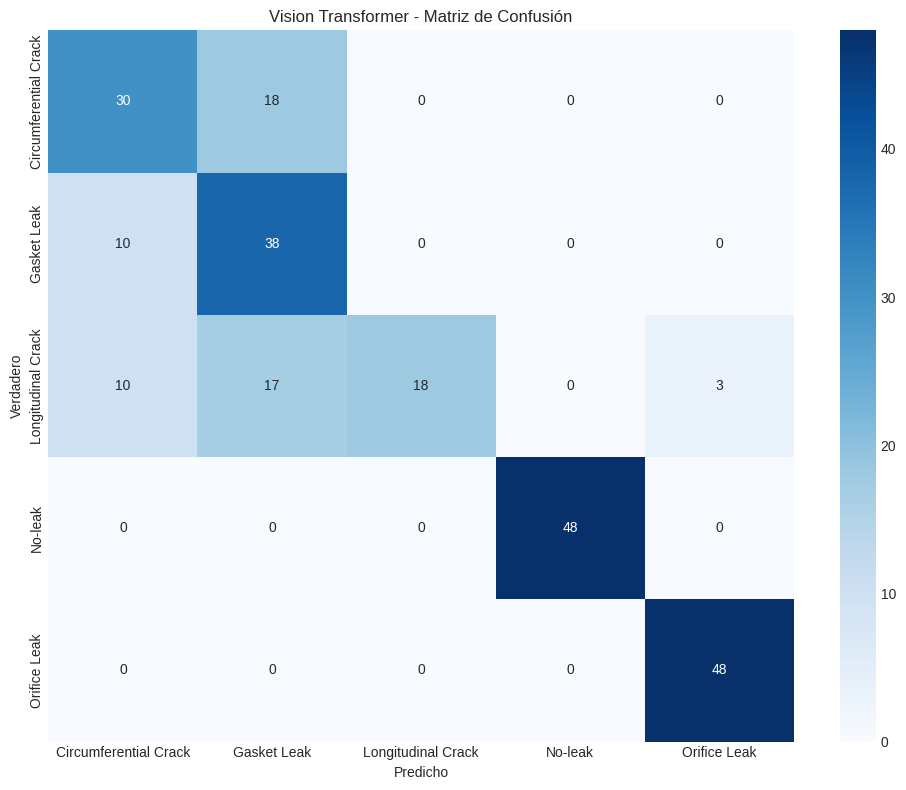

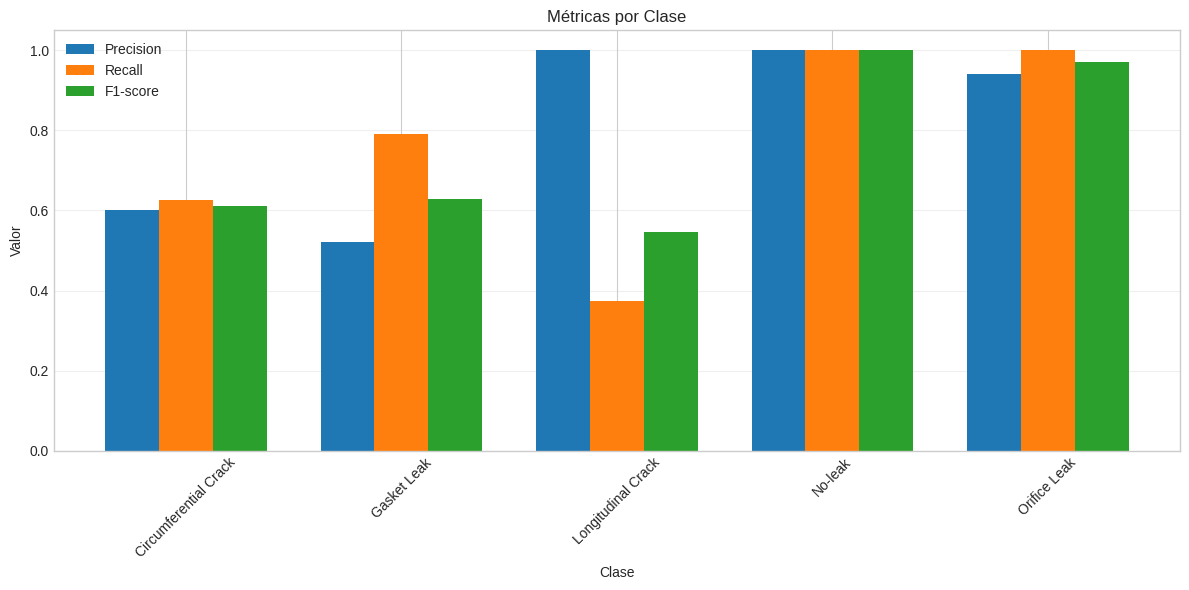

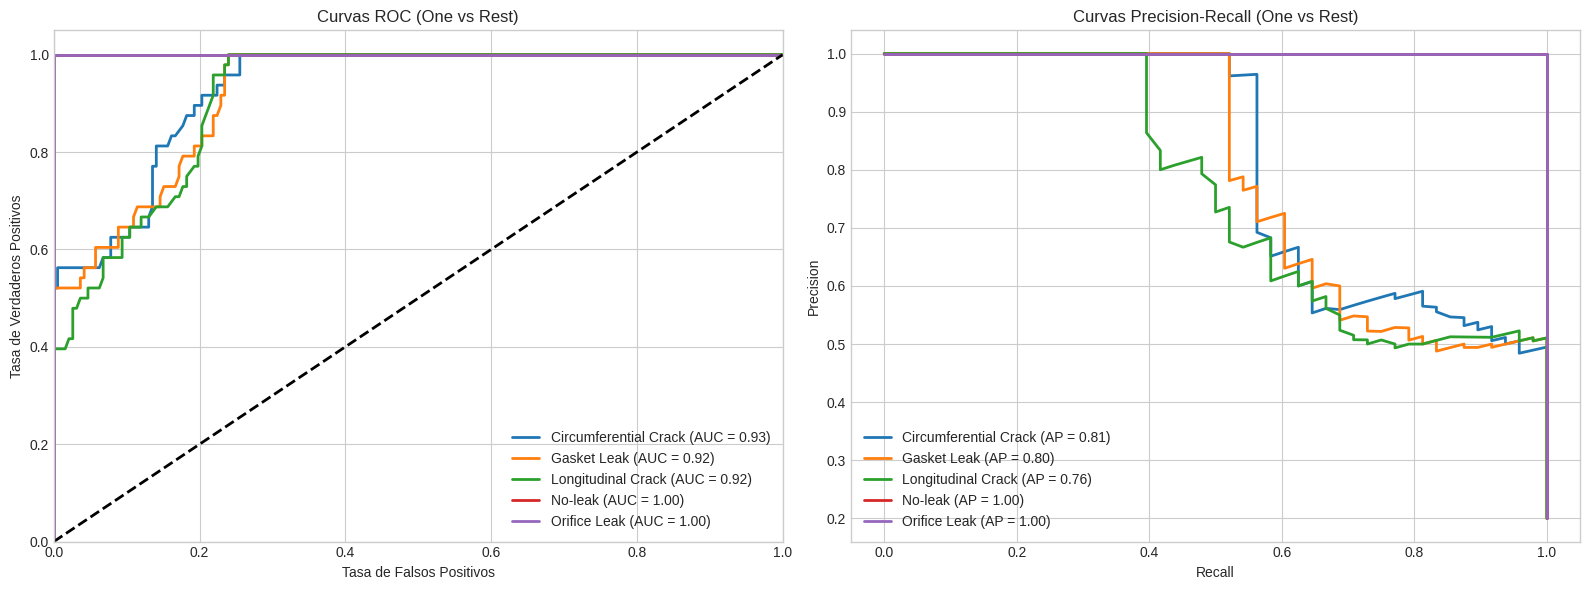


==== INFORME DETALLADO DE EVALUACIÓN ====

Modelo: Vision Transformer
- Exactitud: 0.7583
- Tiempo de inferencia total: 12.2106 segundos
- Tiempo por muestra: 50.8776 ms

Reporte de clasificación por clase:
- Circumferential Crack: Precisión=0.6000, Recall=0.6250, F1=0.6122
- Gasket Leak: Precisión=0.5205, Recall=0.7917, F1=0.6281
- Longitudinal Crack: Precisión=1.0000, Recall=0.3750, F1=0.5455
- No-leak: Precisión=1.0000, Recall=1.0000, F1=1.0000
- Orifice Leak: Precisión=0.9412, Recall=1.0000, F1=0.9697

Promedios ponderados:
- Precisión: 0.8123
- Recall: 0.7583
- F1-Score: 0.7511

Proceso de entrenamiento y evaluación del Vision Transformer completado.


In [ ]:
# ... [Clases PatchEmbedding, Attention, MLP, Block, VisionTransformer - SIN CAMBIOS en la estructura] ...

# #DEFINICION DEL VIT
from torch import nn
from torch.optim import Adam
import torch.nn.functional as F
import numpy as np
import torch # Asegúrate de tener torch importado

# --- 0. Definir el dispositivo (CPU/GPU) ---
# Asegúrate de que esta línea esté definida antes de usar 'device'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")


# --- 1. Helper Modules for Vision Transformer (sin cambios) ---
# Estas clases (PatchEmbedding, Attention, MLP, Block) no se modifican,
# pero deben estar definidas en tu entorno antes de VisionTransformer.

class PatchEmbedding(nn.Module):
    """
    Splits the image into patches and then embeds them.
    """
    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size[0] // patch_size[0]) * (img_size[1] // patch_size[1])
        self.patch_dim = in_channels * patch_size[0] * patch_size[1]

        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x shape: (batch_size, channels, H, W)
        x = self.proj(x) # (batch_size, embed_dim, H_new, W_new)
        x = x.flatten(2) # (batch_size, embed_dim, num_patches)
        x = x.transpose(1, 2) # (batch_size, num_patches, embed_dim)
        return x

class Attention(nn.Module):
    """
    Multi-Head Self-Attention (MSA) mechanism.
    """
    def __init__(self, dim, num_heads=8, qkv_bias=False, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, C = x.shape # Batch_size, Num_patches (+cls_token), Embedding_dim
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]    # B, num_heads, N, head_dim

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

class MLP(nn.Module):
    """
    Multi-Layer Perceptron (MLP) block for Transformer.
    """
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0.):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

class Block(nn.Module):
    """
    Transformer Encoder Block.
    """
    def __init__(self, dim, num_heads, mlp_ratio=4., qkv_bias=False, drop=0., attn_drop=0.,
                 act_layer=nn.GELU, norm_layer=nn.LayerNorm):
        super().__init__()
        self.norm1 = norm_layer(dim)
        self.attn = Attention(dim, num_heads=num_heads, qkv_bias=qkv_bias, attn_drop=attn_drop, proj_drop=drop)
        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = MLP(in_features=dim, hidden_features=mlp_hidden_dim, act_layer=act_layer, drop=drop)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

# --- 2. Vision Transformer Model ---

class VisionTransformer(nn.Module):
    def __init__(self, img_size=(50, 25600), patch_size=(10, 256), in_channels=1, num_classes=5,
                 embed_dim=768, depth=12, num_heads=12, mlp_ratio=4., qkv_bias=True, drop_rate=0.,
                 attn_drop_rate=0., norm_layer=nn.LayerNorm, is_binary=False):
        super().__init__()
        self.num_classes = num_classes
        self.is_binary = is_binary

        # Ensure image and patch sizes are tuples
        if isinstance(img_size, int):
            img_size = (img_size, img_size)
        if isinstance(patch_size, int):
            patch_size = (patch_size, patch_size)

        self.patch_embed = PatchEmbedding(
            img_size=img_size, patch_size=patch_size, in_channels=in_channels, embed_dim=embed_dim)
        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(p=drop_rate)

        self.blocks = nn.ModuleList([
            Block(
                dim=embed_dim, num_heads=num_heads, mlp_ratio=mlp_ratio, qkv_bias=qkv_bias,
                drop=drop_rate, attn_drop=attn_drop_rate, norm_layer=norm_layer
            )
            for _ in range(depth)
        ])
        self.norm = norm_layer(embed_dim)

        if self.is_binary:
            self.head = nn.Linear(embed_dim, 1)
        else:
            self.head = nn.Linear(embed_dim, num_classes) if num_classes > 0 else nn.Identity()

        # Initialize position embedding
        nn.init.trunc_normal_(self.pos_embed, std=.02)
        nn.init.trunc_normal_(self.cls_token, std=.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def forward_features(self, x):
        B = x.shape[0] # Batch size
        x = self.patch_embed(x) # (B, num_patches, embed_dim)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        x = self.pos_drop(x + self.pos_embed)

        for blk in self.blocks:
            x = blk(x)

        x = self.norm(x)
        return x[:, 0] # Output corresponding to the classification token

    def forward(self, x):
        x = self.forward_features(x)
        x = self.head(x)
        return x # Devuelve logits crudos para funciones de pérdida como BCEWithLogitsLoss o CrossEntropyLoss


# --- 3. Instanciación y Configuración del Modelo ---

# Obtener las dimensiones de entrada del escalograma del primer lote del DataLoader
# CAMBIO AQUÍ: ITERAMOS SOBRE EL DATALOADER PARA OBTENER UN BATCH
# NOTA: ASUMO QUE 'dataset' ESTÁ DEFINIDO Y ES ACCESIBLE
first_batch_features, _ = next(iter(dataset['train_loader']))

# first_batch_features tiene la forma (Batch_size, Channels, Height, Width)
input_c = first_batch_features.shape[1]
input_h = first_batch_features.shape[2]
input_w = first_batch_features.shape[3]
input_shape_vit = (input_h, input_w) # ViT espera (H, W) para image_size

num_classes = dataset['num_classes'] # Obtener num_classes del diccionario dataset
# Ajusta 'classification_mode' según si es 'binary' o 'multiclass'
# Asumo que 'classification_mode' está definida en tu notebook.
# Si no, defínela (ej. classification_mode = 'multiclass')
is_binary = (num_classes == 2) # Una forma común de inferir si es binario

# Define ViT parameters
# === PARÁMETROS RECOMENDADOS PARA SUPERAR 95.42% ===
vit_patch_size_h = 25
vit_patch_size_w = 256 # Reducido a 256 para mayor granularidad (Más tokens)
vit_embed_dim = 256    # Aumentado de 128 a 256 (Más capacidad de representación)
vit_depth = 6          # Aumentado de 4 a 6 (Más capas de procesamiento)
vit_num_heads = 4      # Aumentado de 2 a 4 (Más diversidad de atención)
vit_mlp_ratio = 4
vit_drop_rate = 0.05   # Dropout leve para regularizar el modelo más grande
vit_attn_drop_rate = 0.0

print(f"Dimensiones de entrada del Escalograma (CxHxW): {input_c}x{input_h}x{input_w}")
print(f"Tamaño de Parche para ViT: {vit_patch_size_h}x{vit_patch_size_w}")
print(f"Profundidad (Depth) ViT: {vit_depth}")
print(f"Dimensión de Embedding (Dim) ViT: {vit_embed_dim}")
print(f"Número de Cabezas de Atención (Heads) ViT: {vit_num_heads}")
#print(f"Tasa de Dropout: {vit_drop_rate}")


# Instanciar el modelo Vision Transformer
print("Creando modelo Vision Transformer...")
vit_model = VisionTransformer(
    img_size=input_shape_vit,
    patch_size=(vit_patch_size_h, vit_patch_size_w),
    in_channels=input_c,
    num_classes=num_classes,
    embed_dim=vit_embed_dim,
    depth=vit_depth,
    num_heads=vit_num_heads,
    mlp_ratio=vit_mlp_ratio,
    drop_rate=vit_drop_rate,
    attn_drop_rate=vit_attn_drop_rate,
    is_binary=is_binary
)

# Mover el modelo al dispositivo (GPU si está disponible, sino CPU)
vit_model.to(device)

# Imprimir resumen del modelo
print("\n--- Resumen del Modelo Vision Transformer ---")
print(vit_model)
print(f"\nNúmero de parámetros entrenables: {sum(p.numel() for p in vit_model.parameters() if p.requires_grad)}")
print("------------------------------------------")

# --- 4. Definición de la Función de Pérdida y el Optimizador ---
if is_binary:
    criterion = nn.BCEWithLogitsLoss() # Para clasificación binaria, BCEWithLogitsLoss espera logits
else:
    # Para clasificación multiclase, CrossEntropyLoss espera logits crudos y etiquetas enteras
    criterion = nn.CrossEntropyLoss()

# Tasa de aprendizaje ajustada a 5e-5
optimizer = Adam(vit_model.parameters(), lr=5e-5)

print("\nModelo Vision Transformer y componentes de entrenamiento configurados con éxito.")





#ENTRENAMIENTO ANTES DEL OVERFITTING
# Importaciones necesarias (asegúrate de que estén al inicio de tu notebook)
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
import gc
import time
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tqdm # tqdm es una buena práctica para ver el progreso

# --- Asegúrate de que 'device', 'vit_model', 'criterion', 'optimizer',
# --- 'num_classes', y 'dataset' estén definidos previamente.

# --- 0. Limpieza adicional de memoria (para las señales originales) ---
# Es CRÍTICO que esta limpieza se haga *después* de que 'fcwt_scalograms' se haya llenado con las rutas de los archivos
# y *antes* de que comience el entrenamiento.
# Asegúrate de que 'wavelet_denoised_signals_dict' haya sido utilizado y ya no sea necesario.
print("Realizando limpieza adicional de 'wavelet_denoised_signals_dict' si existe...")
if 'wavelet_denoised_signals_dict' in globals():
    del wavelet_denoised_signals_dict
    gc.collect()
    print("'wavelet_denoised_signals_dict' eliminado de la memoria.")
else:
    print("'wavelet_denoised_signals_dict' no encontrado o ya eliminado.")


# --- 1. Los PyTorch DataLoaders YA ESTÁN PREPARADOS ---
# Accedemos directamente a los DataLoaders del diccionario 'dataset'
train_loader = dataset['train_loader']
val_loader = dataset['val_loader']
test_loader = dataset['test_loader']
num_classes = dataset['num_classes']
is_binary = (num_classes == 2) # Definir is_binary aquí, si no lo hiciste antes

# --- Ajustar num_workers a 0 para reducir el consumo de RAM ---
# Este es el cambio clave para los problemas de RAM con DataLoader workers
# Si esto funciona, puedes probar a aumentarlo a 1 o 2 más tarde si la carga es muy lenta.
# Pero 0 es el punto de partida para depurar problemas de RAM.
train_loader.num_workers = 0
val_loader.num_workers = 0
test_loader.num_workers = 0

print(f"Número de batches de entrenamiento: {len(train_loader)}")
print(f"Número de batches de validación: {len(val_loader)}") # CORRECCIÓN: Debería ser val_loader
print(f"Número de batches de prueba: {len(test_loader)}")


# --- 2. Configurar callbacks (implementados en el bucle de entrenamiento) ---
epochs = 100
patience = 20 # EarlyStopping patience
best_val_loss = float('inf')
epochs_no_improve = 0
min_lr = 1e-7 # ReduceLROnPlateau min_lr

# Learning Rate Scheduler (ReduceLROnPlateau)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=7, min_lr=min_lr)

# Model Checkpoint path
model_save_path = "/content/drive/MyDrive/CWT/Looped/vit_scalograms_best_model.pth" # PyTorch models typically .pth or .pt


# --- 3. Bucle de Entrenamiento ---
print("\nEntrenando modelo Vision Transformer...")

# Store history for plotting later
history = {
    'train_loss': [],
    'train_accuracy': [],
    'val_loss': [],
    'val_accuracy': [],
    'lr': []
}

# Habilitar Mixed Precision Training si tu GPU lo soporta (muy recomendado para ahorrar RAM en GPU)
# Si no tienes GPU o tienes una GPU antigua, deja estas líneas comentadas.
from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler()


for epoch in range(epochs):
    vit_model.train() # Set model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # Training loop
    for inputs, labels in tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1} (Train)"):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Zero the gradients

        with autocast(): # Descomenta para usar Mixed Precision
            outputs = vit_model(inputs)

            if is_binary:
                labels_for_loss = labels.float().unsqueeze(1) # Necesario para BCEWithLogitsLoss
            else:
                labels_for_loss = labels # LONG para CrossEntropyLoss

            loss = criterion(outputs, labels_for_loss)

        scaler.scale(loss).backward() # Descomenta para usar Mixed Precision
        scaler.step(optimizer)        # Descomenta para usar Mixed Precision
        scaler.update()               # Descomenta para usar Mixed Precision

        running_loss += loss.item() * inputs.size(0)

        if is_binary:
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            correct_predictions += (predicted.squeeze(1) == labels).sum().item()
        else:
            _, predicted = torch.max(outputs.data, 1)
            correct_predictions += (predicted == labels).sum().item()
        total_samples += labels.size(0)


    epoch_train_loss = running_loss / total_samples
    epoch_train_accuracy = correct_predictions / total_samples
    history['train_loss'].append(epoch_train_loss)
    history['train_accuracy'].append(epoch_train_accuracy)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    # Validation loop
    vit_model.eval() # Set model to evaluation mode
    val_running_loss = 0.0
    val_correct_predictions = 0
    val_total_samples = 0

    with torch.no_grad(): # Disable gradient calculations during validation
        for inputs, labels in tqdm.tqdm(val_loader, desc=f"Epoch {epoch+1} (Val)"):
            inputs, labels = inputs.to(device), labels.to(device)

            with autocast(): # Descomenta para usar Mixed Precision
                outputs = vit_model(inputs)

                if is_binary:
                    labels_for_loss = labels.float().unsqueeze(1)
                else:
                    labels_for_loss = labels

                loss = criterion(outputs, labels_for_loss)

            val_running_loss += loss.item() * inputs.size(0)

            if is_binary:
                predicted = (torch.sigmoid(outputs) > 0.5).float()
                val_correct_predictions += (predicted.squeeze(1) == labels).sum().item()
            else:
                _, predicted = torch.max(outputs.data, 1)
                val_correct_predictions += (predicted == labels).sum().item()
            val_total_samples += labels.size(0)

    epoch_val_loss = val_running_loss / val_total_samples
    epoch_val_accuracy = val_correct_predictions / val_total_samples
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_accuracy)

    print(f"Epoch {epoch+1}/{epochs}: "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.7f}")

    # Learning Rate Scheduler step
    scheduler.step(epoch_val_loss)

    # Early Stopping
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        torch.save(vit_model.state_dict(), model_save_path) # Save best model
        print(f"Mejor modelo guardado en {model_save_path} (Val Loss: {best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print(f"Early stopping activado después de {patience} épocas sin mejora.")
            break

    gc.collect() # Clean memory at end of epoch


# --- 4. Evaluación del modelo en el conjunto de prueba ---
print("\nEvaluando el modelo Vision Transformer en el conjunto de prueba...")

# Load the best model weights before evaluation
vit_model.load_state_dict(torch.load(model_save_path))
vit_model.eval() # Set model to evaluation mode

test_running_loss = 0.0
test_correct_predictions = 0
test_total_samples = 0
all_y_true = []
all_y_pred_probs = []
all_y_pred = []

start_time = time.time()
with torch.no_grad():
    for inputs, labels in tqdm.tqdm(test_loader, desc="Evaluando en test"):
        inputs, labels = inputs.to(device), labels.to(device)

        with autocast(): # Descomenta para usar Mixed Precision
            outputs = vit_model(inputs)

            if is_binary:
                labels_for_loss = labels.float().unsqueeze(1)
            else:
                labels_for_loss = labels

            loss = criterion(outputs, labels_for_loss)

        test_running_loss += loss.item() * inputs.size(0)

        # Store predictions and true labels
        if is_binary:
            y_prob_batch = torch.sigmoid(outputs)
            y_pred_batch = (y_prob_batch > 0.5).float()

            all_y_true.extend(labels.cpu().numpy().flatten())
            all_y_pred.extend(y_pred_batch.cpu().numpy().flatten())
            all_y_pred_probs.extend(y_prob_batch.cpu().numpy().flatten())

            test_correct_predictions += (y_pred_batch.squeeze(1) == labels).sum().item()
        else:
            _, predicted_class = torch.max(outputs.data, 1)
            probs_batch = F.softmax(outputs, dim=1)

            all_y_true.extend(labels.cpu().numpy())
            all_y_pred.extend(predicted_class.cpu().numpy())
            all_y_pred_probs.extend(probs_batch.cpu().numpy())

            test_correct_predictions += (predicted_class == labels).sum().item()
        test_total_samples += labels.size(0)

inference_time = time.time() - start_time

vit_test_loss = test_running_loss / test_total_samples
vit_test_acc = test_correct_predictions / test_total_samples

print(f"\nRendimiento del modelo Vision Transformer en conjunto de prueba:")
print(f"- Pérdida: {vit_test_loss:.4f}")
print(f"- Exactitud: {vit_test_acc:.4f}")

# Convert lists to numpy arrays for sklearn metrics
y_true_np = np.array(all_y_true)
y_pred_np = np.array(all_y_pred)

if is_binary:
    y_pred_probs_np = np.array(all_y_pred_probs)
else:
    y_pred_probs_np = np.array(all_y_pred_probs).reshape(-1, num_classes)


# --- 5. Análisis detallado y Visualización ---
print("\nRealizando evaluación detallada del modelo Vision Transformer...")

conf_matrix = confusion_matrix(y_true_np, y_pred_np)

# Get class names
class_names = list(dataset['label_codes_dict'].keys())

# Generate classification report
report = classification_report(y_true_np, y_pred_np, target_names=class_names, output_dict=True)

# Create results dictionary for visualization
resultados_vit = {
    'model_name': "Vision Transformer",
    'accuracy': vit_test_acc,
    'confusion_matrix': conf_matrix,
    'classification_report': report,
    'inference_time': inference_time,
    'inference_time_per_sample': inference_time / len(y_true_np),
    'y_pred': y_pred_np,
    'y_true': y_true_np,
    'y_pred_probs': y_pred_probs_np
}

# 1. Matriz de confusión
plt.figure(figsize=(10, 8))
sns.heatmap(resultados_vit['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f"{resultados_vit['model_name']} - Matriz de Confusión")
plt.ylabel("Verdadero")
plt.xlabel("Predicho")
plt.tight_layout()
plt.show()

# 2. Métricas por clase
plt.figure(figsize=(12, 6))
metrics = ['precision', 'recall', 'f1-score']
x = np.arange(len(class_names))
width = 0.25

for i, metric in enumerate(metrics):
    values = [resultados_vit['classification_report'][cls][metric] for cls in class_names if cls in resultados_vit['classification_report']]
    plt.bar(x + i*width - width, values, width, label=metric.capitalize())

plt.xlabel('Clase')
plt.ylabel('Valor')
plt.title('Métricas por Clase')
plt.xticks(x, class_names, rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. ROC y Precision-Recall para clasificación multiclase/binaria
if len(class_names) > 2: # Multiclase
    plt.figure(figsize=(16, 6))

    # ROC multiclase (one vs rest)
    plt.subplot(1, 2, 1)
    for i, cls_name in enumerate(class_names):
        y_true_binary = (resultados_vit['y_true'] == i).astype(int)
        y_score = resultados_vit['y_pred_probs'][:, i]

        fpr, tpr, _ = roc_curve(y_true_binary, y_score)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, lw=2, label=f'{cls_name} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curvas ROC (One vs Rest)')
    plt.legend(loc="lower right")

    # Precision-Recall multiclase
    plt.subplot(1, 2, 2)
    for i, cls_name in enumerate(class_names):
        y_true_binary = (resultados_vit['y_true'] == i).astype(int)
        y_score = resultados_vit['y_pred_probs'][:, i]

        precision, recall, _ = precision_recall_curve(y_true_binary, y_score)
        ap = average_precision_score(y_true_binary, y_score)

        plt.plot(recall, precision, lw=2, label=f'{cls_name} (AP = {ap:.2f})')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Curvas Precision-Recall (One vs Rest)')
    plt.legend(loc="best")

    plt.tight_layout()
    plt.show()

else: # Binaria
    y_score = resultados_vit['y_pred_probs'].flatten()

    plt.figure(figsize=(16, 6))

    # ROC binaria
    plt.subplot(1, 2, 1)
    fpr, tpr, _ = roc_curve(resultados_vit['y_true'], y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curva ROC')
    plt.legend(loc="lower right")

    # Precision-Recall binaria
    plt.subplot(1, 2, 2)
    precision, recall, _ = precision_recall_curve(resultados_vit['y_true'], y_score)
    ap = average_precision_score(resultados_vit['y_true'], y_score)

    plt.plot(recall, precision, lw=2, label=f'PR (AP = {ap:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Curva Precision-Recall')
    plt.legend(loc="best")

    plt.tight_layout()
    plt.show()

# 6. Imprimir métricas detalladas
print("\n==== INFORME DETALLADO DE EVALUACIÓN ====\n")
print(f"Modelo: {resultados_vit['model_name']}")
print(f"- Exactitud: {resultados_vit['accuracy']:.4f}")
print(f"- Tiempo de inferencia total: {resultados_vit['inference_time']:.4f} segundos")
print(f"- Tiempo por muestra: {resultados_vit['inference_time_per_sample']*1000:.4f} ms")

print("\nReporte de clasificación por clase:")
for cls in class_names:
    if cls in resultados_vit['classification_report']:
        cls_metrics = resultados_vit['classification_report'][cls]
        print(f"- {cls}: Precisión={cls_metrics['precision']:.4f}, "
              f"Recall={cls_metrics['recall']:.4f}, F1={cls_metrics['f1-score']:.4f}")

if 'weighted avg' in resultados_vit['classification_report']:
    weighted_avg = resultados_vit['classification_report']['weighted avg']
    print(f"\nPromedios ponderados:")
    print(f"- Precisión: {weighted_avg['precision']:.4f}")
    print(f"- Recall: {weighted_avg['recall']:.4f}")
    print(f"- F1-Score: {weighted_avg['f1-score']:.4f}")

# Save the model if it has good performance (uncomment and adjust threshold if needed)
# if vit_test_acc > 0.85:
#    print(f"\nModelo con buen rendimiento detectado. Guardando en {model_save_path}...")
#    torch.save(vit_model.state_dict(), model_save_path)

# Cleanup
del train_loader, val_loader, test_loader
gc.collect()

print("\nProceso de entrenamiento y evaluación del Vision Transformer completado.")

In [ ]:
# ====================================================================
#                          SETUP INICIAL
# ====================================================================

# Importaciones necesarias (asegúrate de que estén al inicio de tu notebook)
from torch import nn
from torch.optim import AdamW # ¡CAMBIO: Se usa AdamW!
import torch.nn.functional as F
import numpy as np
import torch
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
import gc
import time
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm
from torch.cuda.amp import autocast, GradScaler
import os # Importación añadida, aunque probablemente ya estaba

# --- 0. Definir el dispositivo (CPU/GPU) ---
# Asegúrate de que esta línea esté definida antes de usar 'device'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")


# --- 1. Helper Modules for Vision Transformer (sin cambios) ---

class PatchEmbedding(nn.Module):
    """
    Splits the image into patches and then embeds them.
    """
    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size[0] // patch_size[0]) * (img_size[1] // patch_size[1])
        self.patch_dim = in_channels * patch_size[0] * patch_size[1]

        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x shape: (batch_size, channels, H, W)
        x = self.proj(x) # (batch_size, embed_dim, H_new, W_new)
        x = x.flatten(2) # (batch_size, embed_dim, num_patches)
        x = x.transpose(1, 2) # (batch_size, num_patches, embed_dim)
        return x

class Attention(nn.Module):
    """
    Multi-Head Self-Attention (MSA) mechanism.
    """
    def __init__(self, dim, num_heads=8, qkv_bias=False, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, C = x.shape # Batch_size, Num_patches (+cls_token), Embedding_dim
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]    # B, num_heads, N, head_dim

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

class MLP(nn.Module):
    """
    Multi-Layer Perceptron (MLP) block for Transformer.
    """
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0.):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

class Block(nn.Module):
    """
    Transformer Encoder Block.
    """
    def __init__(self, dim, num_heads, mlp_ratio=4., qkv_bias=False, drop=0., attn_drop=0.,
                 act_layer=nn.GELU, norm_layer=nn.LayerNorm):
        super().__init__()
        self.norm1 = norm_layer(dim)
        self.attn = Attention(dim, num_heads=num_heads, qkv_bias=qkv_bias, attn_drop=attn_drop, proj_drop=drop)
        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = MLP(in_features=dim, hidden_features=mlp_hidden_dim, act_layer=act_layer, drop=drop)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

# --- 2. Vision Transformer Model ---

class VisionTransformer(nn.Module):
    def __init__(self, img_size=(50, 25600), patch_size=(10, 256), in_channels=1, num_classes=5,
                 embed_dim=768, depth=12, num_heads=12, mlp_ratio=4., qkv_bias=True, drop_rate=0.,
                 attn_drop_rate=0., norm_layer=nn.LayerNorm, is_binary=False):
        super().__init__()
        self.num_classes = num_classes
        self.is_binary = is_binary

        # Ensure image and patch sizes are tuples
        if isinstance(img_size, int):
            img_size = (img_size, img_size)
        if isinstance(patch_size, int):
            patch_size = (patch_size, patch_size)

        self.patch_embed = PatchEmbedding(
            img_size=img_size, patch_size=patch_size, in_channels=in_channels, embed_dim=embed_dim)
        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(p=drop_rate)

        self.blocks = nn.ModuleList([
            Block(
                dim=embed_dim, num_heads=num_heads, mlp_ratio=mlp_ratio, qkv_bias=qkv_bias,
                drop=drop_rate, attn_drop=attn_drop_rate, norm_layer=norm_layer
            )
            for _ in range(depth)
        ])
        self.norm = norm_layer(embed_dim)

        if self.is_binary:
            self.head = nn.Linear(embed_dim, 1)
        else:
            self.head = nn.Linear(embed_dim, num_classes) if num_classes > 0 else nn.Identity()

        # Initialize position embedding
        nn.init.trunc_normal_(self.pos_embed, std=.02)
        nn.init.trunc_normal_(self.cls_token, std=.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def forward_features(self, x):
        B = x.shape[0] # Batch size
        x = self.patch_embed(x) # (B, num_patches, embed_dim)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        x = self.pos_drop(x + self.pos_embed)

        for blk in self.blocks:
            x = blk(x)

        x = self.norm(x)
        return x[:, 0] # Output corresponding to the classification token

    def forward(self, x):
        x = self.forward_features(x)
        x = self.head(x)
        return x


# --- 3. Instanciación y Configuración del Modelo (¡CAMBIOS APLICADOS!) ---

# Obtener las dimensiones de entrada del escalograma del primer lote del DataLoader
# NOTA: ASUMO QUE 'dataset' ESTÁ DEFINIDO Y ES ACCESIBLE
first_batch_features, _ = next(iter(dataset['train_loader']))

# first_batch_features tiene la forma (Batch_size, Channels, Height, Width)
input_c = first_batch_features.shape[1]
input_h = first_batch_features.shape[2]
input_w = first_batch_features.shape[3]
input_shape_vit = (input_h, input_w) # ViT espera (H, W) para image_size

num_classes = dataset['num_classes'] # Obtener num_classes del diccionario dataset
is_binary = (num_classes == 2) # Una forma común de inferir si es binario

# Define ViT parameters
# === PARÁMETROS AJUSTADOS PARA MEJOR GENERALIZACIÓN (ViT-Small/Base) ===
vit_patch_size_h = 25
vit_patch_size_w = 128   # Más tokens
vit_embed_dim = 512      # Mayor capacidad
vit_depth = 8            # Más capas
vit_num_heads = 8        # Más cabezas
vit_mlp_ratio = 4
vit_drop_rate = 0.15     # ¡Aumentado de 0.10 a 0.15 para más regularización!
vit_attn_drop_rate = 0.05 # ¡Añadido dropout en atención!

print(f"Dimensiones de entrada del Escalograma (CxHxW): {input_c}x{input_h}x{input_w}")
print(f"Tamaño de Parche para ViT: {vit_patch_size_h}x{vit_patch_size_w}")
print(f"Profundidad (Depth) ViT: {vit_depth}")
print(f"Dimensión de Embedding (Dim) ViT: {vit_embed_dim}")
print(f"Número de Cabezas de Atención (Heads) ViT: {vit_num_heads}")
print(f"Tasa de Dropout: {vit_drop_rate} (Norm), {vit_attn_drop_rate} (Attn)")


# Instanciar el modelo Vision Transformer
print("Creando modelo Vision Transformer con ajuste fino de hiperparámetros...")
vit_model = VisionTransformer(
    img_size=input_shape_vit,
    patch_size=(vit_patch_size_h, vit_patch_size_w),
    in_channels=input_c,
    num_classes=num_classes,
    embed_dim=vit_embed_dim,
    depth=vit_depth,
    num_heads=vit_num_heads,
    mlp_ratio=vit_mlp_ratio,
    drop_rate=vit_drop_rate,
    attn_drop_rate=vit_attn_drop_rate,
    is_binary=is_binary
)

# Mover el modelo al dispositivo (GPU si está disponible, sino CPU)
vit_model.to(device)

# Imprimir resumen del modelo
print("\n--- Resumen del Modelo Vision Transformer ---")
print(f"\nNúmero de parámetros entrenables: {sum(p.numel() for p in vit_model.parameters() if p.requires_grad)}")
print("------------------------------------------")

# --- 4. Definición de la Función de Pérdida y el Optimizador ---
if is_binary:
    criterion = nn.BCEWithLogitsLoss() # Para clasificación binaria, BCEWithLogitsLoss espera logits
else:
    # Para clasificación multiclase, CrossEntropyLoss espera logits crudos y etiquetas enteras
    criterion = nn.CrossEntropyLoss()

# ¡AJUSTE FINO! Usar AdamW con LR más bajo y Weight Decay más alto
optimizer = AdamW(vit_model.parameters(), lr=5e-5, weight_decay=1e-4) # LR de 1e-4 a 5e-5; WD de 1e-5 a 1e-4

print("\nModelo Vision Transformer y componentes de entrenamiento configurados con éxito.")


# ====================================================================
#                      ENTRENAMIENTO Y EVALUACIÓN
# ====================================================================

# --- 0. Limpieza adicional de memoria (para las señales originales) ---
print("Realizando limpieza adicional de 'wavelet_denoised_signals_dict' si existe...")
if 'wavelet_denoised_signals_dict' in globals():
    del wavelet_denoised_signals_dict
    gc.collect()
    print("'wavelet_denoised_signals_dict' eliminado de la memoria.")
else:
    print("'wavelet_denoised_signals_dict' no encontrado o ya eliminado.")


# --- 1. Los PyTorch DataLoaders YA ESTÁN PREPARADOS ---
# Accedemos directamente a los DataLoaders del diccionario 'dataset'
train_loader = dataset['train_loader']
val_loader = dataset['val_loader']
test_loader = dataset['test_loader']
num_classes = dataset['num_classes']
is_binary = (num_classes == 2)

# Ajustar num_workers a 0 para reducir el consumo de RAM
train_loader.num_workers = 0
val_loader.num_workers = 0
test_loader.num_workers = 0

print(f"Número de batches de entrenamiento: {len(train_loader)}")
print(f"Número de batches de validación: {len(val_loader)}")
print(f"Número de batches de prueba: {len(test_loader)}")


# --- 2. Configurar callbacks (¡AJUSTE DE PACIENCIA!) ---
epochs = 100
patience = 40 # EarlyStopping patience: Aumentado de 30 a 40
best_val_loss = float('inf')
epochs_no_improve = 0
min_lr = 1e-7 # ReduceLROnPlateau min_lr

# Learning Rate Scheduler (ReduceLROnPlateau con más paciencia)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15, min_lr=min_lr) # Aumentado patience a 15

# Model Checkpoint path (MANTENER TU RUTA)
model_save_path = "/content/drive/MyDrive/CWT/Looped/vit_scalograms_best_model.pth"


# --- 3. Bucle de Entrenamiento ---
print("\nEntrenando modelo Vision Transformer...")

# Store history for plotting later
history = {
    'train_loss': [],
    'train_accuracy': [],
    'val_loss': [],
    'val_accuracy': [],
    'lr': []
}

# Habilitar Mixed Precision Training si tu GPU lo soporta
scaler = GradScaler()


for epoch in range(epochs):
    vit_model.train() # Set model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # Training loop
    for inputs, labels in tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1} (Train)"):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Zero the gradients

        with autocast(): # Usando Mixed Precision
            outputs = vit_model(inputs)

            if is_binary:
                labels_for_loss = labels.float().unsqueeze(1) # Necesario para BCEWithLogitsLoss
            else:
                labels_for_loss = labels # LONG para CrossEntropyLoss

            loss = criterion(outputs, labels_for_loss)

        scaler.scale(loss).backward() # Usando Mixed Precision
        scaler.step(optimizer)        # Usando Mixed Precision
        scaler.update()               # Usando Mixed Precision

        running_loss += loss.item() * inputs.size(0)

        if is_binary:
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            correct_predictions += (predicted.squeeze(1) == labels).sum().item()
        else:
            _, predicted = torch.max(outputs.data, 1)
            correct_predictions += (predicted == labels).sum().item()
        total_samples += labels.size(0)


    epoch_train_loss = running_loss / total_samples
    epoch_train_accuracy = correct_predictions / total_samples
    history['train_loss'].append(epoch_train_loss)
    history['train_accuracy'].append(epoch_train_accuracy)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    # Validation loop
    vit_model.eval() # Set model to evaluation mode
    val_running_loss = 0.0
    val_correct_predictions = 0
    val_total_samples = 0

    with torch.no_grad(): # Disable gradient calculations during validation
        for inputs, labels in tqdm.tqdm(val_loader, desc=f"Epoch {epoch+1} (Val)"):
            inputs, labels = inputs.to(device), labels.to(device)

            with autocast(): # Usando Mixed Precision
                outputs = vit_model(inputs)

                if is_binary:
                    labels_for_loss = labels.float().unsqueeze(1)
                else:
                    labels_for_loss = labels

                loss = criterion(outputs, labels_for_loss)

            val_running_loss += loss.item() * inputs.size(0)

            if is_binary:
                predicted = (torch.sigmoid(outputs) > 0.5).float()
                val_correct_predictions += (predicted.squeeze(1) == labels).sum().item()
            else:
                _, predicted = torch.max(outputs.data, 1)
                val_correct_predictions += (predicted == labels).sum().item()
            val_total_samples += labels.size(0)

    epoch_val_loss = val_running_loss / val_total_samples
    epoch_val_accuracy = val_correct_predictions / val_total_samples
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_accuracy)

    print(f"Epoch {epoch+1}/{epochs}: "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.7f}")

    # Learning Rate Scheduler step
    scheduler.step(epoch_val_loss)

    # Early Stopping
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        torch.save(vit_model.state_dict(), model_save_path) # Save best model
        print(f"Mejor modelo guardado en {model_save_path} (Val Loss: {best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience: # Usando la nueva paciencia (40)
            print(f"Early stopping activado después de {patience} épocas sin mejora.")
            break

    gc.collect() # Clean memory at end of epoch


# --- 4. Evaluación del modelo en el conjunto de prueba ---
print("\nEvaluando el modelo Vision Transformer en el conjunto de prueba...")

# Load the best model weights before evaluation
vit_model.load_state_dict(torch.load(model_save_path))
vit_model.eval() # Set model to evaluation mode

test_running_loss = 0.0
test_correct_predictions = 0
test_total_samples = 0
all_y_true = []
all_y_pred_probs = []
all_y_pred = []

start_time = time.time()
with torch.no_grad():
    for inputs, labels in tqdm.tqdm(test_loader, desc="Evaluando en test"):
        inputs, labels = inputs.to(device), labels.to(device)

        with autocast(): # Usando Mixed Precision
            outputs = vit_model(inputs)

            if is_binary:
                labels_for_loss = labels.float().unsqueeze(1)
            else:
                labels_for_loss = labels

            loss = criterion(outputs, labels_for_loss)

        test_running_loss += loss.item() * inputs.size(0)

        # Store predictions and true labels
        if is_binary:
            y_prob_batch = torch.sigmoid(outputs)
            y_pred_batch = (y_prob_batch > 0.5).float()

            all_y_true.extend(labels.cpu().numpy().flatten())
            all_y_pred.extend(y_pred_batch.cpu().numpy().flatten())
            all_y_pred_probs.extend(y_prob_batch.cpu().numpy().flatten())

            test_correct_predictions += (y_pred_batch.squeeze(1) == labels).sum().item()
        else:
            _, predicted_class = torch.max(outputs.data, 1)
            probs_batch = F.softmax(outputs, dim=1)

            all_y_true.extend(labels.cpu().numpy())
            all_y_pred.extend(predicted_class.cpu().numpy())
            all_y_pred_probs.extend(probs_batch.cpu().numpy())

            test_correct_predictions += (predicted_class == labels).sum().item()
        test_total_samples += labels.size(0)

inference_time = time.time() - start_time

vit_test_loss = test_running_loss / test_total_samples
vit_test_acc = test_correct_predictions / test_total_samples

print(f"\nRendimiento del modelo Vision Transformer en conjunto de prueba:")
print(f"- Pérdida: {vit_test_loss:.4f}")
print(f"- Exactitud: {vit_test_acc:.4f}")

# Convert lists to numpy arrays for sklearn metrics
y_true_np = np.array(all_y_true)
y_pred_np = np.array(all_y_pred)

if is_binary:
    y_pred_probs_np = np.array(all_y_pred_probs)
else:
    y_pred_probs_np = np.array(all_y_pred_probs).reshape(-1, num_classes)


# --- 5. Análisis detallado y Visualización ---
print("\nRealizando evaluación detallada del modelo Vision Transformer...")

conf_matrix = confusion_matrix(y_true_np, y_pred_np)

# Get class names
class_names = list(dataset['label_codes_dict'].keys())

# Generate classification report
report = classification_report(y_true_np, y_pred_np, target_names=class_names, output_dict=True)

# Create results dictionary for visualization
resultados_vit = {
    'model_name': "Vision Transformer",
    'accuracy': vit_test_acc,
    'confusion_matrix': conf_matrix,
    'classification_report': report,
    'inference_time': inference_time,
    'inference_time_per_sample': inference_time / len(y_true_np),
    'y_pred': y_pred_np,
    'y_true': y_true_np,
    'y_pred_probs': y_pred_probs_np
}

# 1. Matriz de confusión
plt.figure(figsize=(10, 8))
sns.heatmap(resultados_vit['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f"{resultados_vit['model_name']} - Matriz de Confusión")
plt.ylabel("Verdadero")
plt.xlabel("Predicho")
plt.tight_layout()
plt.show()

# 2. Métricas por clase
plt.figure(figsize=(12, 6))
metrics = ['precision', 'recall', 'f1-score']
x = np.arange(len(class_names))
width = 0.25

for i, metric in enumerate(metrics):
    values = [resultados_vit['classification_report'][cls][metric] for cls in class_names if cls in resultados_vit['classification_report']]
    plt.bar(x + i*width - width, values, width, label=metric.capitalize())

plt.xlabel('Clase')
plt.ylabel('Valor')
plt.title('Métricas por Clase')
plt.xticks(x, class_names, rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. ROC y Precision-Recall para clasificación multiclase/binaria
if len(class_names) > 2: # Multiclase
    plt.figure(figsize=(16, 6))

    # ROC multiclase (one vs rest)
    plt.subplot(1, 2, 1)
    for i, cls_name in enumerate(class_names):
        y_true_binary = (resultados_vit['y_true'] == i).astype(int)
        y_score = resultados_vit['y_pred_probs'][:, i]

        fpr, tpr, _ = roc_curve(y_true_binary, y_score)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, lw=2, label=f'{cls_name} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curvas ROC (One vs Rest)')
    plt.legend(loc="lower right")

    # Precision-Recall multiclase
    plt.subplot(1, 2, 2)
    for i, cls_name in enumerate(class_names):
        y_true_binary = (resultados_vit['y_true'] == i).astype(int)
        y_score = resultados_vit['y_pred_probs'][:, i]

        precision, recall, _ = precision_recall_curve(y_true_binary, y_score)
        ap = average_precision_score(y_true_binary, y_score)

        plt.plot(recall, precision, lw=2, label=f'{cls_name} (AP = {ap:.2f})')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Curvas Precision-Recall (One vs Rest)')
    plt.legend(loc="best")

    plt.tight_layout()
    plt.show()

else: # Binaria
    y_score = resultados_vit['y_pred_probs'].flatten()

    plt.figure(figsize=(16, 6))

    # ROC binaria
    plt.subplot(1, 2, 1)
    fpr, tpr, _ = roc_curve(resultados_vit['y_true'], y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curva ROC')
    plt.legend(loc="lower right")

    # Precision-Recall binaria
    plt.subplot(1, 2, 2)
    precision, recall, _ = precision_recall_curve(resultados_vit['y_true'], y_score)
    ap = average_precision_score(resultados_vit['y_true'], y_score)

    plt.plot(recall, precision, lw=2, label=f'PR (AP = {ap:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Curva Precision-Recall')
    plt.legend(loc="best")

    plt.tight_layout()
    plt.show()

# 6. Imprimir métricas detalladas
print("\n==== INFORME DETALLADO DE EVALUACIÓN ====\n")
print(f"Modelo: {resultados_vit['model_name']}")
print(f"- Exactitud: {resultados_vit['accuracy']:.4f}")
print(f"- Tiempo de inferencia total: {resultados_vit['inference_time']:.4f} segundos")
print(f"- Tiempo por muestra: {resultados_vit['inference_time_per_sample']*1000:.4f} ms")

print("\nReporte de clasificación por clase:")
for cls in class_names:
    if cls in resultados_vit['classification_report']:
        cls_metrics = resultados_vit['classification_report'][cls]
        print(f"- {cls}: Precisión={cls_metrics['precision']:.4f}, "
              f"Recall={cls_metrics['recall']:.4f}, F1={cls_metrics['f1-score']:.4f}")

if 'weighted avg' in resultados_vit['classification_report']:
    weighted_avg = resultados_vit['classification_report']['weighted avg']
    print(f"\nPromedios ponderados:")
    print(f"- Precisión: {weighted_avg['precision']:.4f}")
    print(f"- Recall: {weighted_avg['recall']:.4f}")
    print(f"- F1-Score: {weighted_avg['f1-score']:.4f}")

# Cleanup
del train_loader, val_loader, test_loader
gc.collect()

print("\nProceso de entrenamiento y evaluación del Vision Transformer completado.")

Usando dispositivo: cuda
Dimensiones de entrada del Escalograma (CxHxW): 1x50x32768
Tamaño de Parche para ViT: 25x128
Profundidad (Depth) ViT: 8
Dimensión de Embedding (Dim) ViT: 768
Número de Cabezas de Atención (Heads) ViT: 12
Tasa de Dropout: 0.15 (Norm), 0.05 (Attn)
Creando modelo Vision Transformer con mayor capacidad y optimización suavizada...


/tmp/ipython-input-3953631135.py:320: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()



--- Resumen del Modelo Vision Transformer ---

Número de parámetros entrenables: 59561477
------------------------------------------

Modelo Vision Transformer y componentes de entrenamiento configurados con éxito.
Realizando limpieza adicional de 'wavelet_denoised_signals_dict' si existe...
'wavelet_denoised_signals_dict' no encontrado o ya eliminado.
Número de batches de entrenamiento: 24
Número de batches de validación: 6
Número de batches de prueba: 8

Entrenando modelo Vision Transformer...


Epoch 1 (Train):   0%|          | 0/24 [00:00<?, ?it/s]/tmp/ipython-input-3953631135.py:335: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # Usando Mixed Precision
Epoch 1 (Val):   0%|          | 0/6 [00:00<?, ?it/s]/tmp/ipython-input-3953631135.py:376: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # Usando Mixed Precision
Epoch 1 (Val): 100%|██████████| 6/6 [00:10<00:00,  1.82s/it]


Epoch 1/100: Train Loss: 2.3337, Train Acc: 0.2057 | Val Loss: 1.5721, Val Acc: 0.2865 | LR: 0.0001000
Mejor modelo guardado en /content/drive/MyDrive/CWT/Looped/vit_scalograms_best_model.pth (Val Loss: 1.5721)


...

Epoch 55 (Val): 100%|██████████| 6/6 [00:11<00:00,  1.94s/it]


Epoch 55/100: Train Loss: 0.3395, Train Acc: 0.7956 | Val Loss: 0.3824, Val Acc: 0.7917 | LR: 0.0000500


Epoch 56 (Val): 100%|██████████| 6/6 [00:11<00:00,  2.00s/it]


Epoch 56/100: Train Loss: 0.3434, Train Acc: 0.8021 | Val Loss: 0.3370, Val Acc: 0.8021 | LR: 0.0000500
Mejor modelo guardado en /content/drive/MyDrive/CWT/Looped/vit_scalograms_best_model.pth (Val Loss: 0.3370)


Epoch 57 (Train):  42%|████▏     | 10/24 [00:26<00:38,  2.74s/it]